# Objectif du notebook 

Date de création :30/03/2026

À compléter 


In [1]:
# %matplotlib notebook

import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import scipy.signal as sp 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.interpolate import interp1d
from scipy.spatial.distance import cdist
from datetime import timedelta, datetime
from scipy.stats import linregress
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

sensibility_img_folder = os.path.join(img_folder, "rtf_mfp", "sensibility")

In [3]:
sys.path.append(project_root)
from publication.publication_figure import (
    PubFigure,
    LargeFigure,
    color,
    set_subfigures_abc_labels,
)
from propa.rtf.rtf_utils import D_hermitian_angle_fast, D_euclidian


from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    # ActiveFiberscopeManager,
    # PassiveFiberscopeManager,
    BandFilter,
)

from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp import (
    RTF_MFP_Processor,
)
from misc import progression_bar

# Étape 1 : sélection d'une sous partie de la séquence

Afin de simplifier l'étude, la séquence est réduite aux émissions comprises entre l'OBS 1 et l'OBS 3 (émissions n°50 à n°170).

In [4]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

In [5]:
seq_id = 116
df_seq = df_arr.loc[df_arr["sequence_id"] == seq_id]

# Select only pulses emitted between OBS1 and OBS3
pulse_slice = (0, 10)
df_seq = df_seq.loc[df_seq["pulse_id"].between(*pulse_slice)]

root_fig = os.path.join(sensibility_img_folder, f"{seq_id}")
if not os.path.exists(root_fig):
    os.makedirs(root_fig)

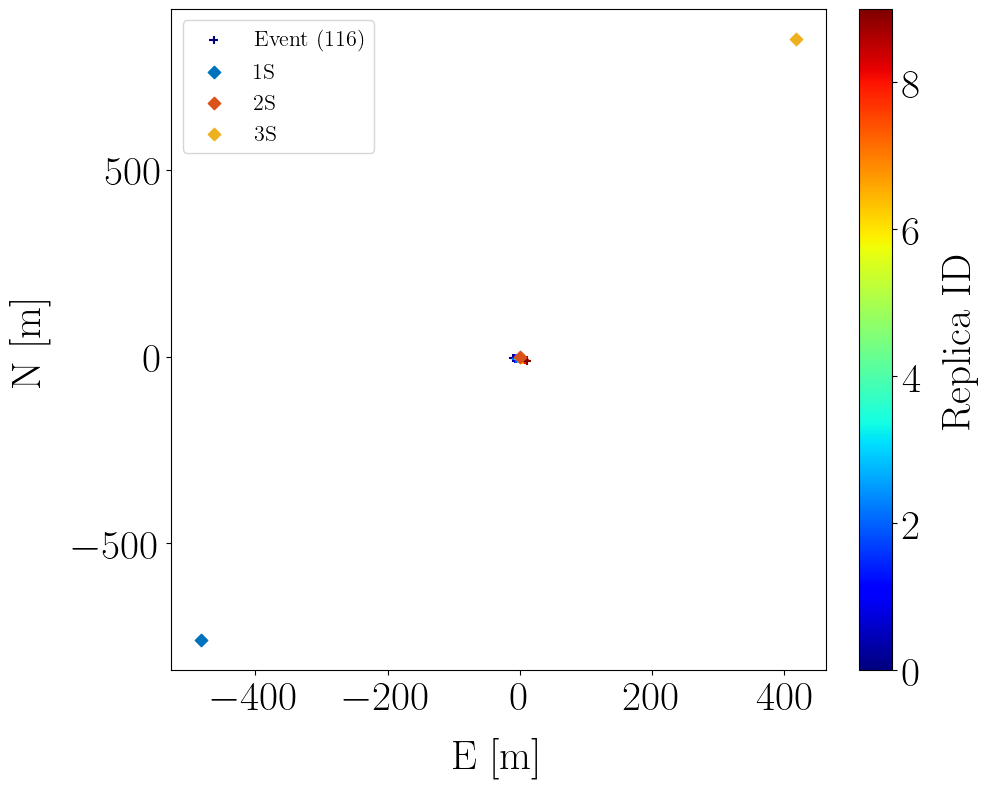

In [6]:
# Tracer des positions d'émission et des positions des OBS sur la carte

pfig = PubFigure(size=(10, 8), legend_fontsize=16)
# Plot
plt.figure()

# Série de positions successives
plt.scatter(
    df_seq["emission_interp_e_gps"],
    df_seq["emission_interp_n_gps"],
    marker="+",
    label=f"Event ({seq_id})",
    c=np.arange(df_seq["emission_interp_e_gps"].size),
    cmap="jet",
)
plt.colorbar(label="Replica ID")


keys = ["obs1", "obs2", "obs3"]
label = {
    "obs1": "1S",
    "obs2": "2S",
    "obs3": "3S",
    "t1": "1",
    "t2": "2",
    "t3": "3",
    "t4": "4",
    "t5": "5",
}
for ik, k in enumerate(keys):
    e = ds_gps.attrs[f"{k}_e_apriori"]
    n = ds_gps.attrs[f"{k}_n_apriori"]
    plt.scatter(
        e,
        n,
        marker="D",
        label=label[k],
        zorder=10,
        color=color(ik),
        s=40,
    )

plt.legend()
plt.xlabel("E [m]")
plt.ylabel("N [m]")

fpath = os.path.join(root_fig, "emission_positions.png")
plt.savefig(fpath)

In [7]:
ve = df_seq["emission_interp_ve_gps"]
vn = df_seq["emission_interp_vn_gps"]
vs = np.vstack((ve, vn))
vs_norm = np.linalg.norm(vs, axis=0)

print(f"Median source speed along traj : vs = {np.median(vs_norm):.2f} m.s-1")

Median source speed along traj : vs = 0.24 m.s-1


# Étape 2 : choix des paramètres de l'estimateur CS-EVD 

Le succès de la méthode proposée repose en grande partie sur la capacité à estimer correctement la grandeur signante d'intérêt, à savoir le vecteur de RTFs. 

Dans le cas de signaux actifs, le vecteur de RTFs peut également être estimé par déconvolution du signal reçu. Pour chaque émission considérée, le vecteur de RTF estimée par déconvolution est utilisé comme référence et comparé au vecteur de RTF estimé par la méthode CS-EVD et ce, pour différents paramètres de l'estimateur CS-EVD. 

In [8]:
root_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data"
root_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\img\rtf_mfp"
ref_rcv_id = 2
rtf_estimator = "cs-evd"

tau_ir_hat = 0.2  # estimated impulse response duration from sequence 144
tau_ir_hat *= 2  # To ensure we include the entire response


fsm_active_kwargs = {
    "bandfilter": None,
    "tau_ir": tau_ir_hat,
    "process_pulse_one_by_one": True,
    "estimate_ir_duration": False,
}
fsm_passive_kwargs = {
    "analysis_segment_duration": 5,
    "analysis_segment_alpha_overlap": 0,
}

fsm_props = {
    "fs": 2000,
    # "tau_rtf_analysis": 3,
    # "alpha_overlap": 0.5,
    # From the sensibility study below 
    "tau_rtf_analysis": 3.0,
    "alpha_overlap": 0.9,
}

rtf_mfp_processor = RTF_MFP_Processor(
    root_data=root_data,
    root_img=root_img,
    reference_receiver_id=ref_rcv_id,
    rtf_estimator=rtf_estimator,
    fsm_props=fsm_props,
    fsm_active_kwargs=fsm_active_kwargs,
    fsm_passive_kwargs=fsm_passive_kwargs,
    mode="overwrite",
    plot_replicas_features=False,
    verbose=True,
)

In [9]:
###########################
# Dummy
###########################
id_library = 250

active_replicas_args = {
    "replica_sequence_ids": [116],
    "replica_pulse_slice": [pulse_slice],
    "load_precomputed_feature": False,
}
passive_replicas_args = {
    "start_datetimes": [],
    "end_datetimes": [],
    "load_precomputed_feature": False,
}

# id_library = 11
# active_replicas_args = {
#     "replica_sequence_ids": [],
#     "replica_pulse_slice": [],
#     "load_precomputed_feature": False,
# }
# passive_replicas_args = {
#     "start_datetimes": [
#         datetime(year=2025, month=10, day=15, hour=10, minute=14, second=00),  # OK
#     ],
#     "end_datetimes": [
#         datetime(year=2025, month=10, day=15, hour=10, minute=18, second=00),  # OK
#     ],
#     "load_precomputed_feature": False,
# }

rtf_mfp_processor.compute_library(
    active_feature_args=active_replicas_args,
    passive_feature_args=passive_replicas_args,
    id=id_library,
)


Deriving features for active source...

RTF processing of sequences [116] (nb of sequences = 1)
Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%
RTF feature estimation for sequence 116
Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%
Deriving replicas for passive source...
A library dataset with ID 250 already exists in C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library. This library dataset will be overwritten.
Dataset (library) saved at C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library\library_250.nc.


In [10]:
print(rtf_mfp_processor.fsm_active.cm.nperseg, rtf_mfp_processor.fsm_active.cm.noverlap)
print(2**13)

8192 7372
8192


In [11]:
# Select frequency range
fmin = 400
fmax = 800

In [12]:
# Sequence 146
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library\library_250.nc"
ds = xr.open_dataset(fpath)
ds

# fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library\library_11.nc"
# ds1 = xr.open_dataset(fpath)
# ds1

<xarray.Dataset> Size: 2MB
Dimensions:           (h_index: 3, f_rtf: 4097, replica_id: 10, f_deconv: 5401)
Coordinates:
  * h_index           (h_index) int32 12B 1 2 3
  * f_rtf             (f_rtf) float32 16kB 0.0 0.2441 0.4883 ... 999.8 1e+03
  * replica_id        (replica_id) int32 40B 0 1 2 3 4 5 6 7 8 9
  * f_deconv          (f_deconv) float32 22kB 0.0 0.1852 0.3703 ... 999.7 999.9
Data variables:
    rtf_amp           (h_index, f_rtf, replica_id) float32 492kB ...
    rtf_phase         (h_index, f_rtf, replica_id) float32 492kB ...
    rtf_amp_deconv    (h_index, f_deconv, replica_id) float32 648kB ...
    rtf_phase_deconv  (h_index, f_deconv, replica_id) float32 648kB ...
    feature_psd       (f_rtf, replica_id) float32 164kB ...
    e_replica         (replica_id) float32 40B ...
    n_replica         (replica_id) float32 40B ...
    u_replica         (replica_id) float32 40B ...
    replica_type      (replica_id) int32 40B ...
Attributes: (12/16)
    reference_receiver_id:  2
    rtf_estimator:          cs-evd
    replica_type_1:         active
    replica_type_2:         passive
    description:            Library dataset containing RTF-MFP features for a...
    type:                   library
    ...                     ...
    obs2_n_apriori:         0.0
    obs2_u_apriori:         0.0
    obs3_e_apriori:         418.25417297268984
    obs3_n_apriori:         850.5744968832777
    obs3_u_apriori:         -7.991059774156952
    id:                     250

In [13]:
fig_folder = os.path.join(sensibility_img_folder, "116", f"library_{ds.id}")
os.makedirs(fig_folder, exist_ok=True)

In [14]:
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\sequences\active\sequence_116_rtf.nc"
ds_sig = xr.open_dataset(fpath)
ds_sig

<xarray.Dataset> Size: 11MB
Dimensions:                     (h_index: 3, time: 211259, pulse_id: 10,
                                 t_ir: 10801, f_ir: 5401, f_rtf: 4097,
                                 f_csdm: 4097, h_index_bis: 3)
Coordinates:
  * h_index                     (h_index) int32 12B 1 2 3
  * time                        (time) float32 845kB 0.0 0.0005 ... 105.6 105.6
  * pulse_id                    (pulse_id) int64 80B 0 1 2 3 4 5 6 7 8 9
  * t_ir                        (t_ir) float32 43kB 0.0 0.0005 ... 5.399 5.4
  * f_ir                        (f_ir) float32 22kB 0.0 0.1852 ... 999.7 999.9
  * f_rtf                       (f_rtf) float32 16kB 0.0 0.2441 ... 999.8 1e+03
  * f_csdm                      (f_csdm) float32 16kB 0.0 0.2441 ... 999.8 1e+03
  * h_index_bis                 (h_index_bis) int32 12B 1 2 3
Data variables:
    signal                      (h_index, time) float32 3MB ...
    arr_time_in_sec_from_start  (h_index, pulse_id) float32 120B ...
    ri_hat                      (h_index, t_ir, pulse_id) float32 1MB ...
    tf_hat_amp                  (h_index, f_ir, pulse_id) float32 648kB ...
    tf_hat_phase                (h_index, f_ir, pulse_id) float32 648kB ...
    rtf_amp_hat                 (h_index, f_rtf, pulse_id) float32 492kB ...
    rtf_phase_hat               (h_index, f_rtf, pulse_id) float32 492kB ...
    Rx                          (f_csdm, h_index, h_index_bis, pulse_id) float32 1MB ...
    Rv                          (f_csdm, h_index, h_index_bis, pulse_id) float32 1MB ...
    rtf_amp                     (h_index, f_ir, pulse_id) float32 648kB ...
    rtf_phase                   (h_index, f_ir, pulse_id) float32 648kB ...
Attributes: (12/17)
    fs:                        2000
    ts:                        0.0005
    t0:                        5.0
    t1:                        5.619
    datetime_format:           %Y-%m-%d_%H-%M-%S
    start_datetime:            2025-10-16_07-08-07
    ...                        ...
    inter_pulse_period:        10.0
    process_pulse_one_by_one:  1
    root_img:                  C:\Users\baptiste.menetrier\Desktop\devPy\phd\...
    root_data:                 C:\Users\baptiste.menetrier\Desktop\devPy\phd\...
    h_index_ref:               2
    pulse_window_length_s:     13.64

16.617693901062015 46.65070476531983
21.861825370788573 54.48993473052979
14.859022808074954 44.81547481536867


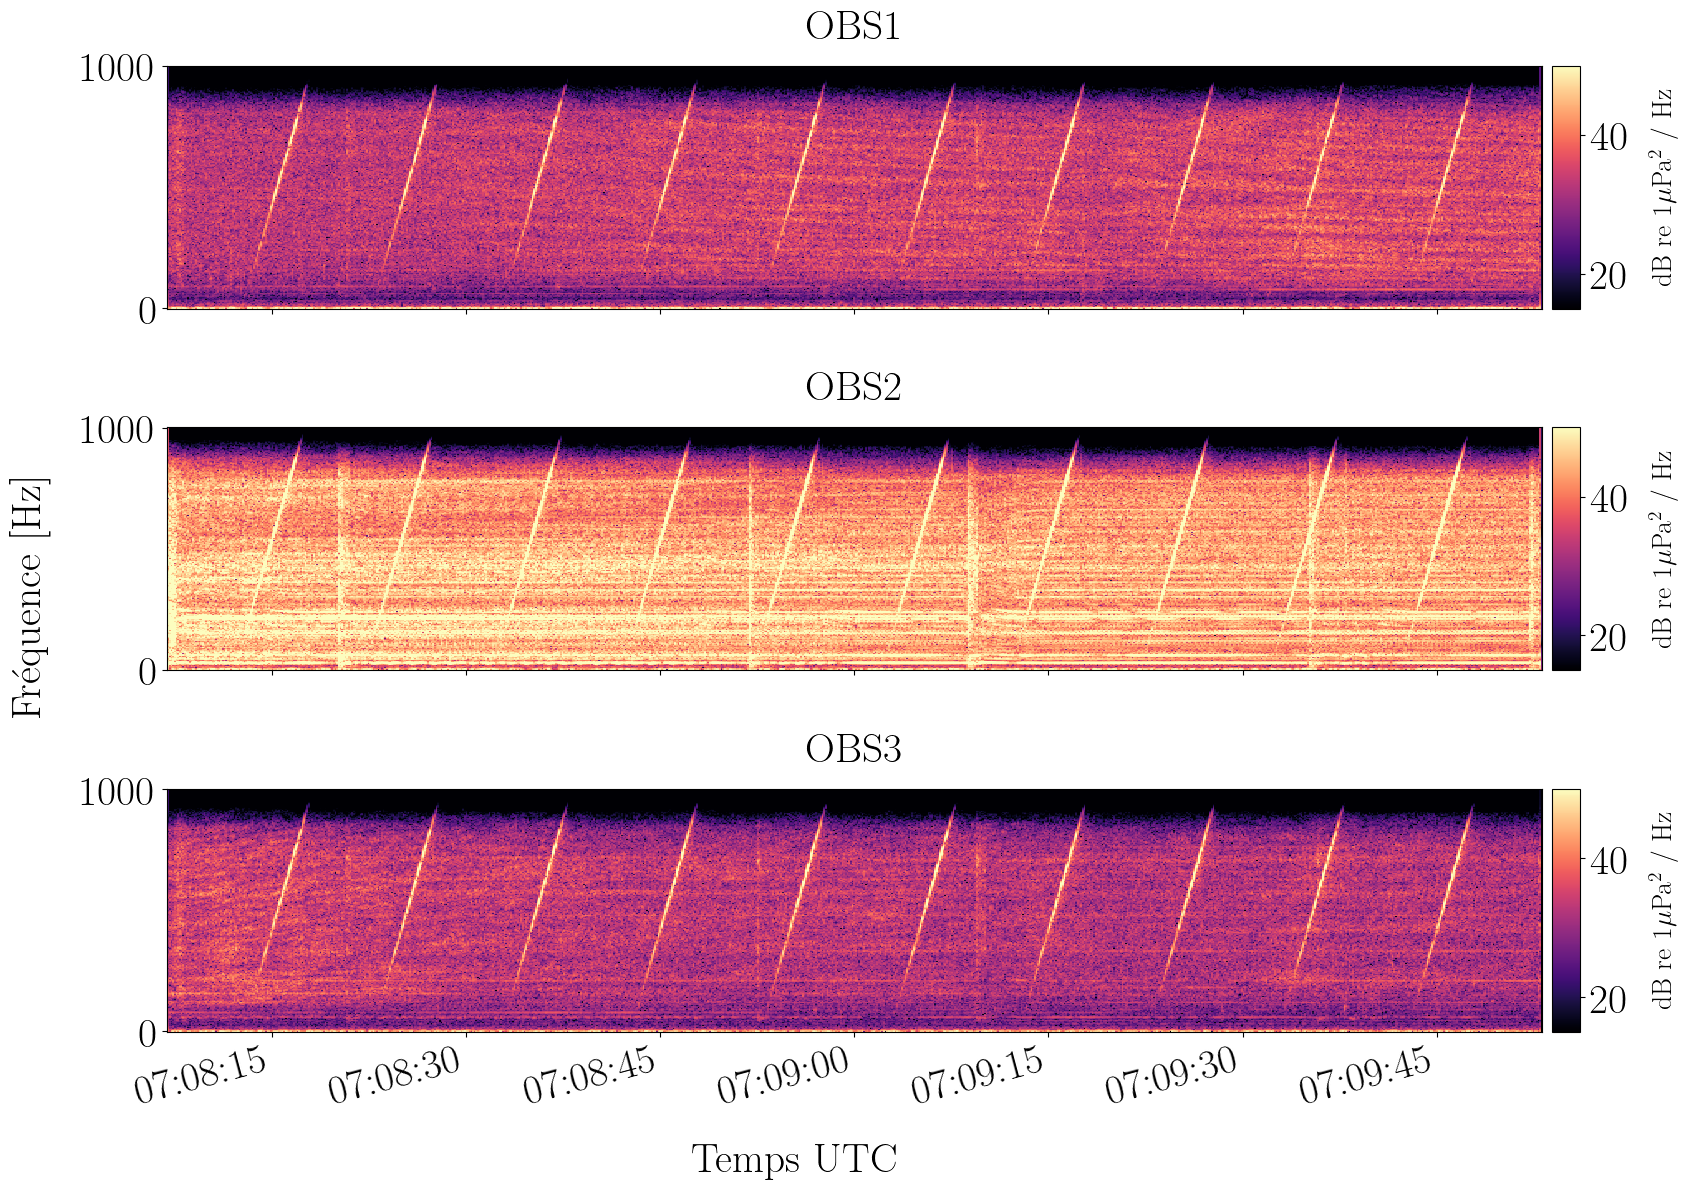

In [27]:
# Load wav data and plot the corresponding sequence
ds_wav = xr.open_dataset(os.path.join(data_folder, "channel_H_wav.nc"))

datetime_fmt = ds_sig.attrs["datetime_format"]
t_start = ds_sig.attrs[f"start_datetime"]
t_start = datetime.strptime(t_start, datetime_fmt)
t_end = t_start + timedelta(seconds=int(np.ceil(np.max(ds_sig.time.values))))


# Paramètre STFT
nperseg = 2**9
noverlap = 2**8

fig, axs = plt.subplots(3, 1, sharex=True, figsize=(16, 12))
axs = np.atleast_1d(axs)

for i, obs_id in enumerate([1, 2, 3]):

    datetime_fmt = ds_wav.attrs["datetime_format"]

    sig_varname = f"signal_obs{obs_id}"
    time_coordsname = f"time{obs_id}"
    signal = ds_wav[sig_varname]

    # Select a window of the signal
    fs = ds_wav.attrs[f"fs_obs{obs_id}"]

    # Start of recording
    t0 = ds_wav.attrs[f"start_datetime_obs{obs_id}"]
    t0 = datetime.strptime(t0, datetime_fmt)

    # Select window
    t_from_t0_start_s = (t_start - t0).total_seconds()
    n_start = int(t_from_t0_start_s * fs)
    t_from_t0_end_s = (t_end - t0).total_seconds()
    n_end = int(t_from_t0_end_s * fs)

    # Slice signal
    sig_win = signal.isel({time_coordsname: slice(n_start, n_end)})

    # Define datetime borders
    t0_slice = t0 + timedelta(seconds=n_start * 1 / fs)
    t1_slice = t0 + timedelta(seconds=n_end * 1 / fs)

    # Derive stft
    ff, tt, stft = sp.stft(
        sig_win.values,  # .values -> ici on charge les données en mémoire (un tout petit subset seulement)
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        scaling="psd",  # U^2 / Hz
    )
    sxx = 10 * np.log10(np.abs(stft))  # dB re 1uPa**2 / Hz ou dB re 1 (m/s)^2 / Hz
    # Associated datetime vector
    tt_datetime = pd.date_range(
        t0_slice,
        t0_slice + timedelta(seconds=tt[-1]),
        freq=f"{tt[1]-tt[0]}s",
        inclusive="both",
    )

    # Plot
    cmap = "magma"
    # vmin = np.percentile(sxx, 10)
    # vmax = np.percentile(sxx, 99)
    print(vmin, vmax)
    vmin = 15
    vmax = 50

    im = axs[i].pcolormesh(tt_datetime, ff, sxx, cmap=cmap, vmin=vmin, vmax=vmax)

    clabel = r"dB re 1$\mu$Pa$^2$ / Hz"
    divider = make_axes_locatable(axs[i])
    cax = divider.append_axes("right", size="2%", pad=0.10)
    cbar = fig.colorbar(im, cax=cax, orientation="vertical")
    cbar.set_label(clabel, fontsize=20)  # Set label font size

    # axs[ich].colorbar(im, label=clabel)

    axs[i].set_title(f"OBS{obs_id}")
    # axs[i].set_ylim([fmin, fmax])

formatter = mdates.DateFormatter("%H:%M:%S")
axs[-1].xaxis.set_major_formatter(formatter)
formatter = mdates.DateFormatter("%H:%M:%S")
axs[-1].xaxis.set_major_formatter(formatter)
locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
axs[-1].xaxis.set_major_locator(locator)
plt.setp(axs[-1].get_xticklabels(), rotation=15, ha="right")


fig.supylabel("Fréquence [Hz]")
fig.supxlabel("Temps UTC")
# fig.suptitle(f"OBS{obs_id}")

fpath = os.path.join(fig_folder, "spectro_3obs.png")
plt.savefig(fpath, bbox_inches="tight")

In [28]:
tt_datetime

DatetimeIndex([       '2025-10-16 07:08:07', '2025-10-16 07:08:07.128000',
               '2025-10-16 07:08:07.256000', '2025-10-16 07:08:07.384000',
               '2025-10-16 07:08:07.512000', '2025-10-16 07:08:07.640000',
               '2025-10-16 07:08:07.768000', '2025-10-16 07:08:07.896000',
               '2025-10-16 07:08:08.024000', '2025-10-16 07:08:08.152000',
               ...
               '2025-10-16 07:09:51.960000', '2025-10-16 07:09:52.088000',
               '2025-10-16 07:09:52.216000', '2025-10-16 07:09:52.344000',
               '2025-10-16 07:09:52.472000', '2025-10-16 07:09:52.600000',
               '2025-10-16 07:09:52.728000', '2025-10-16 07:09:52.856000',
               '2025-10-16 07:09:52.984000', '2025-10-16 07:09:53.112000'],
              dtype='datetime64[ns]', length=830, freq='128ms')

## Définition des fonctions utiles 

In [16]:
def interp_deconvolution(ds):
    f_interp = ds.f_rtf.values
    freq_deconv = ds.f_deconv.values

    # Interpolate rtf_deconv at rtf frequencies
    # Interp module
    interpolator_module = interp1d(
        freq_deconv, ds.rtf_amp_deconv.values, axis=1, fill_value="extrapolate"
    )
    rtf_deconvolution_module_interp = interpolator_module(f_interp)

    # Interp unwrapped phase
    unwrapped_phase_deconv = np.unwrap(ds.rtf_phase_deconv.values, axis=1)
    interpolator_phase = interp1d(
        freq_deconv, unwrapped_phase_deconv, axis=1, fill_value="extrapolate"
    )
    rtf_deconvolution_phase_unwrapped_interp = interpolator_phase(f_interp)
    # Wrap the interpolated unwrapped phase back to [-pi, pi]
    rtf_deconvolution_phase_interp = (rtf_deconvolution_phase_unwrapped_interp + np.pi) % (2 * np.pi) - np.pi

    # Build interpolated complex RTF
    rtf_deconvolution_interp = rtf_deconvolution_module_interp * np.exp(1j * rtf_deconvolution_phase_interp)

    return f_interp, rtf_deconvolution_interp

In [17]:
def plot_features_ipulse(
    rtf_cs_evd,
    rtf_deconvolution_interp,
    freq,
    i_pulse=0,
    rtf_deconvolution=None,
    freq_deconv=None,
    save=False, 
    root_img=None, 
):
    n_rcv = rtf_cs_evd.shape[0]
    # # Compare module
    # fig, ax_mod = plt.subplots(
    #     nrows=n_rcv, ncols=1, sharex=True, sharey="row", figsize=(16, 3 * n_rcv)
    # )

    idx_rcv_plot = [
        idx
        for idx in rtf_cs_evd.h_index.values
        if idx != ds.reference_receiver_id
    ]

    fig, ax_mod = plt.subplots(
        nrows=len(idx_rcv_plot), ncols=1, sharex=True, sharey="row", figsize=(16, 10)
    )

    # Module
    i_ax = 0
    for id_rcv in idx_rcv_plot:
        i_rcv = np.argmin(np.abs(rtf_cs_evd.h_index.values - id_rcv))

        h_plot = i_rcv + 1

        ax_mod[i_ax].plot(freq, np.abs(rtf_cs_evd[i_rcv, :, i_pulse]), label="CS-EVD", color=color(0))
        ax_mod[i_ax].plot(
            freq,
            np.abs(rtf_deconvolution_interp[i_rcv, :, i_pulse]),
            label="Deconvolution Interp",
            color=color(1),
            linestyle="-",
        )

        if rtf_deconvolution is not None and freq_deconv is not None:
            ax_mod[i_ax].plot(
                freq_deconv,
                np.abs(rtf_deconvolution[i_rcv, :, i_pulse]),
                label="Deconvolution",
                color=color(2),
                linestyle="--",

            )

        ax_mod[i_ax].set_title(f"OBS {h_plot}")
        ax_mod[i_ax].set_ylim([0.001, 1000])
        ax_mod[i_ax].set_yscale("log")
        ax_mod[i_ax].set_xlabel("")
        ax_mod[i_ax].set_ylabel(r"$|\Pi|$")
        ax_mod[i_ax].legend(fontsize=10, ncol=3, loc="lower right")

        i_ax += 1

    set_subfigures_abc_labels(
        axs=ax_mod, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
    )
    fig.supxlabel("Frequency [Hz]")

    if save and root_img is not None: 
        fpath = os.path.join(root_img, f"rtf_deconv_vs_cs_evd_module_replica_{i_pulse}.png")
        plt.savefig(fpath)

    # Wrapped phase
    fig, ax_phase_wrapped = plt.subplots(
        nrows=len(idx_rcv_plot), ncols=1, sharex=True, sharey="row", figsize=(16, 10)
    )
    i_ax = 0
    for id_rcv in idx_rcv_plot:
        i_rcv = np.argmin(np.abs(rtf_cs_evd.h_index.values - id_rcv))

        h_plot = i_rcv + 1

        ax_phase_wrapped[i_ax].plot(freq, np.angle(rtf_cs_evd[i_rcv, :, i_pulse]), label="CS-EVD", color=color(0))
        ax_phase_wrapped[i_ax].plot(
            freq,
            np.angle(rtf_deconvolution_interp[i_rcv, :, i_pulse]),
            label="Deconvolution Interp",
            color=color(1),
            linestyle="-",
        )

        if rtf_deconvolution is not None and freq_deconv is not None:
            ax_phase_wrapped[i_ax].plot(
                freq_deconv,
                np.angle(rtf_deconvolution[i_rcv, :, i_pulse]),
                label="Deconvolution",
                color=color(2),
                linestyle="--",
            )
        ax_phase_wrapped[i_ax].set_title(f"OBS {h_plot}")
        ax_phase_wrapped[i_ax].set_xlabel("")
        ax_phase_wrapped[i_ax].set_ylabel(r"Phase [rad]")
        ax_phase_wrapped[i_ax].legend(fontsize=10, ncol=3, loc="lower right")

        i_ax += 1

    set_subfigures_abc_labels(
        axs=ax_phase_wrapped, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
    )
    fig.supxlabel("Frequency [Hz]")

    if save and root_img is not None: 
        fpath = os.path.join(root_img, f"rtf_deconv_vs_cs_evd_phase_replica_{i_pulse}.png")
        plt.savefig(fpath)

    # Unwrapped phase
    fig, ax_phase = plt.subplots(
        nrows=len(idx_rcv_plot), ncols=1, sharex=True, sharey="row", figsize=(16, 10)
    )
    i_ax = 0
    for id_rcv in idx_rcv_plot:
        i_rcv = np.argmin(np.abs(rtf_cs_evd.h_index.values - id_rcv))
        h_plot = i_rcv + 1

        ax_phase[i_ax].plot(freq, np.unwrap(np.angle(rtf_cs_evd[i_rcv, :, i_pulse])), label="CS-EVD", color=color(0))
        ax_phase[i_ax].plot(
            freq,
            np.unwrap(np.angle(rtf_deconvolution_interp[i_rcv, :, i_pulse])),
            label="Deconvolution Interp",
            color=color(1),
            linestyle="-",
        )

        if rtf_deconvolution is not None and freq_deconv is not None:
            ax_phase[i_ax].plot(
                freq_deconv,
                np.unwrap(np.angle(rtf_deconvolution[i_rcv, :, i_pulse])),
                label="Deconvolution",
                color=color(2),
                linestyle="--",
            )

        ax_phase[i_ax].set_title(f"OBS {h_plot}")
        ax_phase[i_ax].set_xlabel("")
        ax_phase[i_ax].set_ylabel(r"Phase [rad]")
        ax_phase[i_ax].legend(fontsize=10, ncol=3, loc="lower right")

        i_ax += 1

    set_subfigures_abc_labels(
        axs=ax_phase, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
    )
    fig.supxlabel("Frequency [Hz]")

    if save and root_img is not None: 
        fpath = os.path.join(root_img, f"rtf_deconv_vs_cs_evd_unwrapped_phase_replica_{i_pulse}.png")
        plt.savefig(fpath)

### Illustration sur un pulse 

In [18]:
ds = ds.sel(f_rtf=slice(fmin, fmax), f_deconv=slice(fmin, fmax))

freq = ds.f_rtf.values
freq_deconv = ds.f_deconv.values

# Build complex RTFs
rtf_cs_evd = ds.rtf_amp * np.exp(1j * ds.rtf_phase)
rtf_deconvolution = ds.rtf_amp_deconv * np.exp(1j * ds.rtf_phase_deconv)
f, rtf_deconvolution_interp = interp_deconvolution(ds)

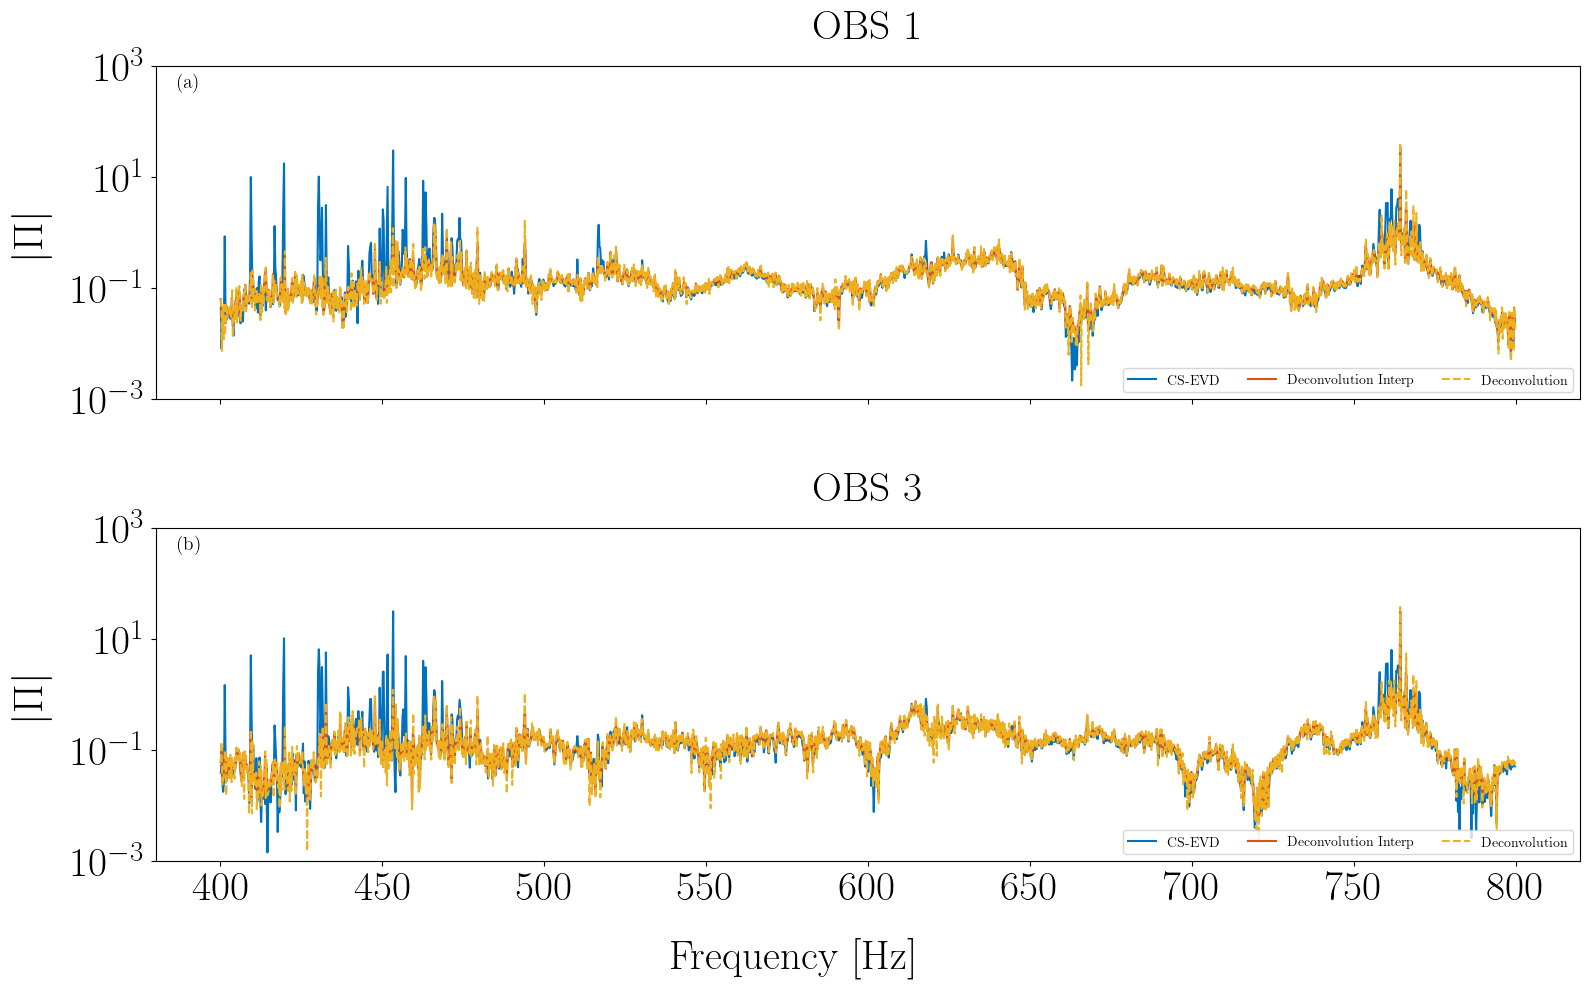

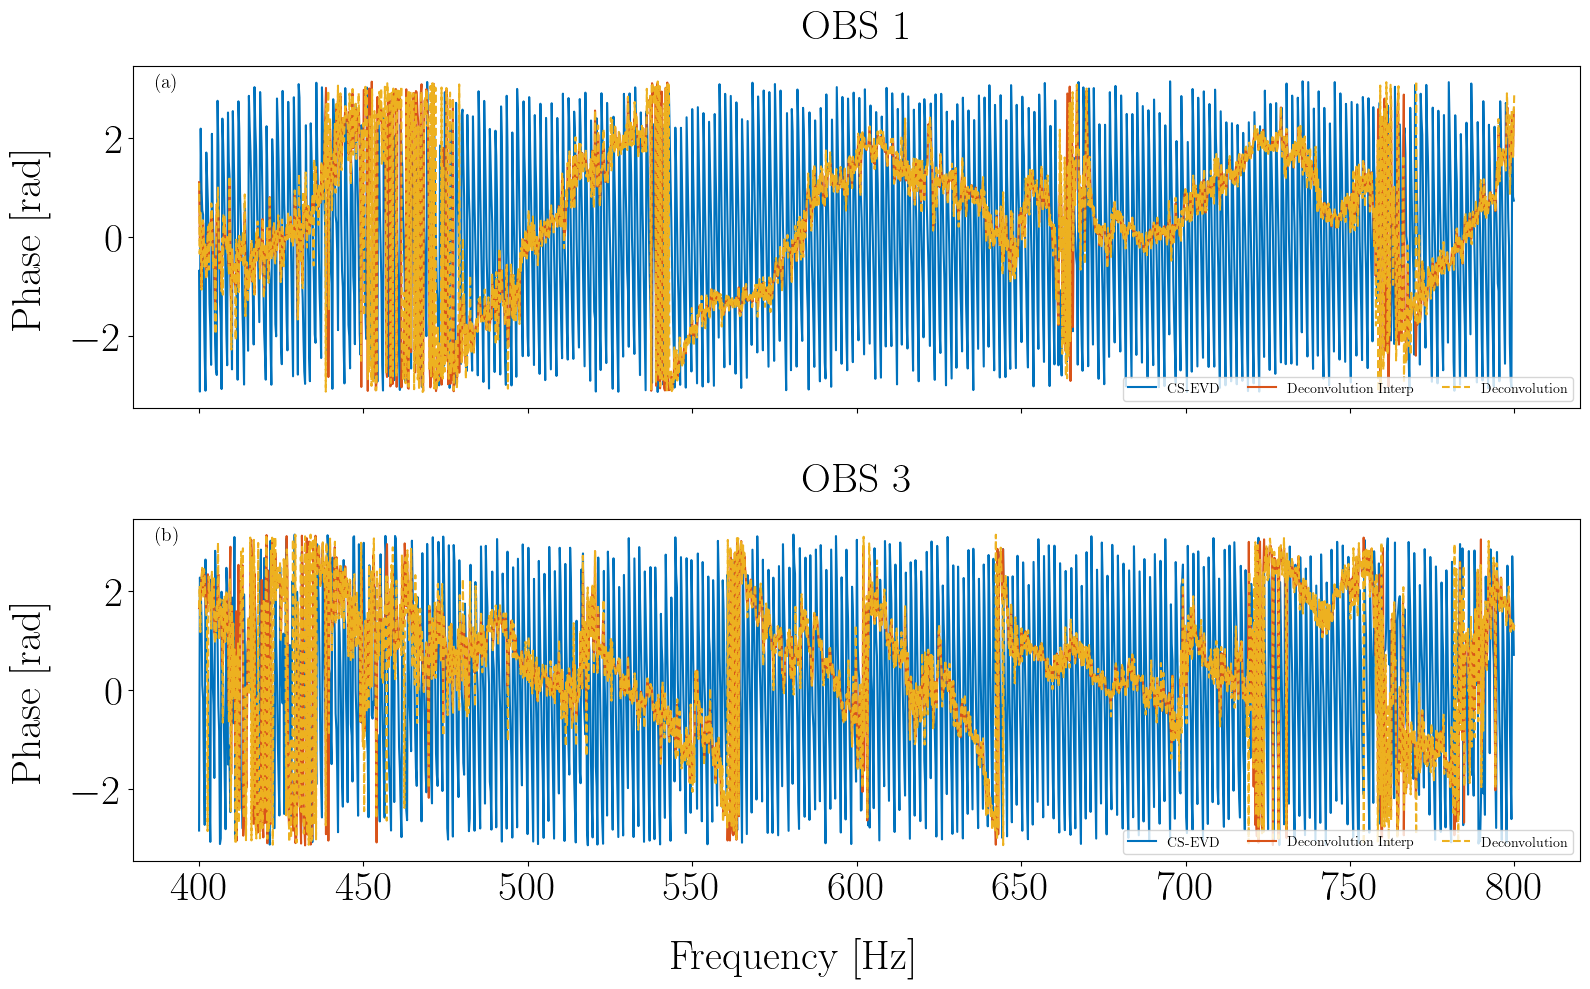

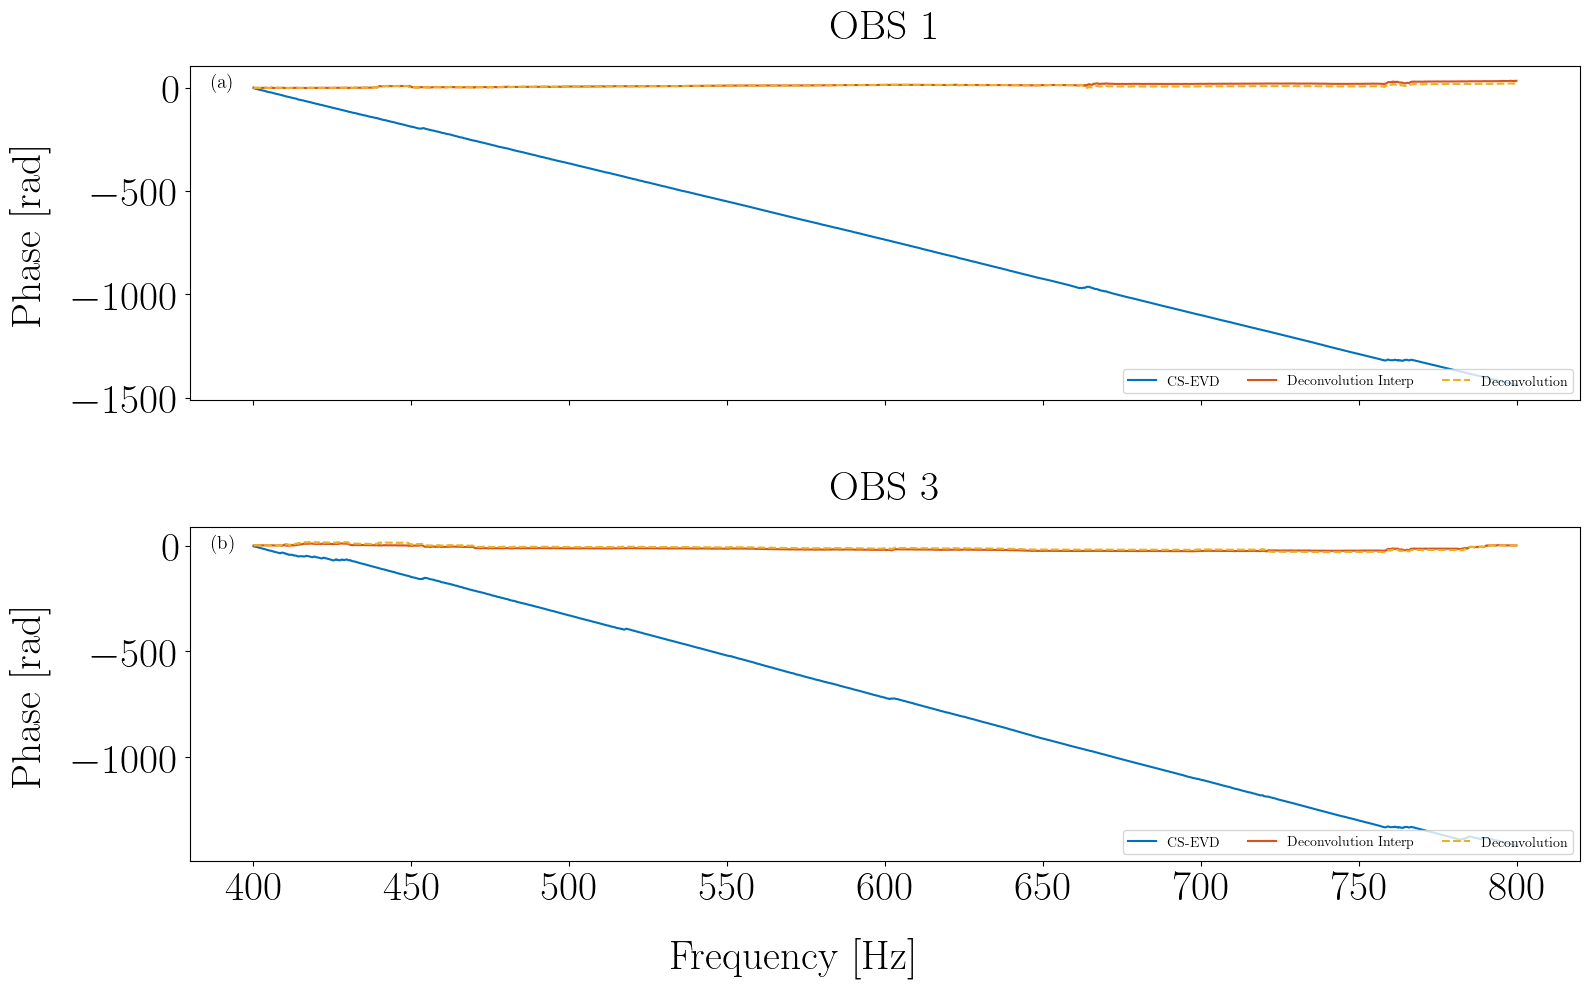

In [19]:
save = True

plot_features_ipulse(
    rtf_cs_evd=rtf_cs_evd,
    rtf_deconvolution_interp=rtf_deconvolution_interp,
    freq=f,
    i_pulse=0,
    rtf_deconvolution=rtf_deconvolution,
    freq_deconv=freq_deconv,
    save=save,
    root_img=fig_folder,
)

### Une remarque sur l'importance de la phase du vecteur de RTF

In [20]:
# Calcul de l'angle hermitien
i_pulse = 0
dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}
rtf_test = rtf_cs_evd.values

dist = D_hermitian_angle_fast(
    rtf_ref=rtf_deconvolution_interp[..., i_pulse],
    rtf=rtf_test[..., i_pulse],
    **dist_kwargs,
)
print(f"theta cs-evd vs deconvolution = {dist:.4f}°")

rtf_test = np.abs(rtf_cs_evd) * np.exp(1j * np.angle(rtf_deconvolution_interp))
rtf_test = rtf_test.values

dist = D_hermitian_angle_fast(
    rtf_ref=rtf_deconvolution_interp[..., i_pulse],
    rtf=rtf_test[..., i_pulse],
    **dist_kwargs,
)
print(f"theta test vs deconvolution = {dist:.4f}°")

theta cs-evd vs deconvolution = 16.9863°
theta test vs deconvolution = 3.5249°


La phase du vecteur de RTF à un impact important sur la mesure de similarité $\theta$. En effet, s'il l'on construit un vecteur de RTF "test" : 

$$
\Pi_{\text{test}} = \lvert \Pi_{\text{CS-EVD}} \rvert \times \text{e}^{i \Phi(\Pi_{\text{deconvolution}})}
$$

où la phase du vecteur de RTF estimé par la méthode CS-EVD est remplacée par la phase du vecteur de RTF de référence (estimé par déconvolution), la distance $\theta$ varie d'un ordre de grandeur. 


## Application à toute la séquence 

In [21]:
from dtaidistance import dtw

def process_all_pulses(freq, rtf_cs_evd, rtf_deconvolution_interp, plot_feature=False, use_deconvolution_phase=False):

    dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": False}


    theta_dist = []
    theta_mod_dist = []
    theta_along_f_dist = []
    d_euc_mod = []
    d_euc = []
    dist_dtw = []


    for i_pulse in range(rtf_cs_evd.shape[-1]):

        if plot_feature:
            plot_features_ipulse(
                rtf_cs_evd=rtf_cs_evd,
                rtf_deconvolution_interp=rtf_deconvolution_interp,
                freq=freq,
                i_pulse=i_pulse,
            )


        # # Compute theta distance
        rtf = np.abs(rtf_cs_evd[..., i_pulse])
        rtf_ref = np.abs(rtf_deconvolution_interp[..., i_pulse])
        theta_mod = D_hermitian_angle_fast(
            rtf_ref=rtf_ref,
            rtf=rtf,
            **dist_kwargs,
        )
        theta_mod = np.percentile(theta_mod, 50)
        theta_mod_dist.append(theta_mod)

        dist = D_hermitian_angle_fast(
            rtf_ref=rtf_deconvolution_interp[..., i_pulse],
            rtf=rtf_cs_evd[..., i_pulse],
            **dist_kwargs,

        )
        dist = np.percentile(dist, 50)

        # Compute theta along f for each rcv
        dist_f = []
        for i_rcv in range(rtf_cs_evd.shape[0]):
            # rtf_ref = rtf_deconvolution_interp[i_rcv, :, i_pulse]
            # rtf = rtf_cs_evd[i_rcv, :, i_pulse]

            rtf_ref = np.abs(rtf_deconvolution_interp[i_rcv, :, i_pulse])
            rtf = np.abs(rtf_cs_evd[i_rcv, :, i_pulse])

            inner_prod = np.abs(np.sum(rtf_ref.conj() * rtf))
            norm_ref = np.linalg.norm(rtf_ref)
            norm_rtf = np.linalg.norm(rtf)
            # norm_ref = np.
            # norm_rtf = np.linalg.norm(rtf)

            # Cosine of Hermitian angle, clipped for stability
            cos_angle = np.clip(inner_prod / (norm_ref * norm_rtf), -1.0, 1.0)
            d_f = np.arccos(cos_angle)
            d_f = np.rad2deg(d_f)
            print(d_f)
            dist_f.append(d_f)

        dist_f = np.mean(dist_f)

        d_mod = np.mean(np.linalg.norm(
            np.abs(rtf_deconvolution_interp[..., i_pulse]) - np.abs(rtf_cs_evd[..., i_pulse]), axis=1
        ))

        # Absolute diff in log (correspond to what we usually visualize)
        # d_mod = np.mean(np.linalg.norm(
        #     10 * np.log10(np.abs(rtf_deconvolution_interp[..., i_pulse])) - 10 * np.log10(np.abs(rtf_cs_evd[..., i_pulse])), axis=1
        # ))

        # d1_along_f = np.linalg.norm(
        #     np.abs(rtf_deconvolution_interp[..., i_pulse])
        #     - np.abs(rtf_cs_evd[..., i_pulse]),
        #     axis=1,
        # )
        # pi_norm_along_f = np.linalg.norm(rtf_cs_evd[..., i_pulse], axis=1)
        # d_mod = np.mean(d1_along_f / pi_norm_along_f)

        d = np.mean(
            np.linalg.norm(
                rtf_deconvolution_interp[..., i_pulse]
                - rtf_cs_evd[..., i_pulse],
                axis=1,
            )
        )

        # # Dynamic Time Warping
        # d_dtww = []
        # for id_rcv in [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]:
        #     i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))

        #     d_dtw = dtw.distance(
        #         np.abs(rtf_deconvolution_interp[i_rcv, :, i_pulse]),
        #         np.abs(rtf_cs_evd[i_rcv, :, i_pulse]),
        #     )
        #     d_dtww.append(d_dtw)
        # d_dtw = np.mean(d_dtww)
        # print(d_dtw)

        if use_deconvolution_phase:
            dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}
            rtf_test = np.abs(rtf_cs_evd) * np.exp(1j * np.angle(rtf_deconvolution_interp))
            dist = D_hermitian_angle_fast(
                rtf_ref=rtf_deconvolution_interp[..., i_pulse],
                rtf=rtf_test[..., i_pulse],
                **dist_kwargs,
            )


        theta_dist.append(dist)
        theta_along_f_dist.append(dist_f)
        d_euc_mod.append(d_mod)
        d_euc.append(d)
        # dist_dtw.append(d_dtw)


    return np.array(theta_dist), np.array(theta_mod_dist), np.array(theta_along_f_dist), np.array(d_euc_mod), np.array(d_euc), np.array(dist_dtw)

In [22]:
theta, theta_mod, theta_f, d_euc_mod, d_euc, dist_dtw = process_all_pulses(
    freq=f,
    rtf_cs_evd=rtf_cs_evd.values,
    rtf_deconvolution_interp=rtf_deconvolution_interp,
    plot_feature=False,
    use_deconvolution_phase=False,
)

theta_same_phase, theta_mod, theta_f_same_phase, d_euc_mod, d_euc, dist_dtw = (
    process_all_pulses(
        freq=f,
        rtf_cs_evd=rtf_cs_evd.values,
        rtf_deconvolution_interp=rtf_deconvolution_interp,
        plot_feature=False,
        use_deconvolution_phase=True,
    )
)

73.1681
0.01978234
72.44327
72.943275
0.01978234
64.34929
58.496742
0.01978234
42.888832
32.286335
0.01978234
31.263641
51.95605
0.01978234
41.437416
73.8092
0.01978234
73.79823
69.84403
0.01978234
70.88502
74.56974
0.01978234
70.734375
65.70685
0.01978234
64.36715
55.607506
0.01978234
53.90755
73.1681
0.01978234
72.44327
72.943275
0.01978234
64.34929
58.496742
0.01978234
42.888832
32.286335
0.01978234
31.263641
51.95605
0.01978234
41.437416
73.8092
0.01978234
73.79823
69.84403
0.01978234
70.88502
74.56974
0.01978234
70.734375
65.70685
0.01978234
64.36715
55.607506
0.01978234
53.90755


In [23]:
def get_dist_to_rcv(ds):
    e = ds["e_replica"].values
    n = ds["n_replica"].values

    rep_pos = np.column_stack((e, n))
    dist_to_rcv = []
    for i_rcv in ds.h_index.values:
        e_rcv = ds.attrs[f"obs{i_rcv}_e_apriori"]
        n_rcv = ds.attrs[f"obs{i_rcv}_n_apriori"]
        rcv_pos = np.column_stack((e_rcv, n_rcv))

        spatial_dist = cdist(rep_pos, rcv_pos, metric="euclidean")
        dist_to_rcv.append(spatial_dist)

    return np.array(dist_to_rcv)

In [24]:
dist_rcv = get_dist_to_rcv(ds)
obs_cpa_idx = np.argmin(dist_rcv, axis=1).flatten()
reps = ds.replica_id.values

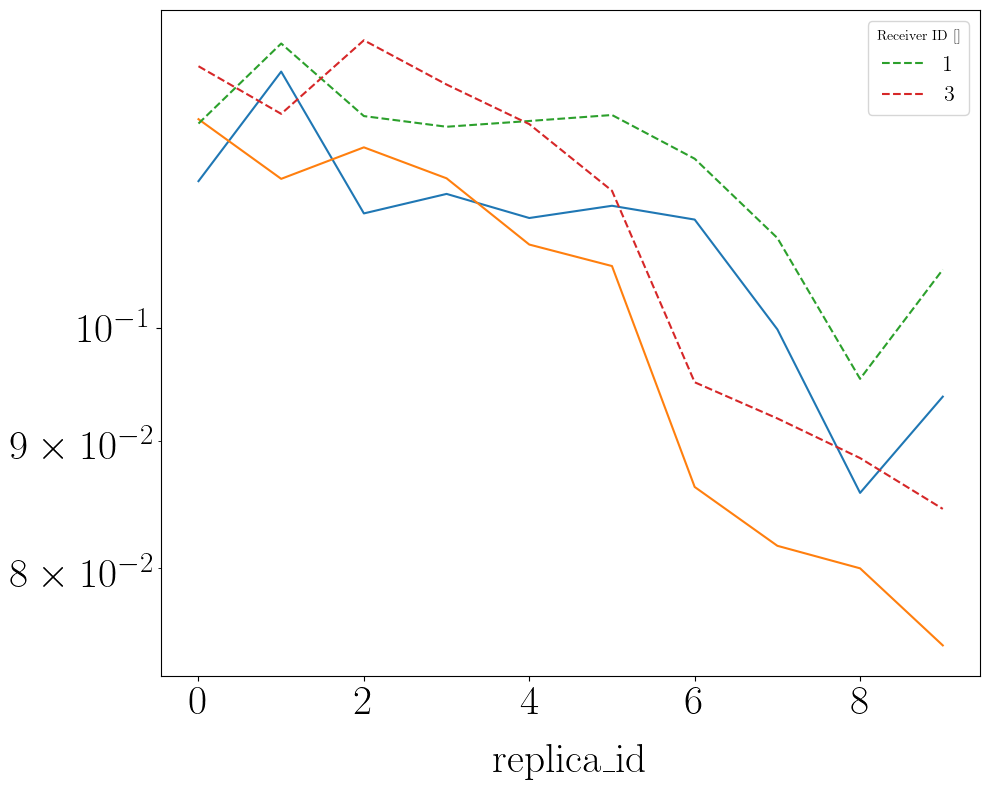

In [25]:
print()
# fig, axs = plt.subplots(2, 1, sharex=True)
np.abs(rtf_cs_evd).median(dim="f_rtf").sel(h_index=[idx for idx in rtf_cs_evd.h_index.values if idx != ds.reference_receiver_id]).plot(hue="h_index")
np.abs(rtf_deconvolution).median(dim="f_deconv").sel(
    h_index=[
        idx for idx in rtf_cs_evd.h_index.values if idx != ds.reference_receiver_id
    ]
).plot(hue="h_index", linestyle="--")

plt.yscale("log")
# np.abs(rtf_cs_evd).max(dim="f_rtf").sel(
#     h_index=[
#         idx for idx in rtf_cs_evd.h_index.values if idx != ds.reference_receiver_id
#     ]
# ).plot(ax=axs[0], hue="h_index")

Le module des deux estimateurs convergent lorsque le rapport des fonctions de transfert tend vers 1. Ceci correspond aux positions équidistantes des deux capteurs.

In [26]:
# d_euc_mod = 1 / d_euc_mod
# d_euc = 1/ d_euc
d_euc_mod_norm = (d_euc_mod - d_euc_mod.min()) / (d_euc_mod.max() - d_euc_mod.min()) * 90
d_euc_norm = (d_euc - d_euc.min()) / (d_euc.max() - d_euc.min()) * 90
# d_dtw = (dist_dtw - dist_dtw.min()) / (dist_dtw.max() - dist_dtw.min()) * 90

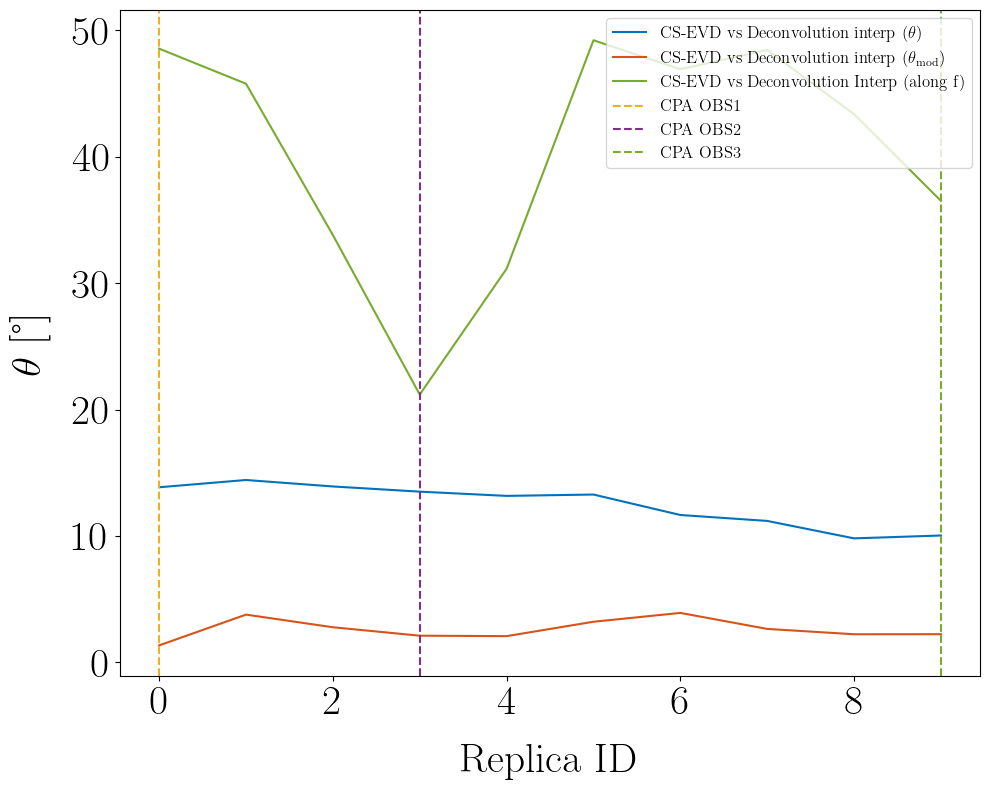

In [27]:
plt.figure()
plt.plot(
    reps,
    theta,
    label=r"CS-EVD vs Deconvolution interp ($\theta$)",
    color=color(0),
)
plt.plot(reps, theta_mod, label=r"CS-EVD vs Deconvolution interp ($\theta_{\text{mod}}$)", color=color(1))
# plt.plot(
#     reps,
#     d_dtw,
#     label=r"DTW",
#     color=color(5),
# )

# plt.plot(reps, theta_same_phase, label="CS-EVD amp + Deconv phase vs Deconvolution Interp", color=color(1))

# plt.plot(
#     reps,
#     d_euc_mod_norm,
#     label=r"$\lVert \lvert \Pi \rvert  - \lvert \Pi^{(ref)} \rvert \rVert$",
#     color=color(2),
# )
# plt.plot(
#     reps,
#     d_euc_norm,
#     label=r"$\lVert \Pi   -  \Pi^{(ref)}  \rVert$",
#     color=color(3),
# )
plt.plot(reps, theta_f, label="CS-EVD vs Deconvolution Interp (along f)", color=color(4))


for i_rcv in range(dist_rcv.shape[0]):
    plt.axvline(reps[obs_cpa_idx[i_rcv]], color=color(2+i_rcv), label=f"CPA OBS{i_rcv+1}", linestyle="--")
plt.ylabel(r"$\theta$ [°]")
plt.xlabel("Replica ID")
plt.legend(fontsize=12, loc="upper right")

# fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(16, 5), sharex=True)

# axs[0].plot(ds.replica_id.values, theta, label="CS-EVD vs Deconvolution Interp", color=color(0))
# axs[0].plot(ds.replica_id.values, theta_same_phase, label="CS-EVD amp + Deconv phase vs Deconvolution Interp", color=color(1))
# axs[0].set_ylabel(r"$\theta$ [°]")
# axs[0].legend()

# axs[1].plot(ds.replica_id.values, dist_rcv[0], label="Distance to OBS1", color=color(0))
# axs[1].plot(ds.replica_id.values, dist_rcv[1], label="Distance to OBS2", color=color(1))
# axs[1].plot(ds.replica_id.values, dist_rcv[2], label="Distance to OBS3", color=color(2))

# fig.supxlabel("Replica ID")

fpath = os.path.join(fig_folder, "theta_vs_replica_id.png")
plt.savefig(fpath)

Theta min = 9.815000534057617°, theta max = 14.431781768798828°


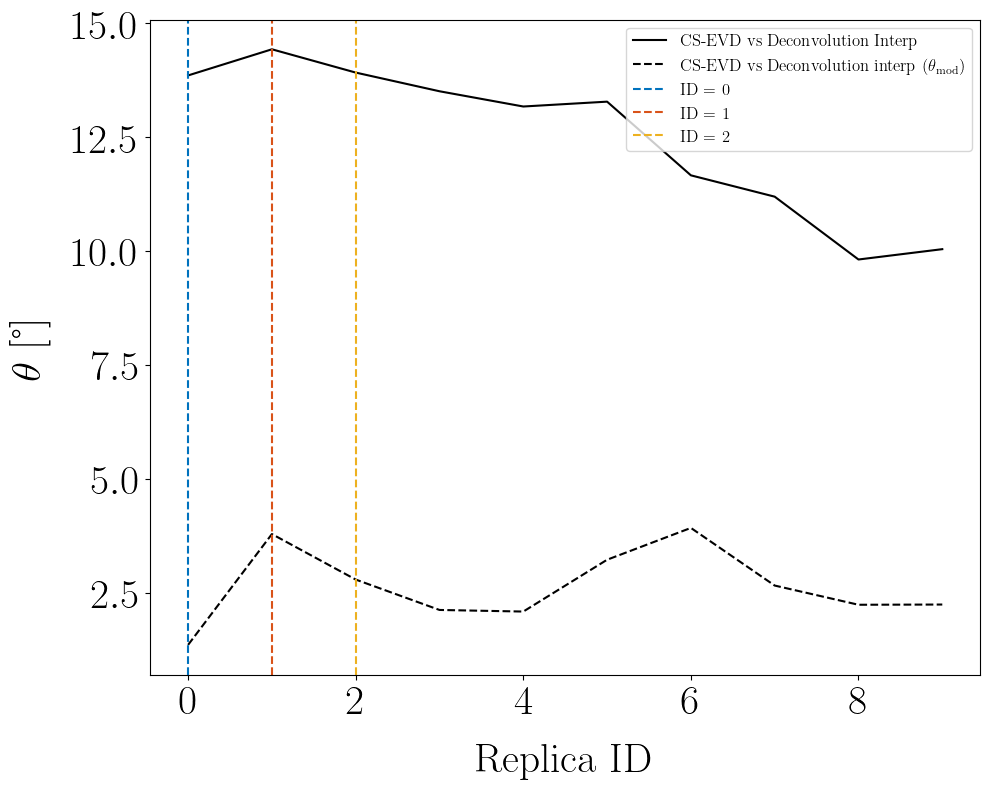

In [28]:
print(f"Theta min = {theta.min()}°, theta max = {theta.max()}°")
rep_selection = [0, 1, 2]
plt.figure()
plt.plot(reps, theta, label="CS-EVD vs Deconvolution Interp", color="k")
plt.plot(
    reps,
    theta_mod,
    label=r"CS-EVD vs Deconvolution interp ($\theta_{\text{mod}}$)",
    color="k",
    linestyle="--",
)

for i, rep_i in enumerate(rep_selection):
    plt.axvline(
        reps[rep_i],
        color=color(i),
        label=f"ID = {rep_i}",
        linestyle="--",
    )
plt.ylabel(r"$\theta$ [°]")
plt.xlabel("Replica ID")
plt.legend(fontsize=12, loc="upper right")



fpath = os.path.join(fig_folder, "theta_vs_replica_id.png")
plt.savefig(fpath)

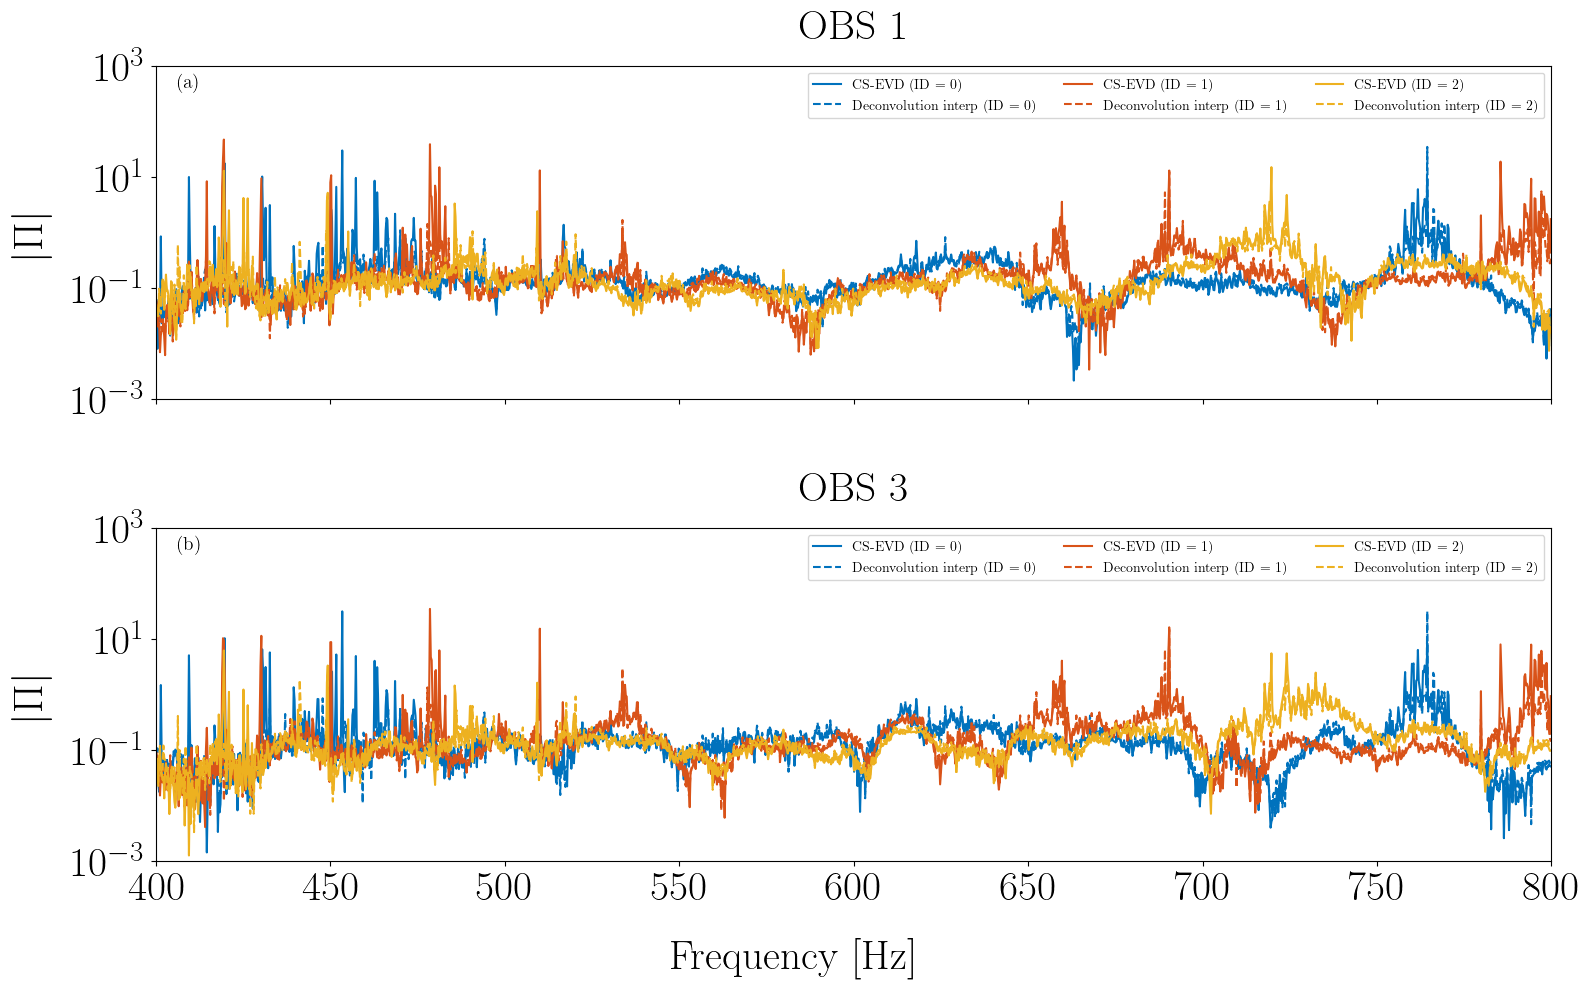

In [29]:
fmin_plot = 400
f_max_plot = 800


n_rcv = ds.h_index.size
idx_rcv_plot = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]
# i_rcv_plot = [np.argmin(np.abs(ds.h_index.values - idx)) for idx in idx_rcv_plot]
# print(i_rcv_plot)

fig, ax_mod = plt.subplots(
    nrows=len(idx_rcv_plot), ncols=1, sharex=True, sharey="row", figsize=(16, 10)
)

# Module
i_ax = 0
for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))

    #
    # h_plot = i_rcv + 1
    h_plot = id_rcv

    for i, i_pulse in enumerate(rep_selection):

        ax_mod[i_ax].plot(
            freq,
            np.abs(rtf_cs_evd[i_rcv, :, i_pulse]),
            label=f"CS-EVD (ID = {i_pulse})",
            color=color(i),
        )
        ax_mod[i_ax].plot(
            freq,
            np.abs(rtf_deconvolution_interp[i_rcv, :, i_pulse]),
            label=f"Deconvolution interp (ID = {i_pulse})",
            color=color(i),
            linestyle="--",
        )
        # ax_mod[i_ax].plot(
        #     freq_deconv,
        #     np.abs(rtf_deconvolution[i_rcv, :, i_pulse]),
        #     label=f"Deconvolution (ID = {i_pulse})",
        #     color=color(i),
        #     linestyle="--",
        # )

        ax_mod[i_ax].set_title(f"OBS {h_plot}")
        ax_mod[i_ax].set_ylim([0.001, 1000])
        ax_mod[i_ax].set_yscale("log")
        ax_mod[i_ax].set_xlabel("")
        ax_mod[i_ax].set_ylabel(r"$|\Pi|$")
        ax_mod[i_ax].legend(fontsize=10, ncol=3, loc="upper right")

    i_ax += 1

set_subfigures_abc_labels(
    axs=ax_mod, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")
plt.xlim([fmin_plot, f_max_plot])

fpath = os.path.join(fig_folder, "rtf_module_at_identified_pos.png")
plt.savefig(fpath)

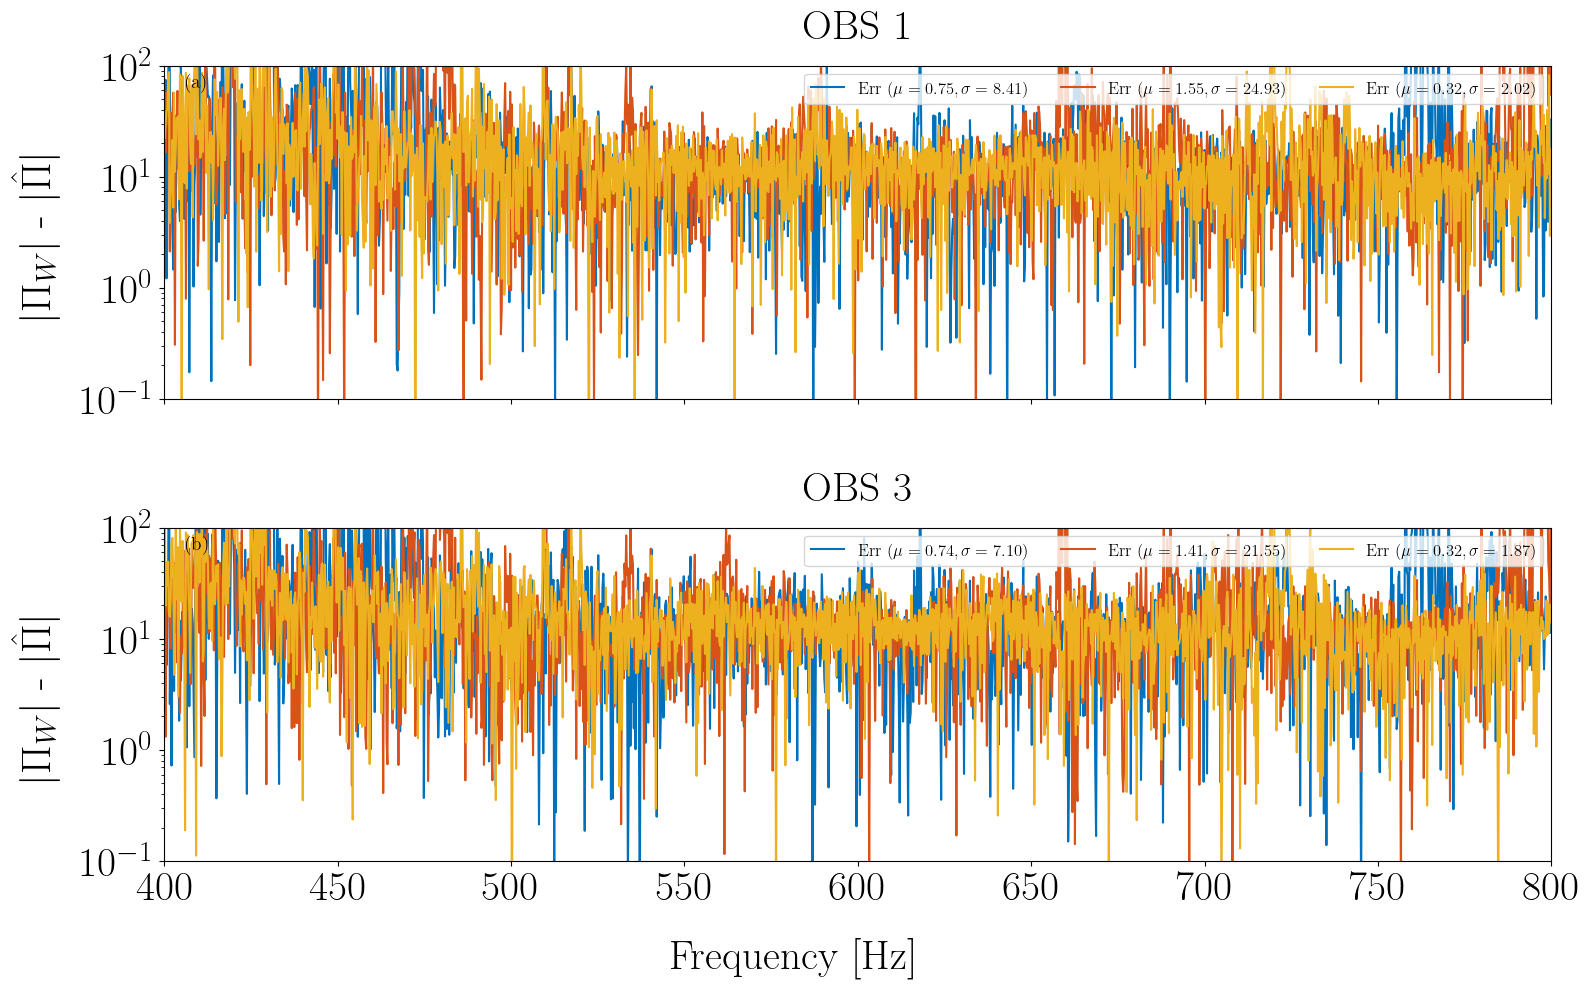

In [30]:
fmin_plot = 400
f_max_plot = 800


n_rcv = ds.h_index.size
idx_rcv_plot = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]
# i_rcv_plot = [np.argmin(np.abs(ds.h_index.values - idx)) for idx in idx_rcv_plot]
# print(i_rcv_plot)

fig, ax_mod = plt.subplots(
    nrows=len(idx_rcv_plot), ncols=1, sharex=True, sharey="row", figsize=(16, 10)
)

# Module
i_ax = 0
for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))

    #
    # h_plot = i_rcv + 1
    h_plot = id_rcv

    for i, i_pulse in enumerate(rep_selection):

        mod_err = (
            np.abs(
                np.abs(rtf_deconvolution_interp[i_rcv, :, i_pulse])
                - np.abs(rtf_cs_evd[i_rcv, :, i_pulse])
            )
            / np.abs(rtf_deconvolution_interp[i_rcv, :, i_pulse])
        )
        mu_err = np.mean(mod_err.values)
        std_err = np.std(mod_err.values)
        ax_mod[i_ax].plot(
            freq,
            mod_err.values * 100,
            label=rf"Err $(\mu = {{{mu_err:.2f}}}, \sigma = {{{std_err:.2f}}})$",
            color=color(i),
        )

        ax_mod[i_ax].set_title(f"OBS {h_plot}")
        ax_mod[i_ax].set_ylim([0.1, 100])
        ax_mod[i_ax].set_yscale("log")
        ax_mod[i_ax].set_xlabel("")
        ax_mod[i_ax].set_ylabel(r"$\lvert \Pi_W \rvert$ - $\lvert \hat{\Pi} \rvert$")
        ax_mod[i_ax].legend(fontsize=12, ncol=3, loc="upper right")

    i_ax += 1

set_subfigures_abc_labels(
    axs=ax_mod, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")
plt.xlim([fmin_plot, f_max_plot])

fpath = os.path.join(fig_folder, "rtf_module_error_at_identified_pos.png")
plt.savefig(fpath)

In [31]:
# Module
q1_err_rel = []
q2_err_rel = []
q3_err_rel = []
q1_err_abs = []
q2_err_abs = []
q3_err_abs = []


i_ax = 0
for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))

    q1_err_rel_ircv = []
    q2_err_rel_ircv = []
    q3_err_rel_ircv = []
    q1_err_abs_ircv = []
    q2_err_abs_ircv = []
    q3_err_abs_ircv = []

    for i, i_pulse in enumerate(ds.replica_id.values):

        mod_err = np.abs(
            np.abs(rtf_deconvolution_interp[i_rcv, :, i_pulse])
            - np.abs(rtf_cs_evd[i_rcv, :, i_pulse])
        )
        q1_err = np.percentile(mod_err.values, 25)
        q2_err = np.percentile(mod_err.values, 50)
        q3_err = np.percentile(mod_err.values, 75)
        q1_err_abs_ircv.append(q1_err)
        q2_err_abs_ircv.append(q2_err)
        q3_err_abs_ircv.append(q3_err)

        mod_err_r = mod_err / np.abs(rtf_deconvolution_interp[i_rcv, :, i_pulse])
        # mod_err_r = mod_err / np.abs(rtf_cs_evd[i_rcv, :, i_pulse])

        q1_err_r = np.percentile(mod_err_r.values, 25)
        q2_err_r = np.percentile(mod_err_r.values, 50)
        q3_err_r = np.percentile(mod_err_r.values, 75)
        q1_err_rel_ircv.append(q1_err_r)
        q2_err_rel_ircv.append(q2_err_r)
        q3_err_rel_ircv.append(q3_err_r)

    q1_err_rel.append(q1_err_rel_ircv)
    q2_err_rel.append(q2_err_rel_ircv)
    q3_err_rel.append(q3_err_rel_ircv)
    q1_err_abs.append(q1_err_abs_ircv)
    q2_err_abs.append(q2_err_abs_ircv)
    q3_err_abs.append(q3_err_abs_ircv)


q1_err_rel = np.array(q1_err_rel)
q2_err_rel = np.array(q2_err_rel)
q3_err_rel = np.array(q3_err_rel)
q1_err_abs = np.array(q1_err_abs)
q2_err_abs = np.array(q2_err_abs)
q3_err_abs = np.array(q3_err_abs)

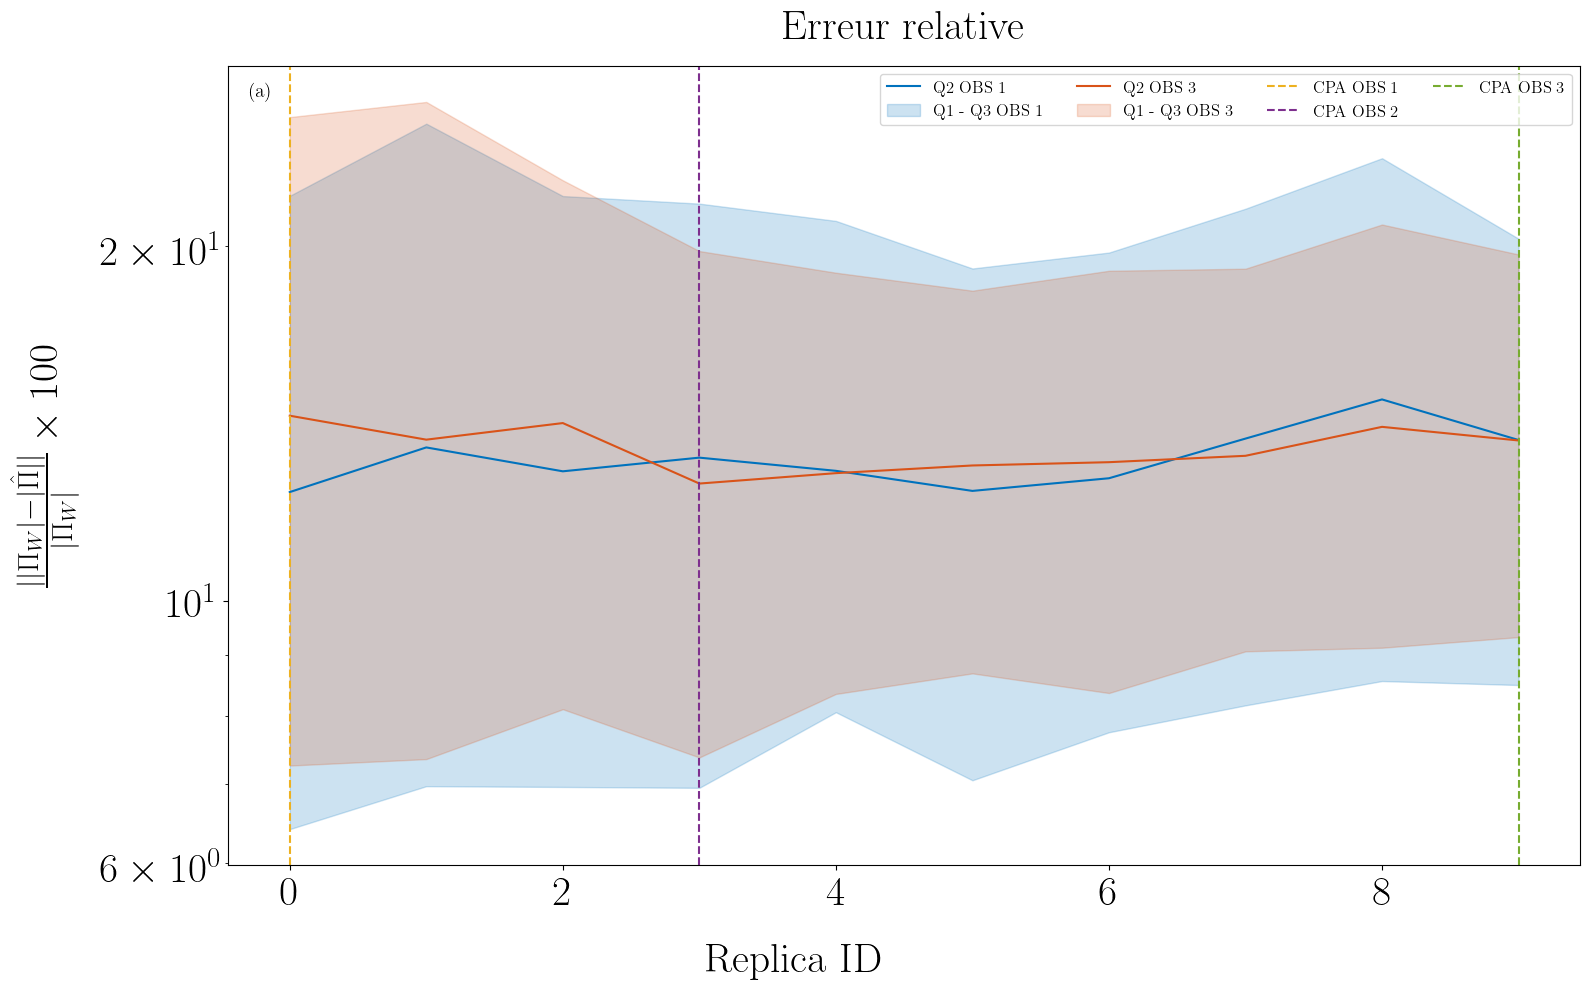

In [32]:
n_rcv = ds.h_index.size
idx_rcv_plot = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]

fig, ax_mod = plt.subplots(
    nrows=1, ncols=1, sharex=True, sharey="row", figsize=(16, 10)
)
ax_mod = np.atleast_1d(ax_mod)

for i, id_rcv in enumerate(idx_rcv_plot):

    ax_mod[0].plot(
        reps,
        q2_err_rel[i, :]*100,
        label=f"Q2 OBS {id_rcv}",
        color=color(i),
    )
    ax_mod[0].fill_between(
        reps,
        q1_err_rel[i, :]*100,
        q3_err_rel[i, :]*100,
        alpha=0.2,
        label=f"Q1 - Q3  OBS {id_rcv}",
        color=color(i),
    )

for i_rcv in range(dist_rcv.shape[0]):
    ax_mod[0].axvline(
        reps[obs_cpa_idx[i_rcv]],
        label=f"CPA OBS {i_rcv+1}",
        color=color(2 + i_rcv),
        linestyle="--",
    )


ax_mod[0].set_title(f"Erreur relative")
# ax_mod[i_ax].set_ylim([0.1, 100])
ax_mod[0].set_yscale("log")
ax_mod[0].set_xlabel("")
ax_mod[0].set_ylabel(
    r"$\frac{\lvert \lvert \Pi_W \rvert - \lvert \hat{\Pi} \rvert \rvert}{\lvert \Pi_W \rvert} \times 100$"
)
ax_mod[0].legend(fontsize=12, ncol=3, loc="upper right", ncols=4)
set_subfigures_abc_labels(
    axs=ax_mod, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Replica ID")
# plt.xlim([fmin_plot, f_max_plot])

fpath = os.path.join(fig_folder, "rtf_module_rel_error_vs_replica_id.png")
plt.savefig(fpath)

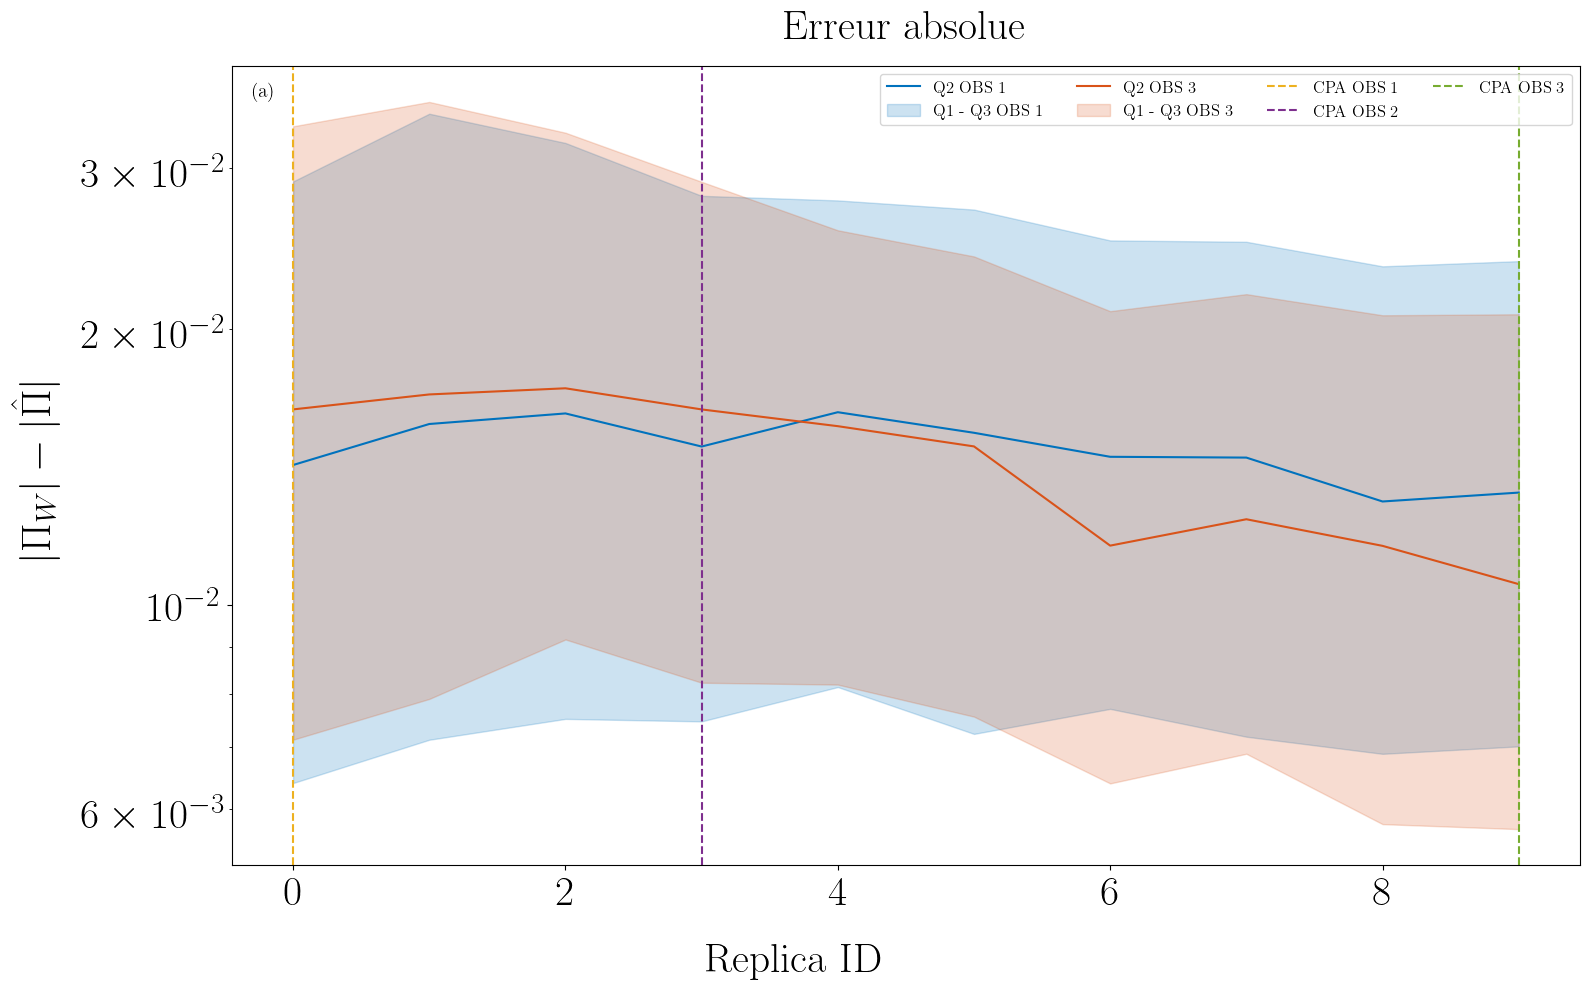

In [33]:
n_rcv = ds.h_index.size
idx_rcv_plot = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]

fig, ax_mod = plt.subplots(
    nrows=1, ncols=1, sharex=True, sharey="row", figsize=(16, 10)
)
ax_mod = np.atleast_1d(ax_mod)

for i, id_rcv in enumerate(idx_rcv_plot):

    ax_mod[0].plot(
        reps,
        q2_err_abs[i, :],
        label=f"Q2 OBS {id_rcv}",
        color=color(i),
    )
    ax_mod[0].fill_between(
        reps,
        q1_err_abs[i, :],
        q3_err_abs[i, :],
        alpha=0.2,
        label=f"Q1 - Q3  OBS {id_rcv}",
        color=color(i),
    )

for i_rcv in range(dist_rcv.shape[0]):
    ax_mod[0].axvline(
        reps[obs_cpa_idx[i_rcv]],
        label=f"CPA OBS {i_rcv+1}",
        color=color(2 + i_rcv),
        linestyle="--",
    )


ax_mod[0].set_title(f"Erreur absolue")
# ax_mod[i_ax].set_ylim([0.1, 100])
ax_mod[0].set_yscale("log")
ax_mod[0].set_xlabel("")
ax_mod[0].set_ylabel(
    r"$\lvert \Pi_W \rvert - \lvert \hat{\Pi} \rvert$"
)
ax_mod[0].legend(fontsize=12, ncol=3, loc="upper right", ncols=4)
set_subfigures_abc_labels(
    axs=ax_mod, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Replica ID")
# plt.xlim([fmin_plot, f_max_plot])

fpath = os.path.join(fig_folder, "rtf_module_abs_error_vs_replica_id.png")
plt.savefig(fpath)

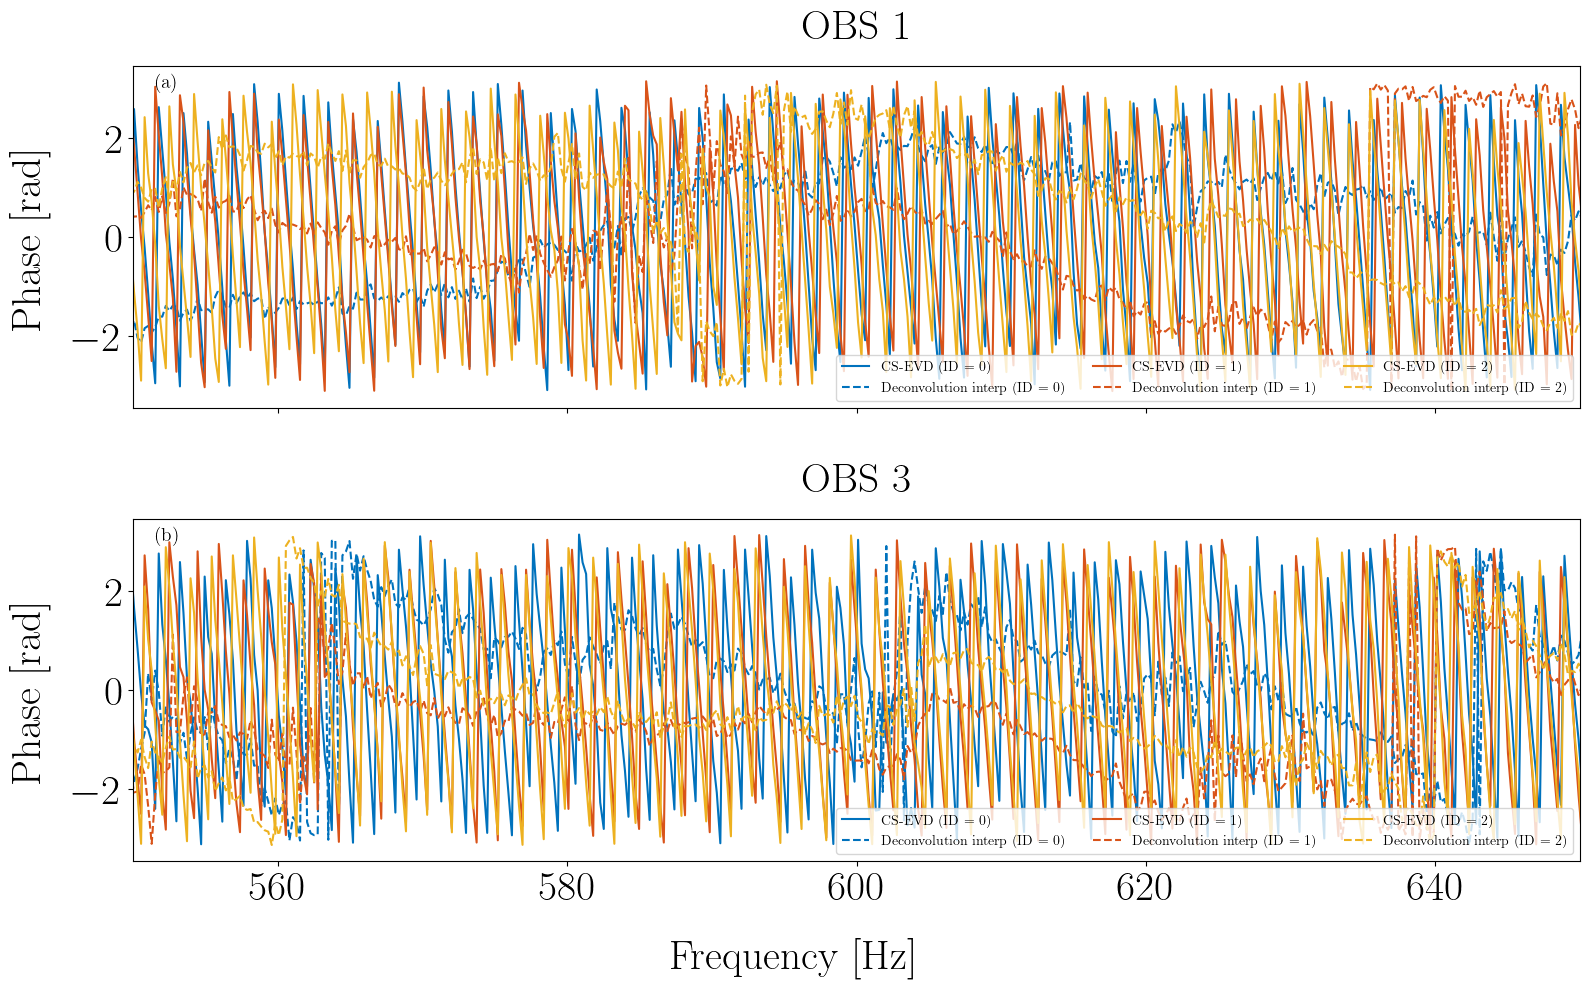

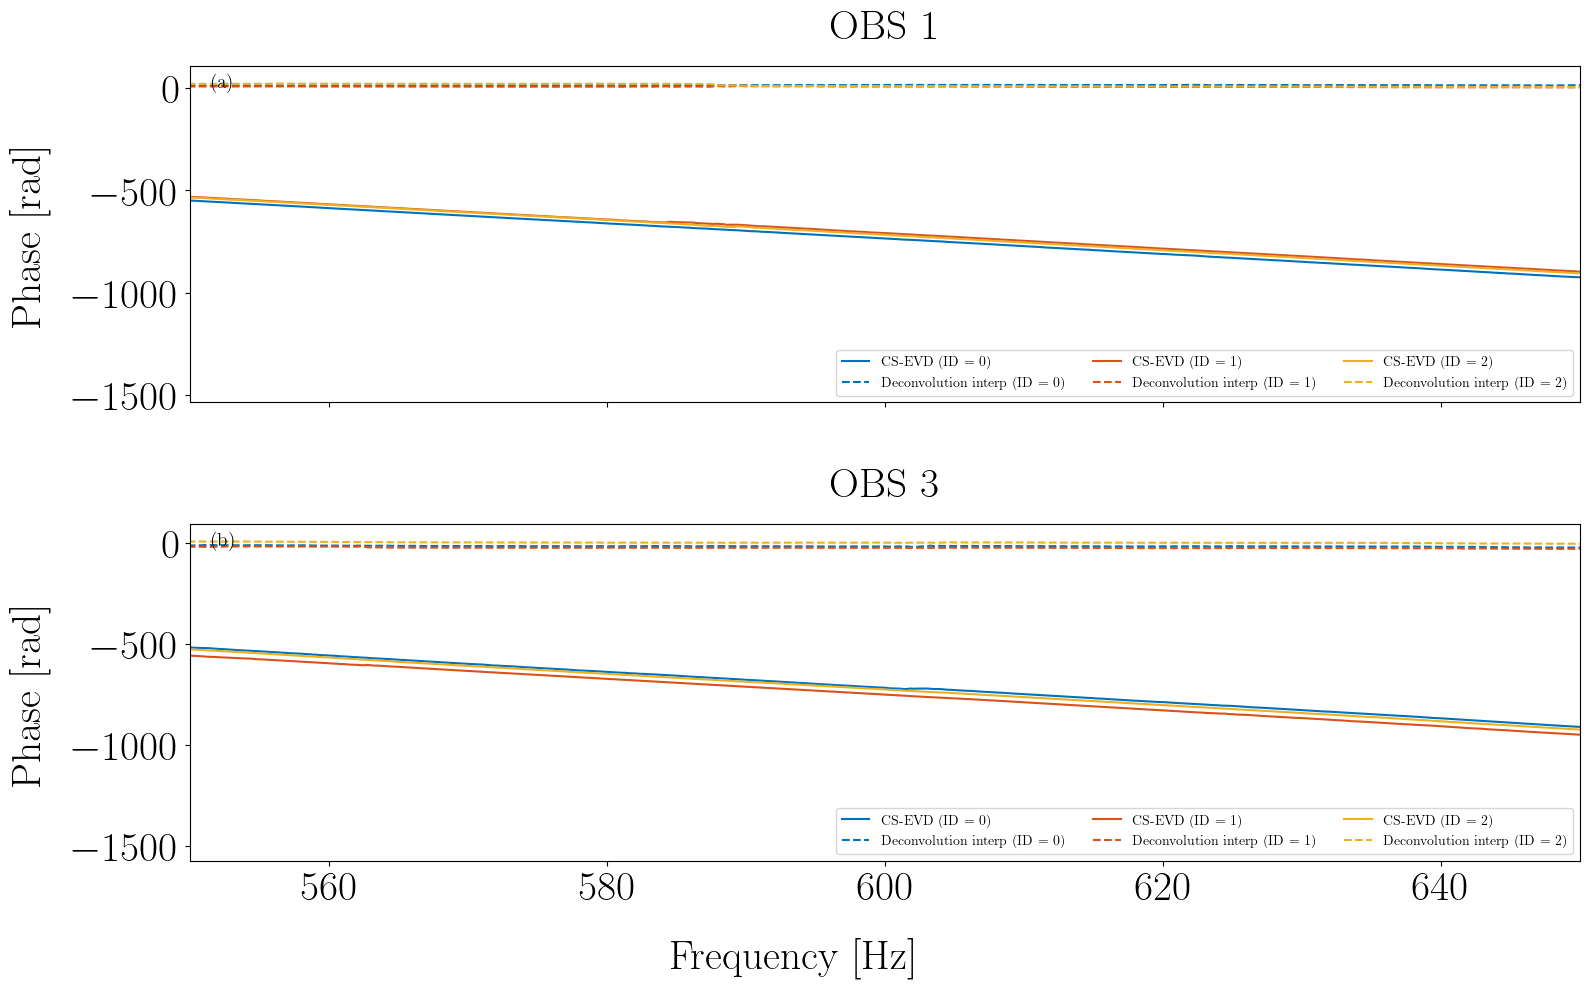

In [34]:
fmin_plot = 550
f_max_plot = 650

# Wrapped phase
fig, ax_phase_wrapped = plt.subplots(
    nrows=len(idx_rcv_plot), ncols=1, sharex=True, sharey="row", figsize=(16, 10)
)
i_ax = 0

for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))
    h_plot = i_rcv + 1

    for i, i_pulse in enumerate(rep_selection):
        ax_phase_wrapped[i_ax].plot(
            freq,
            np.angle(rtf_cs_evd[i_rcv, :, i_pulse]),
            label=f"CS-EVD (ID = {i_pulse})",
            color=color(i),
        )
        ax_phase_wrapped[i_ax].plot(
            freq,
            np.angle(rtf_deconvolution_interp[i_rcv, :, i_pulse]),
            label=f"Deconvolution interp (ID = {i_pulse})",
            color=color(i),
            linestyle="--",
        )

    ax_phase_wrapped[i_ax].set_title(f"OBS {h_plot}")
    ax_phase_wrapped[i_ax].set_xlabel("")
    ax_phase_wrapped[i_ax].set_ylabel(r"Phase [rad]")
    ax_phase_wrapped[i_ax].legend(fontsize=10, ncol=3, loc="lower right")

    i_ax += 1

set_subfigures_abc_labels(
    axs=ax_phase_wrapped, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")
plt.xlim([fmin_plot, f_max_plot])

fpath = os.path.join(fig_folder, "rtf_phase_at_identified_pos.png")
plt.savefig(fpath)


# Unwrapped phase
fig, ax_phase = plt.subplots(
    nrows=len(idx_rcv_plot), ncols=1, sharex=True, sharey="row", figsize=(16, 10)
)
i_ax = 0

for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))

    h_plot = i_rcv + 1

    for i, i_pulse in enumerate(rep_selection):

        ax_phase[i_ax].plot(
            freq,
            np.unwrap(np.angle(rtf_cs_evd[i_rcv, :, i_pulse])),
            label=f"CS-EVD (ID = {i_pulse})",
            color=color(i),
        )
        ax_phase[i_ax].plot(
            freq,
            np.unwrap(np.angle(rtf_deconvolution_interp[i_rcv, :, i_pulse])),
            label=f"Deconvolution interp (ID = {i_pulse})",
            color=color(i),
            linestyle="--",
        )

    ax_phase[i_ax].set_title(f"OBS {h_plot}")
    ax_phase[i_ax].set_xlabel("")
    ax_phase[i_ax].set_ylabel(r"Phase [rad]")
    ax_phase[i_ax].legend(fontsize=10, ncol=3, loc="lower right")

    i_ax += 1 

set_subfigures_abc_labels(
    axs=ax_phase, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")
plt.xlim([fmin_plot, f_max_plot])

fpath = os.path.join(fig_folder, "rtf_unwrapped_phase_at_identified_pos.png")
plt.savefig(fpath)

0.046440206
0.05313228
0.057260286
0.05773078
0.05988991
0.04871851


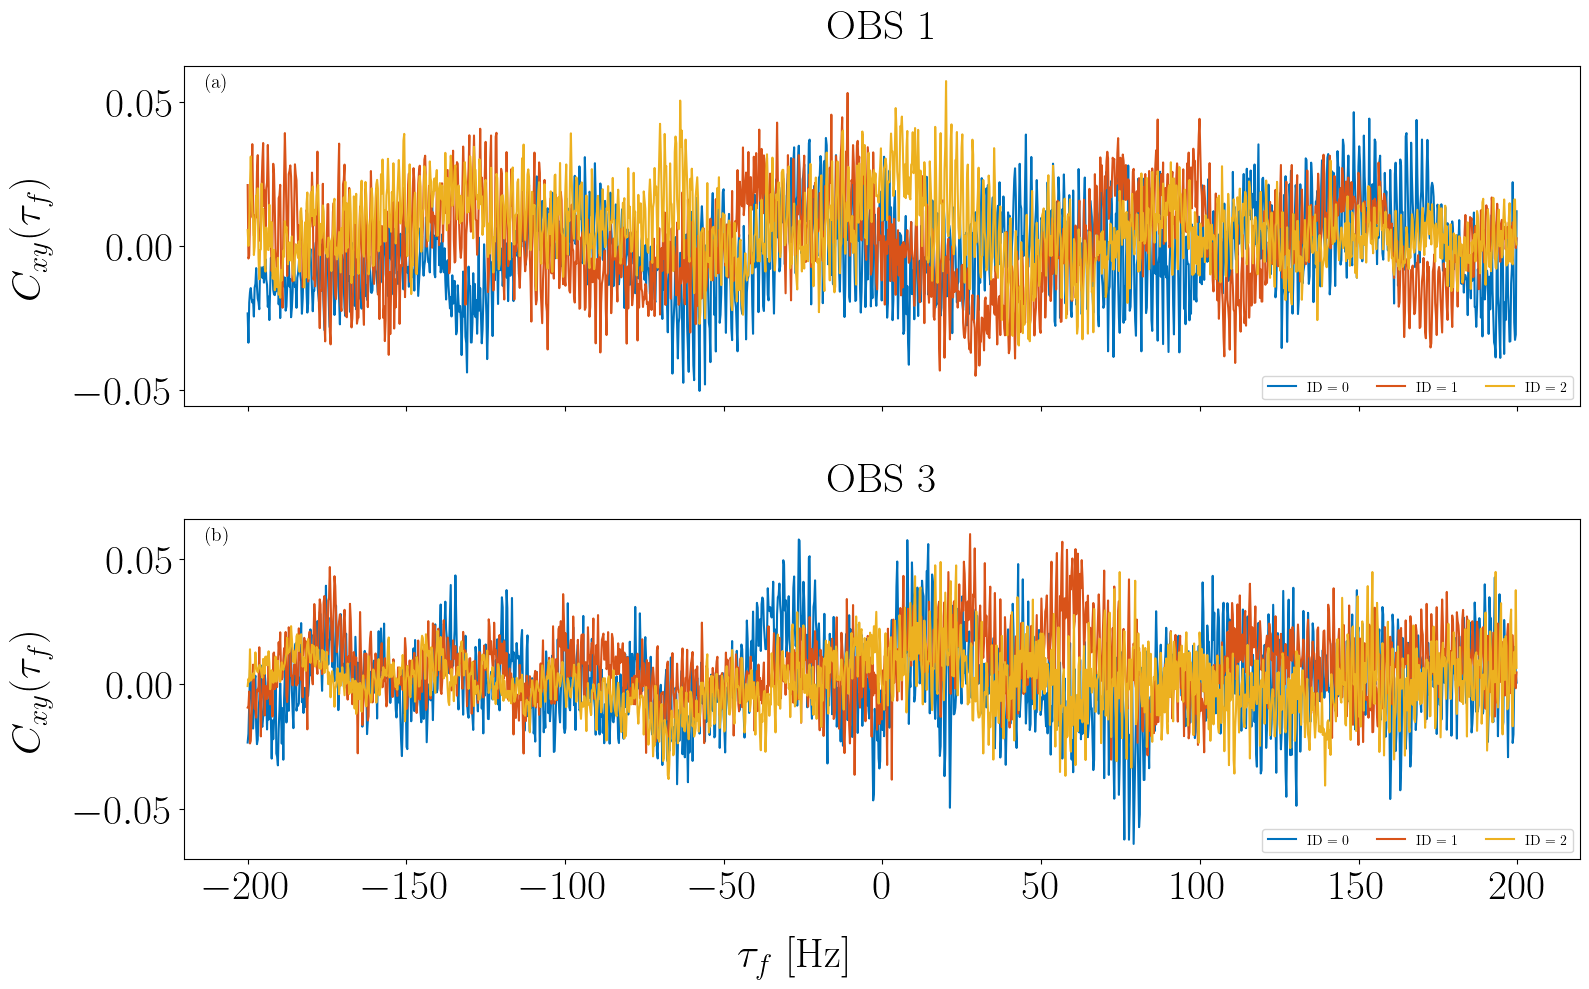

In [35]:
fig, ax_phase = plt.subplots(
    nrows=len(idx_rcv_plot), ncols=1, sharex=True, sharey="row", figsize=(16, 10)
)
i_ax = 0

# Intercorrélation des "signaux" de phase
for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))
    h_plot = i_rcv + 1

    for i, i_pulse in enumerate(rep_selection):

        # Calcul de l'intercorrélation entre les deux "signaux" de phase
        sig = np.angle(rtf_cs_evd[i_rcv, :, i_pulse])
        sig_ref = np.angle(rtf_deconvolution_interp[i_rcv, :, i_pulse])

        autocorr_sig = np.correlate(sig, sig, mode="same")
        autocorr_sig_ref = np.correlate(sig_ref, sig_ref, mode="same")

        intercorr =  np.correlate(sig, sig_ref, mode="same")
        intercorr = intercorr / np.sqrt(autocorr_sig.max() * autocorr_sig_ref.max())
        step_f = freq[1] - freq[0]
        lags_f = sp.correlation_lags(sig.size, sig_ref.size, mode="same") * step_f

        ax_phase[i_ax].plot(
            lags_f,
            intercorr,
            label=f"ID = {i_pulse}",
            color=color(i),
        )

        print(intercorr.max())

    ax_phase[i_ax].set_title(f"OBS {h_plot}")
    ax_phase[i_ax].set_xlabel("")
    ax_phase[i_ax].set_ylabel(r"$C_{xy}(\tau_f)$")
    ax_phase[i_ax].legend(fontsize=10, ncol=3, loc="lower right")

    i_ax += 1 

set_subfigures_abc_labels(
    axs=ax_phase, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel(r"$\tau_f$ [Hz]")

fpath = os.path.join(fig_folder, "rtf_phase_intercorr_at_identified_pos.png")
plt.savefig(fpath)
# plt.xlim([fmin_plot, f_max_plot])

## Variations du module autour d'une réplique 

(400.0, 800.0)

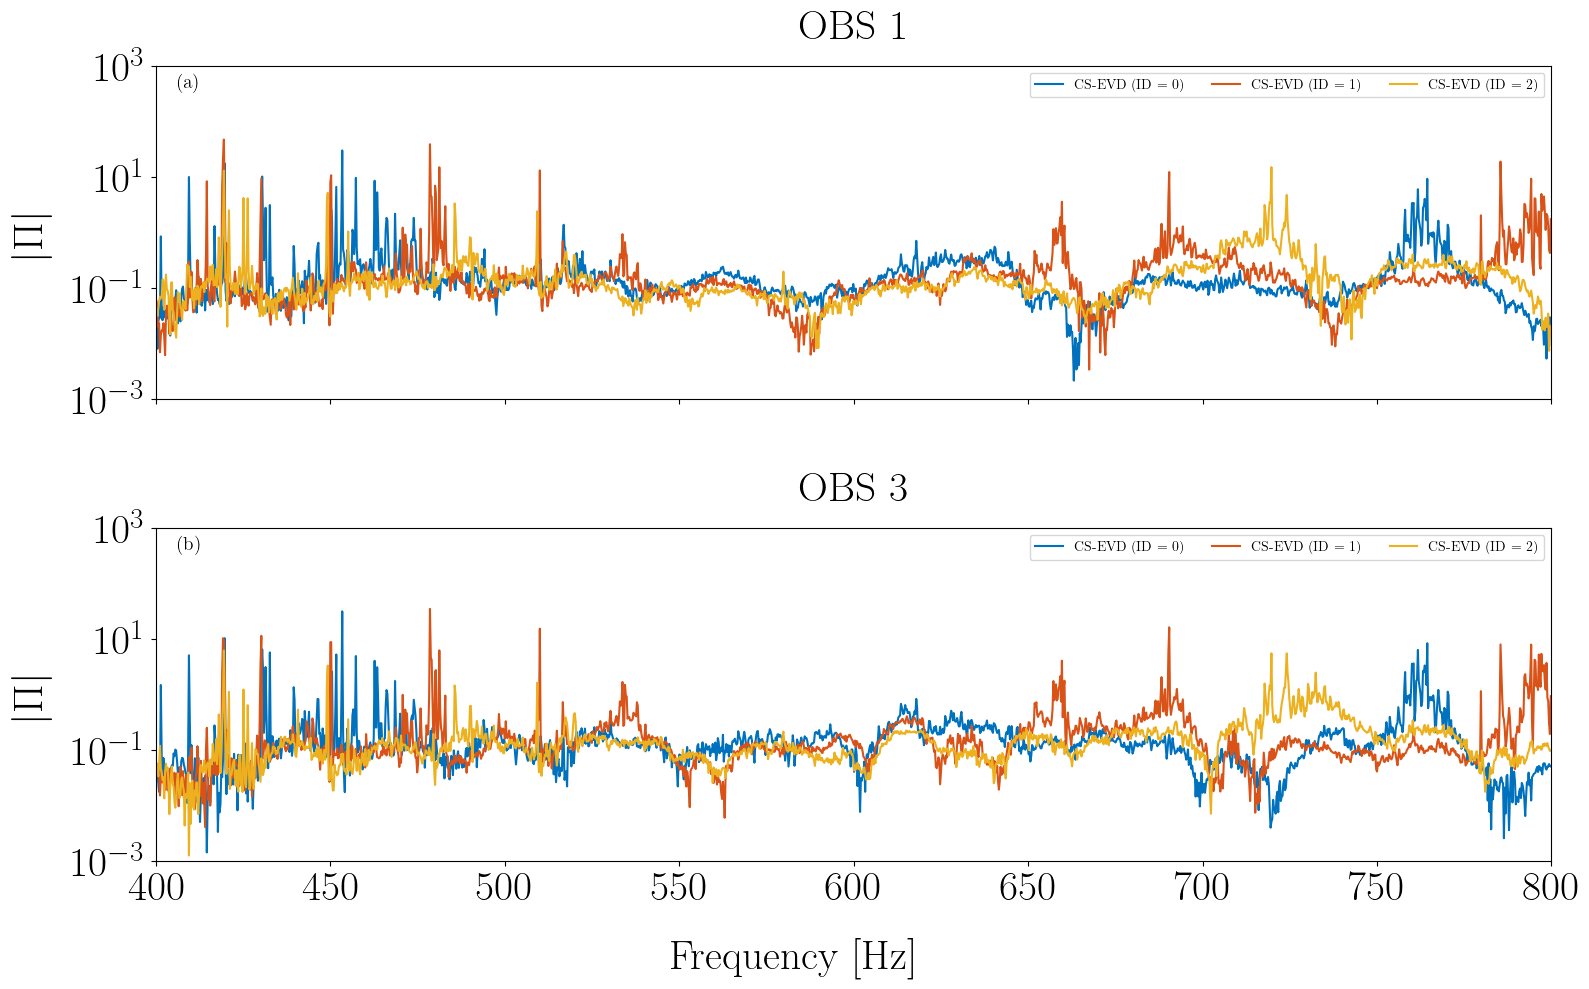

In [36]:
fmin_plot = 400
f_max_plot = 800

rep_var_selection = [0, 1, 2]
n_rcv = ds.h_index.size
idx_rcv_plot = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]

fig, ax_mod = plt.subplots(
    nrows=len(idx_rcv_plot), ncols=1, sharex=True, sharey="row", figsize=(16, 10)
)

# Module
i_ax = 0
for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))

    #
    # h_plot = i_rcv + 1
    h_plot = id_rcv

    for i, i_pulse in enumerate(rep_var_selection):

        ax_mod[i_ax].plot(
            freq,
            np.abs(rtf_cs_evd[i_rcv, :, i_pulse]),
            label=f"CS-EVD (ID = {i_pulse})",
            color=color(i),
        )
        # ax_mod[i_ax].plot(
        #     freq,
        #     np.abs(rtf_deconvolution_interp[i_rcv, :, i_pulse]),
        #     label=f"Deconvolution interp (ID = {i_pulse})",
        #     color=color(i),
        #     linestyle="--",
        # )

        ax_mod[i_ax].set_title(f"OBS {h_plot}")
        ax_mod[i_ax].set_ylim([0.001, 1000])
        ax_mod[i_ax].set_yscale("log")
        ax_mod[i_ax].set_xlabel("")
        ax_mod[i_ax].set_ylabel(r"$|\Pi|$")
        ax_mod[i_ax].legend(fontsize=10, ncol=3, loc="upper right")

    i_ax += 1

set_subfigures_abc_labels(
    axs=ax_mod, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")
plt.xlim([fmin_plot, f_max_plot])

# fpath = os.path.join(fig_folder, "rtf_module_at_identified_pos.png")
# plt.savefig(fpath)

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\xarray\computation\apply_ufunc.py:820: RuntimeWarning: invalid value encountered in log10
  result_data = func(*input_data)


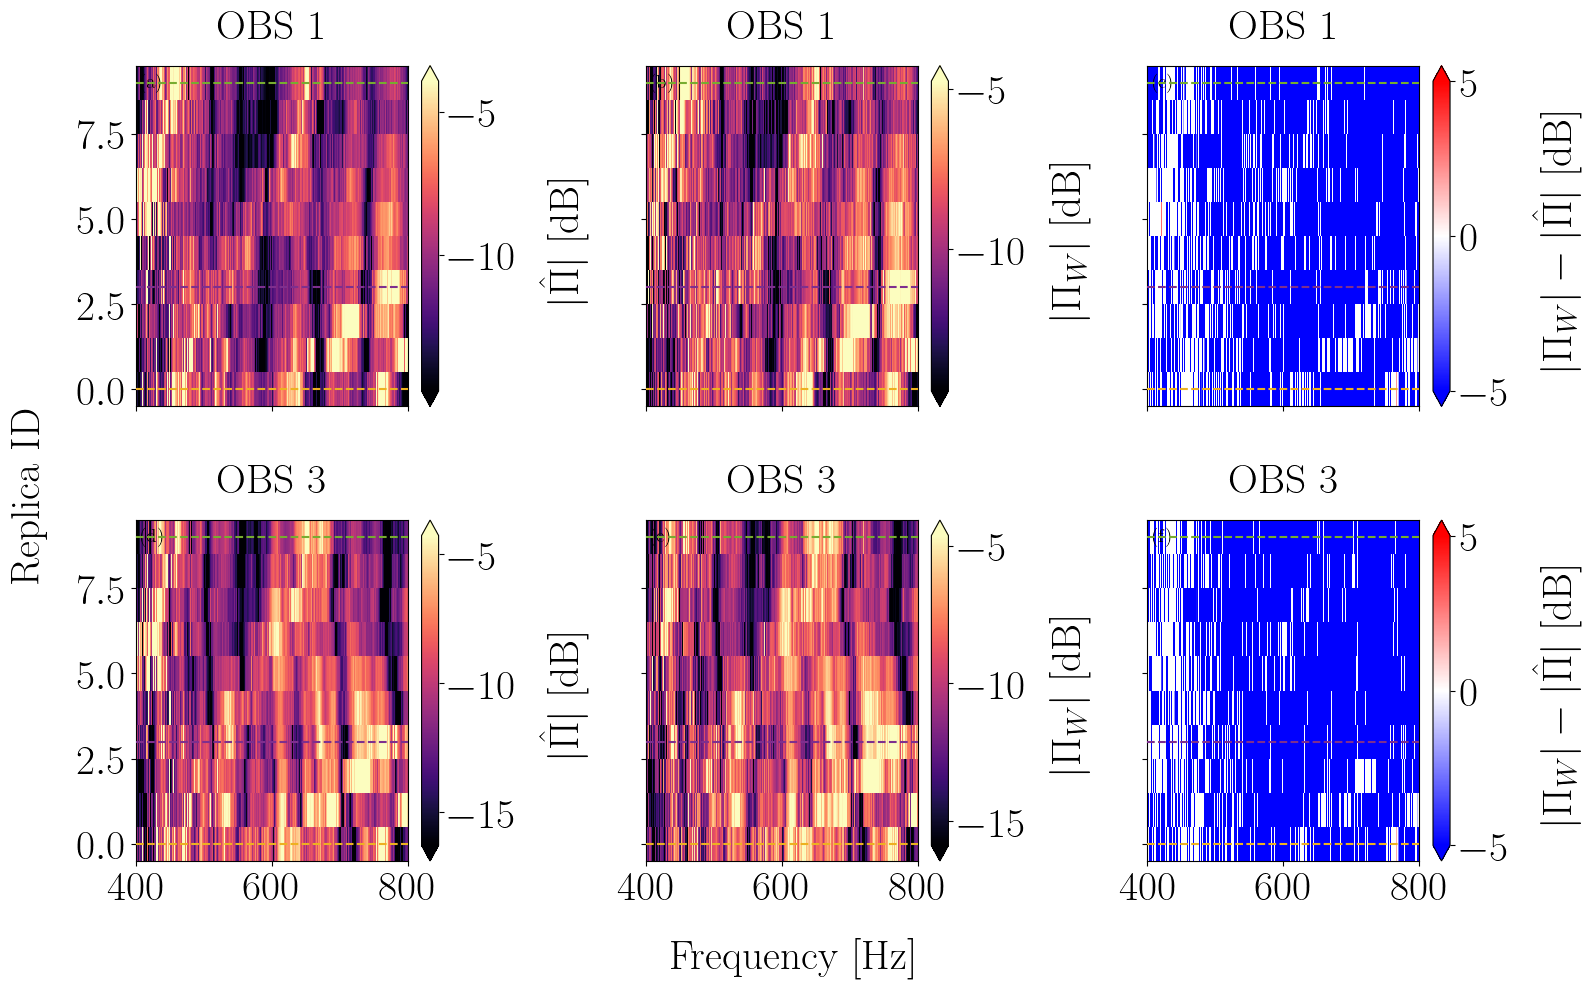

In [37]:
fmin_plot = 400
f_max_plot = 800

# rep_var_selection = [129, 130, 131, 132, 133]
n_rcv = ds.h_index.size
idx_rcv_plot = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]

fig, ax_mod = plt.subplots(
    nrows=len(idx_rcv_plot), ncols=3, sharex=True, sharey="row", figsize=(16, 10)
)

# # Proche OBS 3
# replica_id_slice = slice(0, 50)

# # Proche OBS 2
# replica_id_slice = slice(50, 100)

# Proche OBS 1
# replica_id_slice = slice(100, 150)

replica_id_slice = slice(0, 150)

# Module
i_ax = 0
for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))

    rtf_cs_evd_rcv = rtf_cs_evd.sel(h_index=id_rcv).sel(replica_id=replica_id_slice)
    log_mod = 10 * np.log10(np.abs(rtf_cs_evd_rcv))
    log_mod.plot(
        x="f_rtf",
        cmap="magma",
        ax=ax_mod[i_ax, 0],
        vmin=np.percentile(log_mod, 5),
        vmax=np.percentile(log_mod, 95),
        cbar_kwargs={"label": r"$\lvert \hat{\Pi} \rvert$ [dB]"},
    )

    rtf_deconvolution_rcv = rtf_deconvolution.sel(h_index=id_rcv).sel(
        replica_id=replica_id_slice
    )
    log_mod = 10 * np.log10(np.abs(rtf_deconvolution_rcv))
    log_mod.plot(
        x="f_deconv",
        cmap="magma",
        ax=ax_mod[i_ax, 1],
        vmin=np.percentile(log_mod, 5),
        vmax=np.percentile(log_mod, 95),
        cbar_kwargs={"label": r"$\lvert \Pi_W \rvert$ [dB]"}
    )

    rtf_deconvolution_interp_rcv = rtf_deconvolution_interp[
        i_rcv, :, replica_id_slice.start : replica_id_slice.stop +1 
    ]
    err = np.abs(rtf_deconvolution_interp_rcv) - np.abs(rtf_cs_evd_rcv)
    log_mod = 10 * np.log10(err)
    log_mod.plot(
        x="f_rtf",
        cmap="bwr",
        ax=ax_mod[i_ax, 2],
        vmax=5,
        vmin=-5,
        cbar_kwargs={"label": r"$\lvert \Pi_W \rvert - \lvert \hat{\Pi} \rvert$ [dB]"},
    )

    for i_rcv in range(dist_rcv.shape[0]):
        for k in range(ax_mod.shape[1]):
            ax_mod[i_ax, k].axhline(
                reps[obs_cpa_idx[i_rcv]],
                color=color(2 + i_rcv),
                label=f"CPA OBS{i_rcv+1}",
                linestyle="--",
                zorder=10,
            )

    for k in range(ax_mod.shape[1]):
        ax_mod[i_ax, k].set_title(f"OBS {id_rcv}")
        ax_mod[i_ax, k].set_xlabel("")
        ax_mod[i_ax, k].set_ylabel("")

    #     ax_mod[i_ax].set_ylim([0.001, 1000])
    #     ax_mod[i_ax].set_yscale("log")
    #     ax_mod[i_ax].set_xlabel("")
    #     ax_mod[i_ax].set_ylabel(r"$|\Pi|$")
    #     ax_mod[i_ax].legend(fontsize=10, ncol=3, loc="upper right")

    i_ax += 1

set_subfigures_abc_labels(
    axs=ax_mod, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")
fig.supylabel("Replica ID")

plt.xlim([fmin_plot, f_max_plot])

fpath = os.path.join(fig_folder, "rtf_module_along_traj.png")
plt.savefig(fpath)

Text(0.02, 0.5, 'Replica ID')

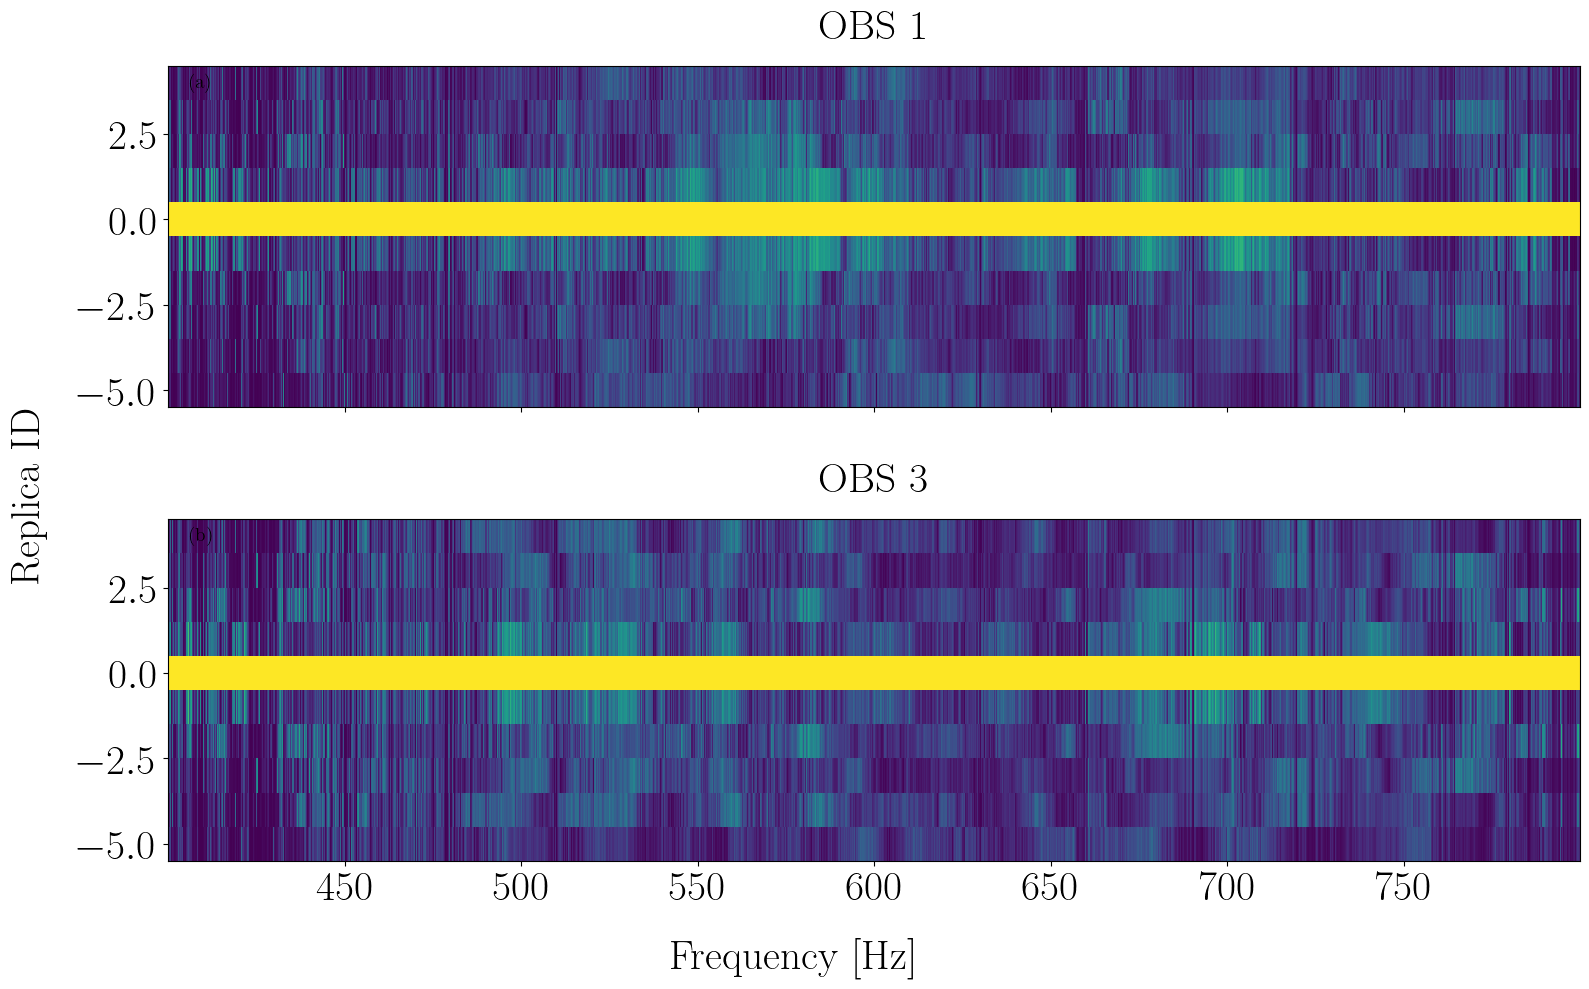

In [38]:
fmin_plot = 400
f_max_plot = 800

# rep_var_selection = [129, 130, 131, 132, 133]
n_rcv = ds.h_index.size
idx_rcv_plot = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]

fig, ax_mod = plt.subplots(
    nrows=len(idx_rcv_plot), ncols=1, sharex=True, sharey="row", figsize=(16, 10)
)

replica_id_slice = slice(0, 150)

# Module
i_ax = 0
for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))

    rtf_cs_evd_rcv = rtf_cs_evd.sel(h_index=id_rcv).sel(replica_id=replica_id_slice)

    autocorr_mat = []
    dist_autocorr = []
    f_autocorr = rtf_cs_evd.f_rtf.values
    for fi in f_autocorr:
        # rtf_mod = 10 * np.log10(np.abs(rtf_cs_evd_rcv)).sel(f_rtf=fi)

        rtf_mod = rtf_cs_evd_rcv.sel(f_rtf=fi)

        autocorr = np.correlate(rtf_mod, rtf_mod, mode="same")
        autocorr /= np.max(np.abs(autocorr))
        step_rep = ds.replica_id.values[1] - ds.replica_id.values[0]
        lags_rep = sp.correlation_lags(ds.replica_id.size, ds.replica_id.size, mode="same") * step_rep

        # # Distance d'autocorrélation
        pos_shift = lags_rep >= 0
        autocorr_pos_shift = autocorr[pos_shift]
        d_half_autocorr_idx = np.where(np.abs(autocorr_pos_shift) - 1 / 2 >= 0)[0][-1]
        d_autocorr = d_half_autocorr_idx * 2 * step_rep

        autocorr_mat.append(autocorr)
        dist_autocorr.append(d_autocorr)
        # lw = 1500 / fi
        # plt.plot(
        #     lags_r,
        #     autocorr,
        #     label=f"f = {fi:.1f} Hz, l = {lw:.1f}m, d_corr = {d_autocorr}m, l/d_corr = {lw/d_autocorr:.1f}",
        # )

    autocorr_mat = np.abs(np.array(autocorr_mat))
    ax_mod[i_ax].pcolormesh(f_autocorr, lags_rep, autocorr_mat.T)

    ax_mod[i_ax].set_title(f"OBS {id_rcv}")
    ax_mod[i_ax].set_xlabel("")
    ax_mod[i_ax].set_ylabel("")

    # ax_mod[i_ax].set_ylim([-5, 5])

    i_ax += 1

set_subfigures_abc_labels(
    axs=ax_mod, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")
fig.supylabel("Replica ID")


# fpath = os.path.join(fig_folder, "rtf_module_along_traj.png")
# plt.savefig(fpath)

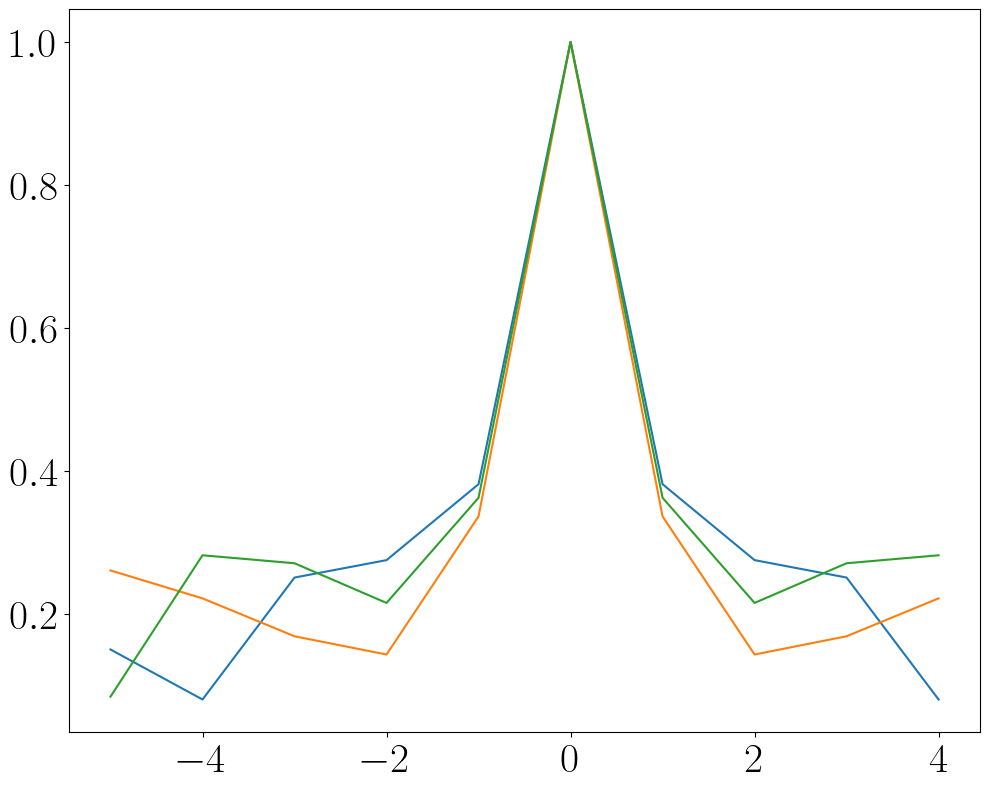

In [39]:
plt.figure()
plt.plot(lags_rep, autocorr_mat[-100, :])
plt.plot(lags_rep, autocorr_mat[-200, :])
plt.plot(lags_rep, autocorr_mat[-300, :])
# plt.xlim([-5,5])

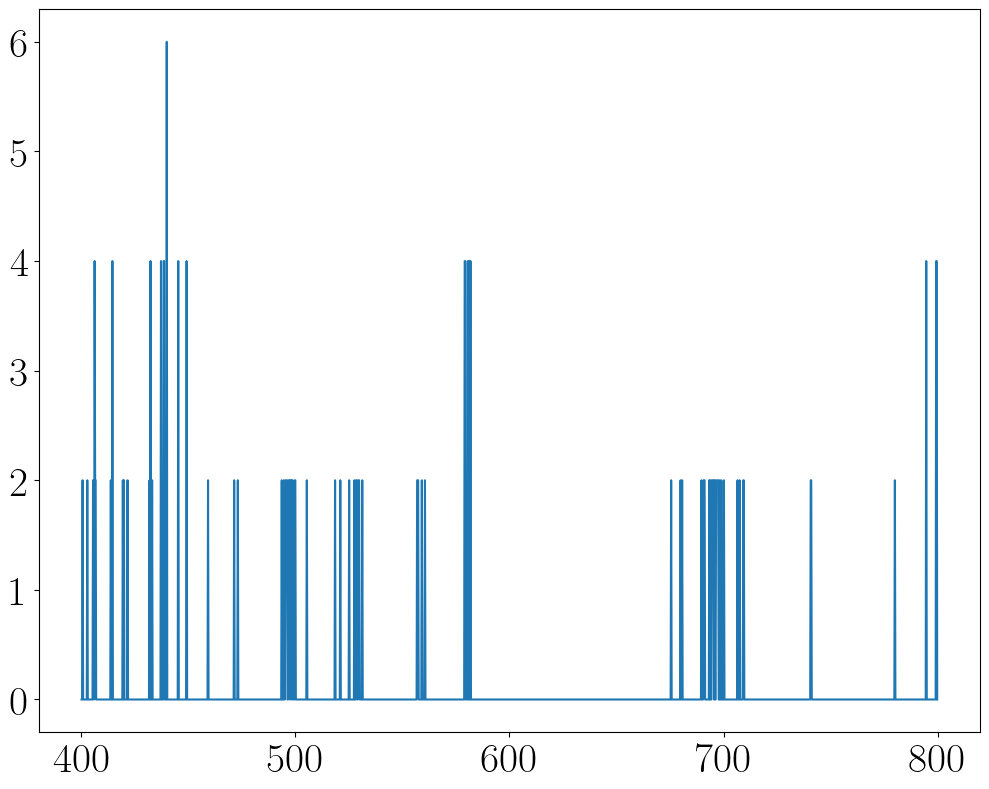

In [40]:
plt.figure()
plt.plot(f_autocorr, dist_autocorr)

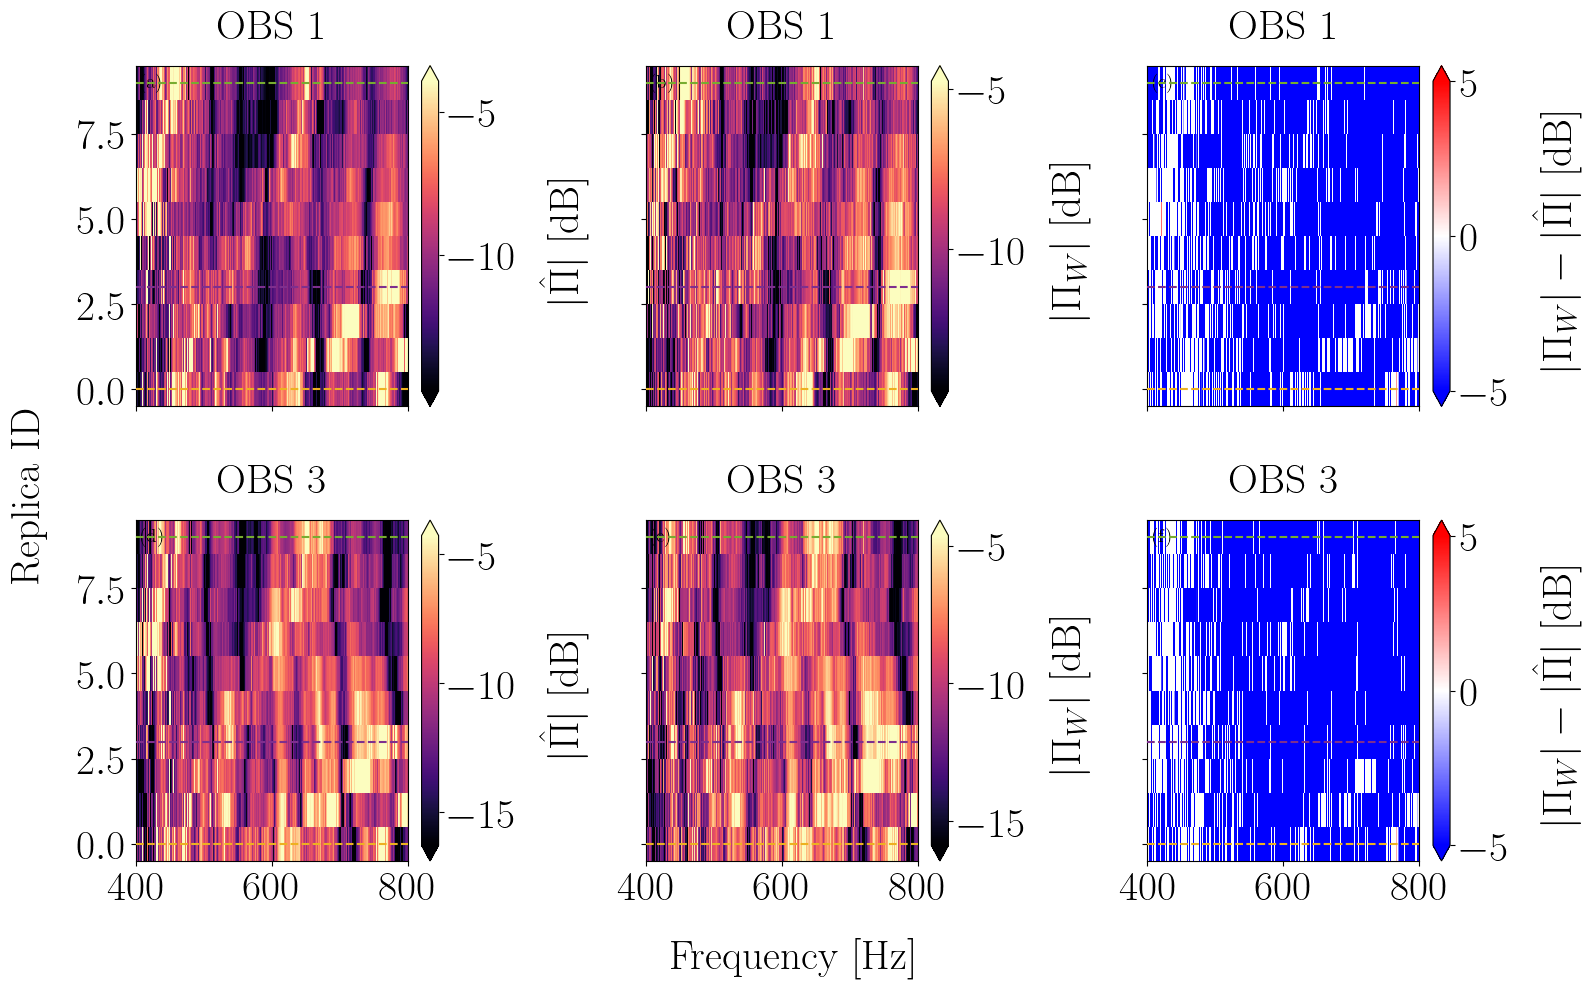

In [41]:
fmin_plot = 400
f_max_plot = 800

# rep_var_selection = [129, 130, 131, 132, 133]
n_rcv = ds.h_index.size
idx_rcv_plot = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]

fig, ax_mod = plt.subplots(
    nrows=len(idx_rcv_plot), ncols=3, sharex=True, sharey="row", figsize=(16, 10)
)

# # Proche OBS 3
replica_id_slice = slice(0, 50)

# # Proche OBS 2
# replica_id_slice = slice(50, 100)

# Proche OBS 1
# replica_id_slice = slice(100, 150)


# Module
i_ax = 0
for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))

    rtf_cs_evd_rcv = rtf_cs_evd.sel(h_index=id_rcv).sel(replica_id=replica_id_slice)
    log_mod = 10 * np.log10(np.abs(rtf_cs_evd_rcv))
    log_mod.plot(
        x="f_rtf",
        cmap="magma",
        ax=ax_mod[i_ax, 0],
        vmin=np.percentile(log_mod, 5),
        vmax=np.percentile(log_mod, 95),
        cbar_kwargs={"label": r"$\lvert \hat{\Pi} \rvert$ [dB]"},
    )

    rtf_deconvolution_rcv = rtf_deconvolution.sel(h_index=id_rcv).sel(
        replica_id=replica_id_slice
    )
    log_mod = 10 * np.log10(np.abs(rtf_deconvolution_rcv))
    log_mod.plot(
        x="f_deconv",
        cmap="magma",
        ax=ax_mod[i_ax, 1],
        vmin=np.percentile(log_mod, 5),
        vmax=np.percentile(log_mod, 95),
        cbar_kwargs={"label": r"$\lvert \Pi_W \rvert$ [dB]"}
    )

    rtf_deconvolution_interp_rcv = rtf_deconvolution_interp[
        i_rcv, :, replica_id_slice.start : replica_id_slice.stop +1 
    ]
    err = np.abs(rtf_deconvolution_interp_rcv) - np.abs(rtf_cs_evd_rcv)
    log_mod = 10 * np.log10(err)
    log_mod.plot(
        x="f_rtf",
        cmap="bwr",
        ax=ax_mod[i_ax, 2],
        vmax=5,
        vmin=-5,
        cbar_kwargs={"label": r"$\lvert \Pi_W \rvert - \lvert \hat{\Pi} \rvert$ [dB]"},
    )

    for i_rcv in range(dist_rcv.shape[0]):
        for k in range(ax_mod.shape[1]):
            ax_mod[i_ax, k].axhline(
                reps[obs_cpa_idx[i_rcv]],
                color=color(2 + i_rcv),
                label=f"CPA OBS{i_rcv+1}",
                linestyle="--",
                zorder=10,
            )

    for k in range(ax_mod.shape[1]):
        ax_mod[i_ax, k].set_title(f"OBS {id_rcv}")
        ax_mod[i_ax, k].set_xlabel("")
        ax_mod[i_ax, k].set_ylabel("")

    #     ax_mod[i_ax].set_ylim([0.001, 1000])
    #     ax_mod[i_ax].set_yscale("log")
    #     ax_mod[i_ax].set_xlabel("")
    #     ax_mod[i_ax].set_ylabel(r"$|\Pi|$")
    #     ax_mod[i_ax].legend(fontsize=10, ncol=3, loc="upper right")

    i_ax += 1

set_subfigures_abc_labels(
    axs=ax_mod, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")
fig.supylabel("Replica ID")

plt.xlim([fmin_plot, f_max_plot])

fpath = os.path.join(fig_folder, "rtf_module_along_traj_0_50.png")
plt.savefig(fpath)

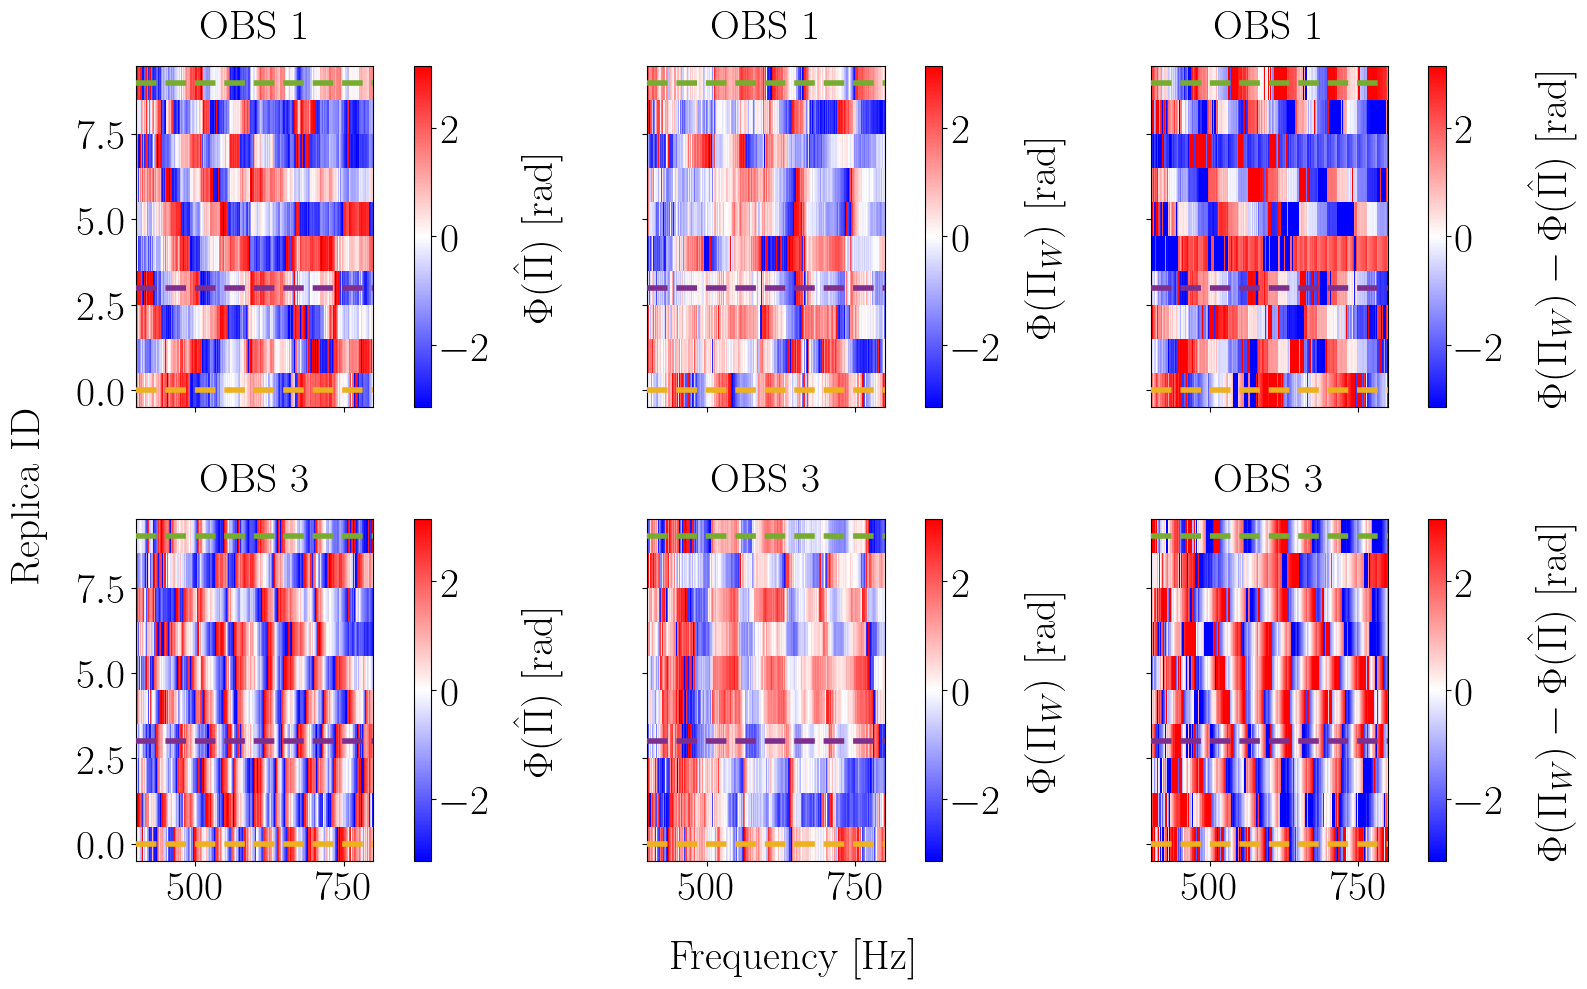

In [42]:
fmin_plot = 400
f_max_plot = 800

# rep_var_selection = [129, 130, 131, 132, 133]
n_rcv = ds.h_index.size
idx_rcv_plot = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]

fig, ax_phase = plt.subplots(
    nrows=len(idx_rcv_plot), ncols=3, sharex=True, sharey="row", figsize=(16, 10)
)

replica_id_slice = slice(0, 150)
# Module
i_ax = 0
for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))

    rtf_cs_evd_rcv = rtf_cs_evd.sel(h_index=id_rcv).sel(replica_id=replica_id_slice)
    phi_cs_evd = np.angle(rtf_cs_evd_rcv)
    im = ax_phase[i_ax, 0].pcolormesh(
        rtf_cs_evd.f_rtf.values,
        rtf_cs_evd_rcv.replica_id,
        phi_cs_evd.T,
        cmap="bwr",
        vmin=-np.pi,
        vmax=np.pi,
    )
    plt.colorbar(im, label=r"$\Phi(\hat{\Pi})$ [rad]")

    rtf_deconvolution_rcv = rtf_deconvolution.sel(h_index=id_rcv).sel(
        replica_id=replica_id_slice
    )
    phi = np.angle(rtf_deconvolution_rcv)
    im = ax_phase[i_ax, 1].pcolormesh(
        rtf_deconvolution_rcv.f_deconv.values,
        rtf_deconvolution_rcv.replica_id,
        phi.T,
        cmap="bwr",
        vmin=-np.pi,
        vmax=np.pi,
    )
    plt.colorbar(im, label=r"$\Phi(\Pi_W)$ [rad]")

    rtf_deconvolution_interp_rcv = rtf_deconvolution_interp[
        i_rcv, :, replica_id_slice.start : replica_id_slice.stop + 1
    ]
    phi_err = np.angle(rtf_deconvolution_interp_rcv) - phi_cs_evd
    im = ax_phase[i_ax, 2].pcolormesh(
        rtf_cs_evd.f_rtf.values,
        rtf_cs_evd_rcv.replica_id,
        phi_err.T,
        cmap="bwr",
        vmin=-np.pi,
        vmax=np.pi,
    )
    plt.colorbar(im, label=r"$\Phi(\Pi_W) - \Phi(\hat{\Pi})$ [rad]")

    for i_rcv in range(dist_rcv.shape[0]):
        for k in range(ax_phase.shape[1]):
            ax_phase[i_ax, k].axhline(
                reps[obs_cpa_idx[i_rcv]],
                color=color(2 + i_rcv),
                label=f"CPA OBS{i_rcv+1}",
                linestyle="--",
                linewidth=4,
                zorder=10,
            )

    for k in range(ax_phase.shape[1]):
        ax_phase[i_ax, k].set_title(f"OBS {id_rcv}")
        ax_phase[i_ax, k].set_xlabel("")
        ax_phase[i_ax, k].set_ylabel("")

    i_ax += 1

set_subfigures_abc_labels(
    axs=ax_mod, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")
fig.supylabel("Replica ID")

plt.xlim([fmin_plot, f_max_plot])

fpath = os.path.join(fig_folder, "rtf_phase_along_traj.png")
plt.savefig(fpath)

# Bootstrap avec la déconvolution 


In [43]:
def get_bootstrap_dist(ds_, test_replica_id, estimator="deconv", dist_type="hermitian_angle"):
    # Select one replica_id to compare using bootstrap
    test_replica = ds_.sel(replica_id=test_replica_id)
    # Remove from the rest of the features for bootstraping
    # bootstrap_replica = ds.drop_sel(replica_id=test_replica_id)
    bootstrap_replica = ds_

    if estimator == "deconv":
        # Test RTF
        test_replica_rtf = test_replica.rtf_amp_deconv * np.exp(
            1j * test_replica.rtf_phase_deconv
        )

        # Other RTFs
        bootstrap_replica_rtfs = bootstrap_replica.rtf_amp_deconv * np.exp(
            1j * bootstrap_replica.rtf_phase_deconv
        )
    elif estimator == "cs-evd":
        # Test RTF
        test_replica_rtf = test_replica.rtf_amp * np.exp(1j * test_replica.rtf_phase)

        # Other RTFs
        bootstrap_replica_rtfs = bootstrap_replica.rtf_amp * np.exp(
            1j * bootstrap_replica.rtf_phase
        )

    # Reshape to 4D array to be able to apply distance function : (n_rcv, n_freq, n_segment_dt) -> (n_rcv, n_freq, n_segment_dt, 1)
    bootstrap_replica_rtfs = bootstrap_replica_rtfs.values[..., np.newaxis]

    # # Compute dist
    dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": False, "apply_median": True}
    if dist_type == "hermitian_angle":
        dist = D_hermitian_angle_fast(
            rtf_ref=test_replica_rtf.values,
            rtf=bootstrap_replica_rtfs,
            **dist_kwargs,
        )

    # Distance module
    elif dist_type == "hermitian_angle_module":
        rtf_ref = np.abs(test_replica_rtf.values)
        rtf = np.abs(bootstrap_replica_rtfs)
        dist = D_hermitian_angle_fast(
            rtf_ref=rtf_ref,
            rtf=rtf,
            **dist_kwargs,
        )

    # # Compute theta along f for each rcv
    # dist_kwargs = {"ax_rcv": 1, "ax_f": 0, "apply_mean": True}
    # rtf_ref = np.abs(test_replica_rtf.values)
    # rtf = np.abs(bootstrap_replica_rtfs)
    # dist = D_hermitian_angle_fast(
    #     rtf_ref=rtf_ref,
    #     rtf=rtf,
    #     **dist_kwargs,
    # )

    # # EUCLIDEAN distance
    # d_rcv_1 = np.linalg.norm(
    #     np.abs(test_replica_rtf.sel(h_index=1).values)[:, np.newaxis]
    #     - np.abs(bootstrap_replica_rtfs[0, ...]), axis=0
    # )
    # d_rcv_2 = np.linalg.norm(
    #     np.abs(test_replica_rtf.sel(h_index=2).values)[:, np.newaxis]
    #     - np.abs(bootstrap_replica_rtfs[1, ...]),
    #     axis=0,
    # )
    # d_rcv_3 = np.linalg.norm(
    #     np.abs(test_replica_rtf.sel(h_index=3).values)[:, np.newaxis]
    #     - np.abs(bootstrap_replica_rtfs[2, ...]),
    #     axis=0,
    # )
    # dist = 1 / 3 * (d_rcv_1 + d_rcv_2 + d_rcv_3)

    # # # Compute dist
    # dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}
    # dist = D_euclidian(
    #     rtf_ref=np.abs(test_replica_rtf.isel(h_index=slice(0, 1)).values),
    #     rtf=np.abs(bootstrap_replica_rtfs[0:1, ...]),
    #     **dist_kwargs,
    # )

    # # Expand rtf_ref along the necessary axes for broadcasting
    # rtf_ref_expanded = cast_matrix_to_target_shape(rtf_ref, rtf.shape)

    # # Calculate euclidian distance
    # # d_euc = np.sqrt(np.sum(np.abs(rtf_ref_expanded - rtf) ** 2, axis=1))
    # dist = np.linalg.norm(rtf_ref_expanded - rtf, axis=1)

    return dist 

In [44]:
def get_bootstrap_dist_matrix(ds_, estimator="cs-evd", dist_type="hermitian_angle"):
    dist_mat = []
    for i, id in enumerate(ds_.replica_id.values): 
        dist_id = get_bootstrap_dist(
            ds_=ds_, test_replica_id=id, estimator=estimator, dist_type=dist_type
        )
        # dist_id = np.concatenate([dist_id[0:i], np.array([0]), dist_id[i:]])       # Add 0 on diagonal
        dist_mat.append(dist_id)

    dist_mat = np.array(dist_mat)
    return dist_mat

In [45]:
def get_dist_to_rcv(ds):
    e = ds["e_replica"].values
    n = ds["n_replica"].values

    rep_pos = np.column_stack((e, n))
    dist_to_rcv = []
    for i_rcv in ds.h_index.values:
        e_rcv = ds.attrs[f"obs{i_rcv}_e_apriori"]
        n_rcv = ds.attrs[f"obs{i_rcv}_n_apriori"]
        rcv_pos = np.column_stack((e_rcv, n_rcv))

        spatial_dist = cdist(rep_pos, rcv_pos, metric="euclidean")
        dist_to_rcv.append(spatial_dist)

    return np.array(dist_to_rcv)


In [46]:
def build_dist_matrix(ds):
    e = ds["e_replica"].values
    n = ds["n_replica"].values

    rep_pos = np.column_stack((e, n))
    spatial_dist = cdist(rep_pos, rep_pos, metric="euclidean")

    return spatial_dist

In [47]:
dist_rcv = get_dist_to_rcv(ds=ds)

Text(0.5, 0, 'Replica index')

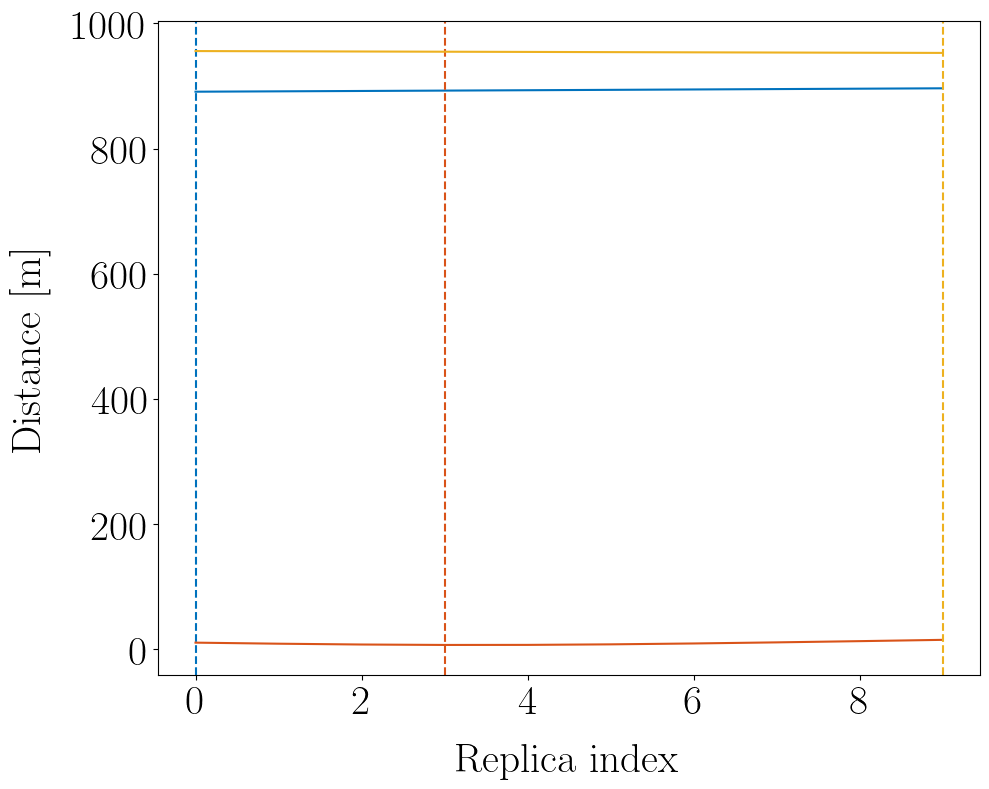

In [48]:
plt.figure()
cpa_idx = []
for i, i_rcv in enumerate(ds.h_index.values):
    plt.plot(dist_rcv[i, :], label=f"OBS{i_rcv}", color=color(i))

    cpa_rcv_idx = np.argmin(dist_rcv[i, :])
    plt.axvline(cpa_rcv_idx, linestyle="--", color=color(i))
    cpa_idx.append(cpa_rcv_idx)
    
plt.ylabel(f"Distance [m]")
plt.xlabel("Replica index")

In [49]:
spatial_dist_mat = build_dist_matrix(ds)

In [50]:
theta_mat_deconv = get_bootstrap_dist_matrix(
    ds_=ds, estimator="deconv", dist_type="hermitian_angle"
)

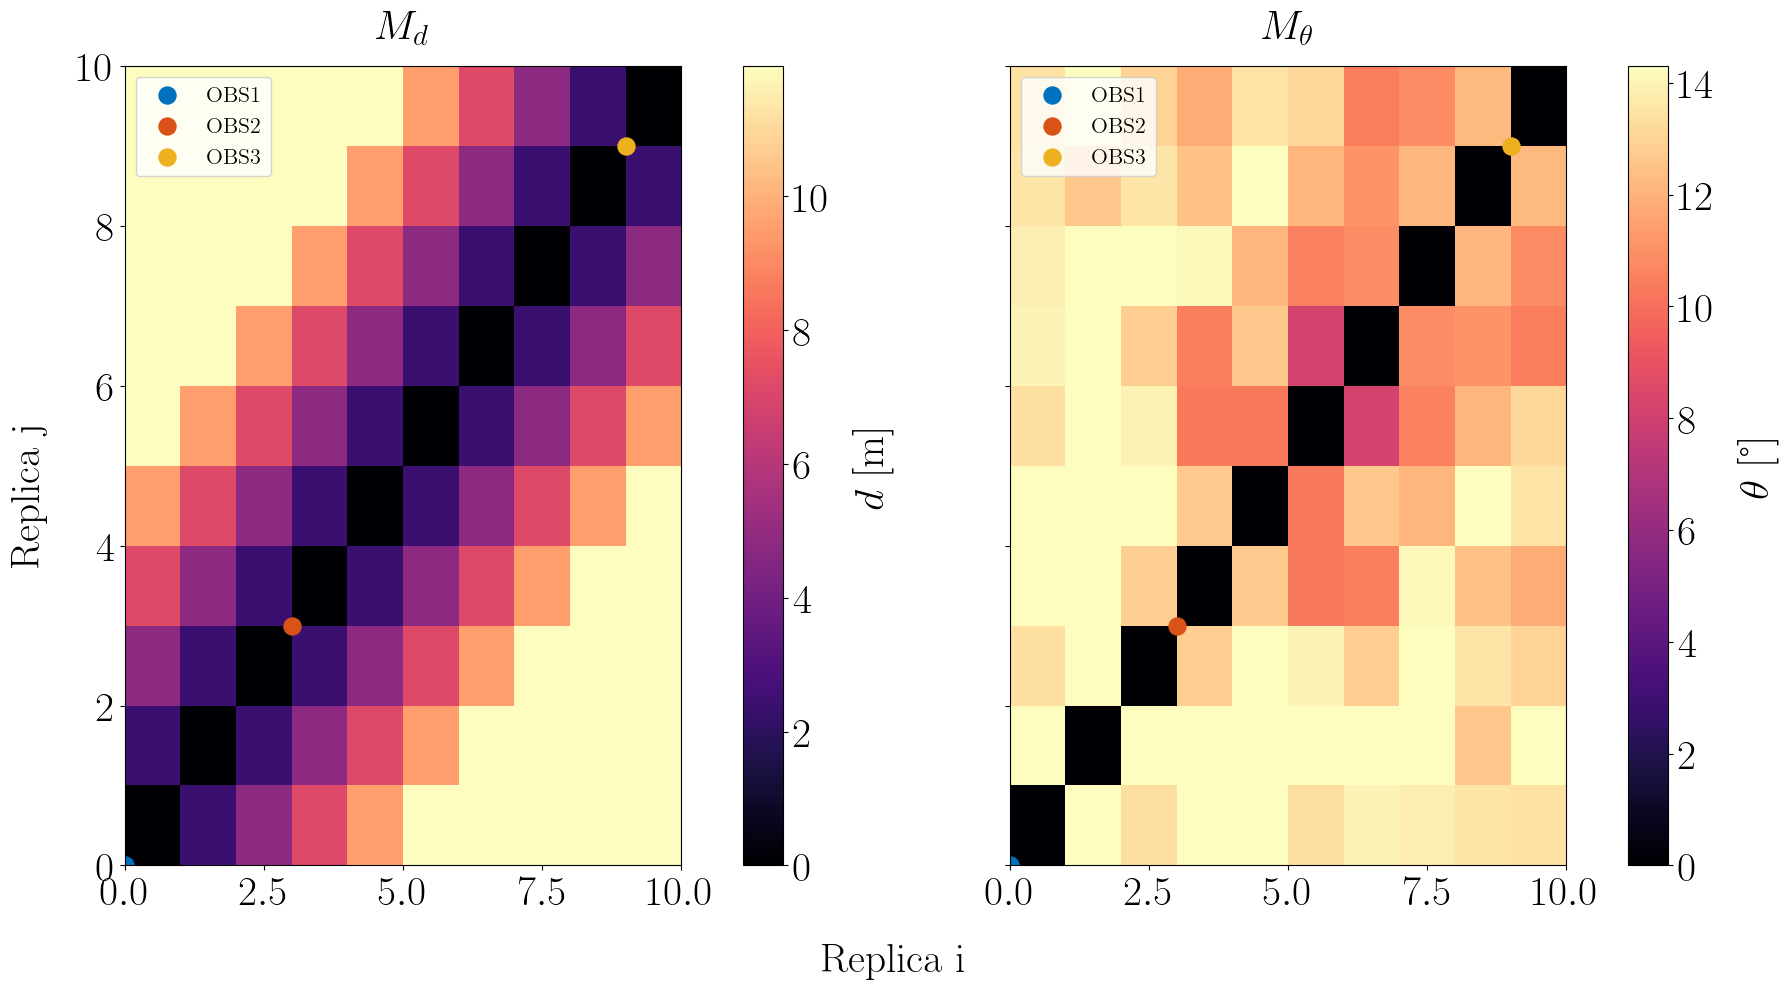

In [51]:
# plt.figure()

fig, axs = plt.subplots(
    nrows=1, ncols=2, sharey=True, figsize=(18, 10), constrained_layout=True
)
ax1, ax2 = axs

vmax = np.nanpercentile(spatial_dist_mat, 75)
im = ax1.pcolormesh(spatial_dist_mat, cmap="magma", vmax=vmax)
# ax1.colorbar(im, label=r"$d$ [m]")
fig.colorbar(im, ax=ax1, orientation="vertical", label=r"$d$ [m]")

# ax1.set_xlabel("Replica i")
# ax1.set_ylabel("Replica j")
ax1.set_title(r"$M_{d}$")


vmax = np.nanpercentile(theta_mat_deconv, 75)
im = ax2.pcolormesh(theta_mat_deconv, cmap="magma", vmax=vmax)
# ax2.colorbar(im, label=r"$\theta$ [°]")
fig.colorbar(im, ax=ax2, orientation="vertical", label=r"$\theta$ [°]")

# ax2.set_xlabel("Replica i")
# ax2.set_ylabel("Replica j")
ax2.set_title(r"$M_{\theta}$")

fig.supxlabel("Replica i")
fig.supylabel("Replica j")

# Add CPA indication
for ax in axs:
    for i, i_rcv in enumerate(ds.h_index.values):
        ax.scatter(
            cpa_idx[i],
            cpa_idx[i],
            marker="o",
            s=150,
            color=color(i),
            label=f"OBS{i_rcv}",
        )

ax1.legend()
ax2.legend()

fpath = os.path.join(
    fig_folder,
    f"bootstrap_M_theta_deconv.png",
)

plt.savefig(fpath)

In [52]:
# ds_one_rcv = ds.sel(h_index=[1, 2])

theta_mat = get_bootstrap_dist_matrix(
    ds_=ds, estimator="cs-evd", dist_type="hermitian_angle"
)

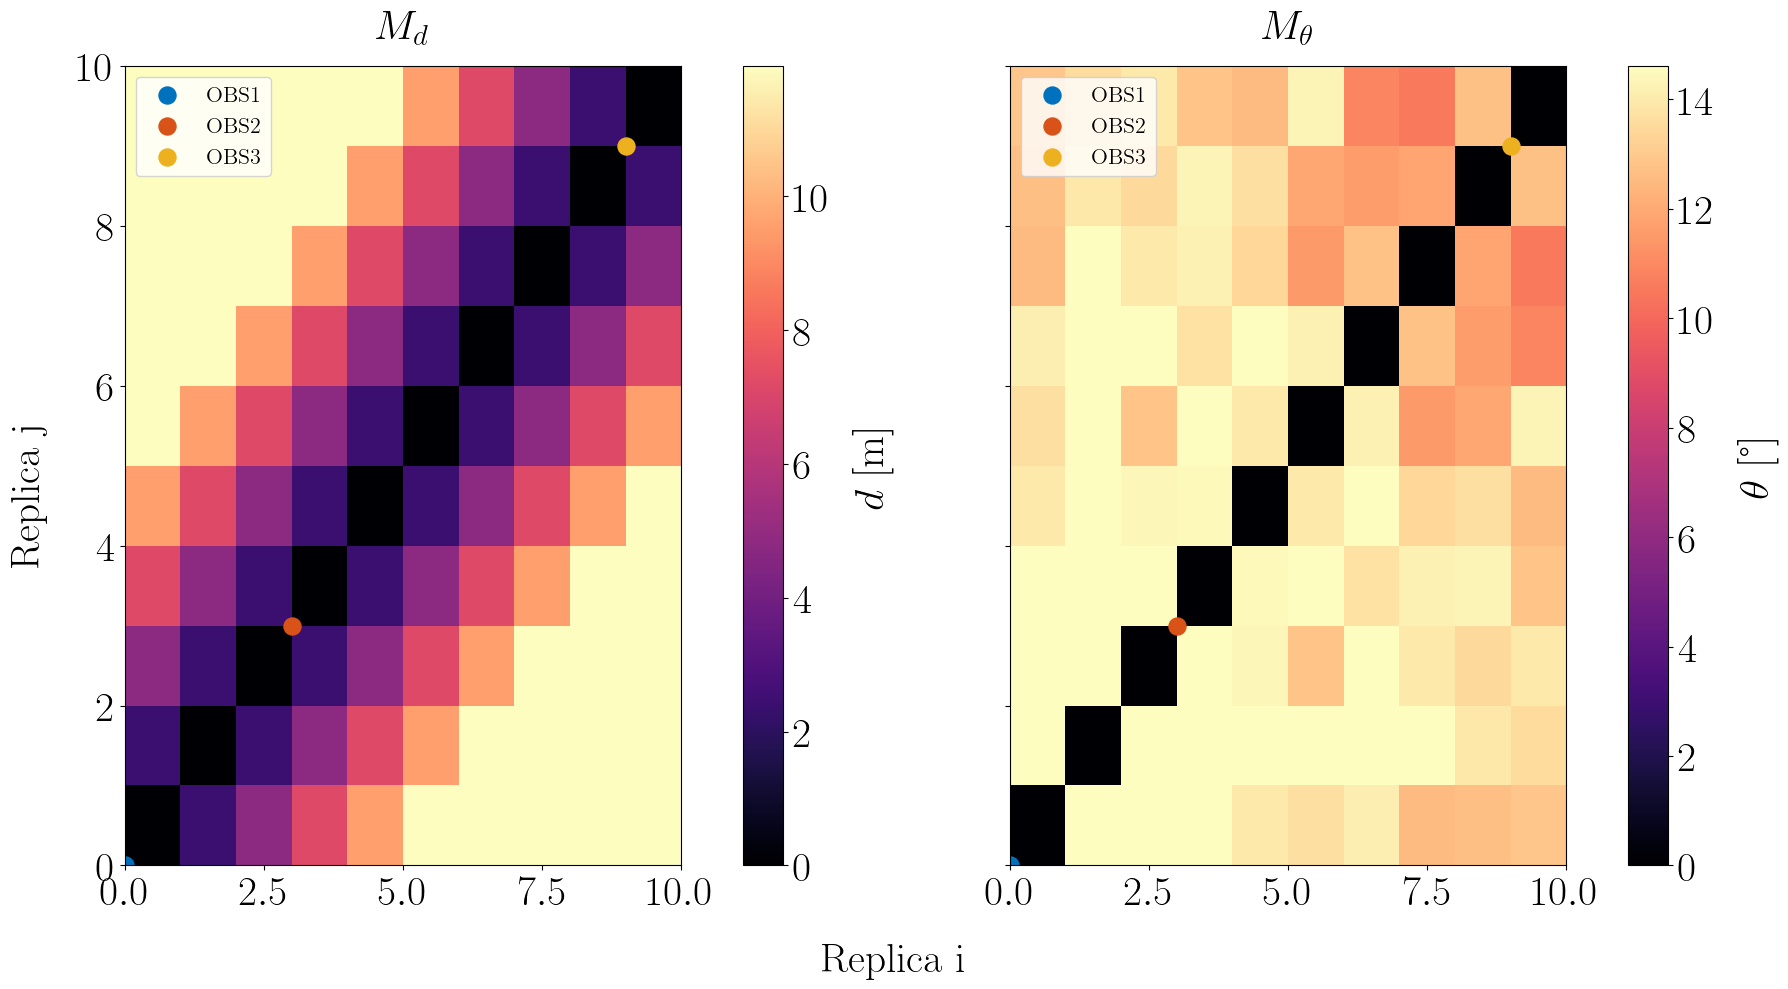

In [53]:
# plt.figure()

fig, axs = plt.subplots(
    nrows=1, ncols=2, sharey=True, figsize=(18, 10), constrained_layout=True
)
ax1, ax2 = axs

vmax = np.nanpercentile(spatial_dist_mat, 75)
im = ax1.pcolormesh(spatial_dist_mat, cmap="magma", vmax=vmax)
# ax1.colorbar(im, label=r"$d$ [m]")
fig.colorbar(im, ax=ax1, orientation='vertical', label=r"$d$ [m]")

# ax1.set_xlabel("Replica i")
# ax1.set_ylabel("Replica j")
ax1.set_title(r"$M_{d}$")


vmax = np.nanpercentile(theta_mat, 75)
im = ax2.pcolormesh(theta_mat, cmap="magma", vmax=vmax)
# ax2.colorbar(im, label=r"$\theta$ [°]")
fig.colorbar(im, ax=ax2, orientation='vertical', label=r"$\theta$ [°]")

# ax2.set_xlabel("Replica i")
# ax2.set_ylabel("Replica j")
ax2.set_title(r"$M_{\theta}$")

fig.supxlabel("Replica i")
fig.supylabel("Replica j")

# Add CPA indication
for ax in axs:
    for i, i_rcv in enumerate(ds.h_index.values):
        ax.scatter(
            cpa_idx[i], cpa_idx[i], marker="o", s=150, color=color(i), label=f"OBS{i_rcv}"
        )

ax1.legend()
ax2.legend()

fpath = os.path.join(
    fig_folder,
    f"bootstrap_M_theta.png",
)

plt.savefig(fpath)

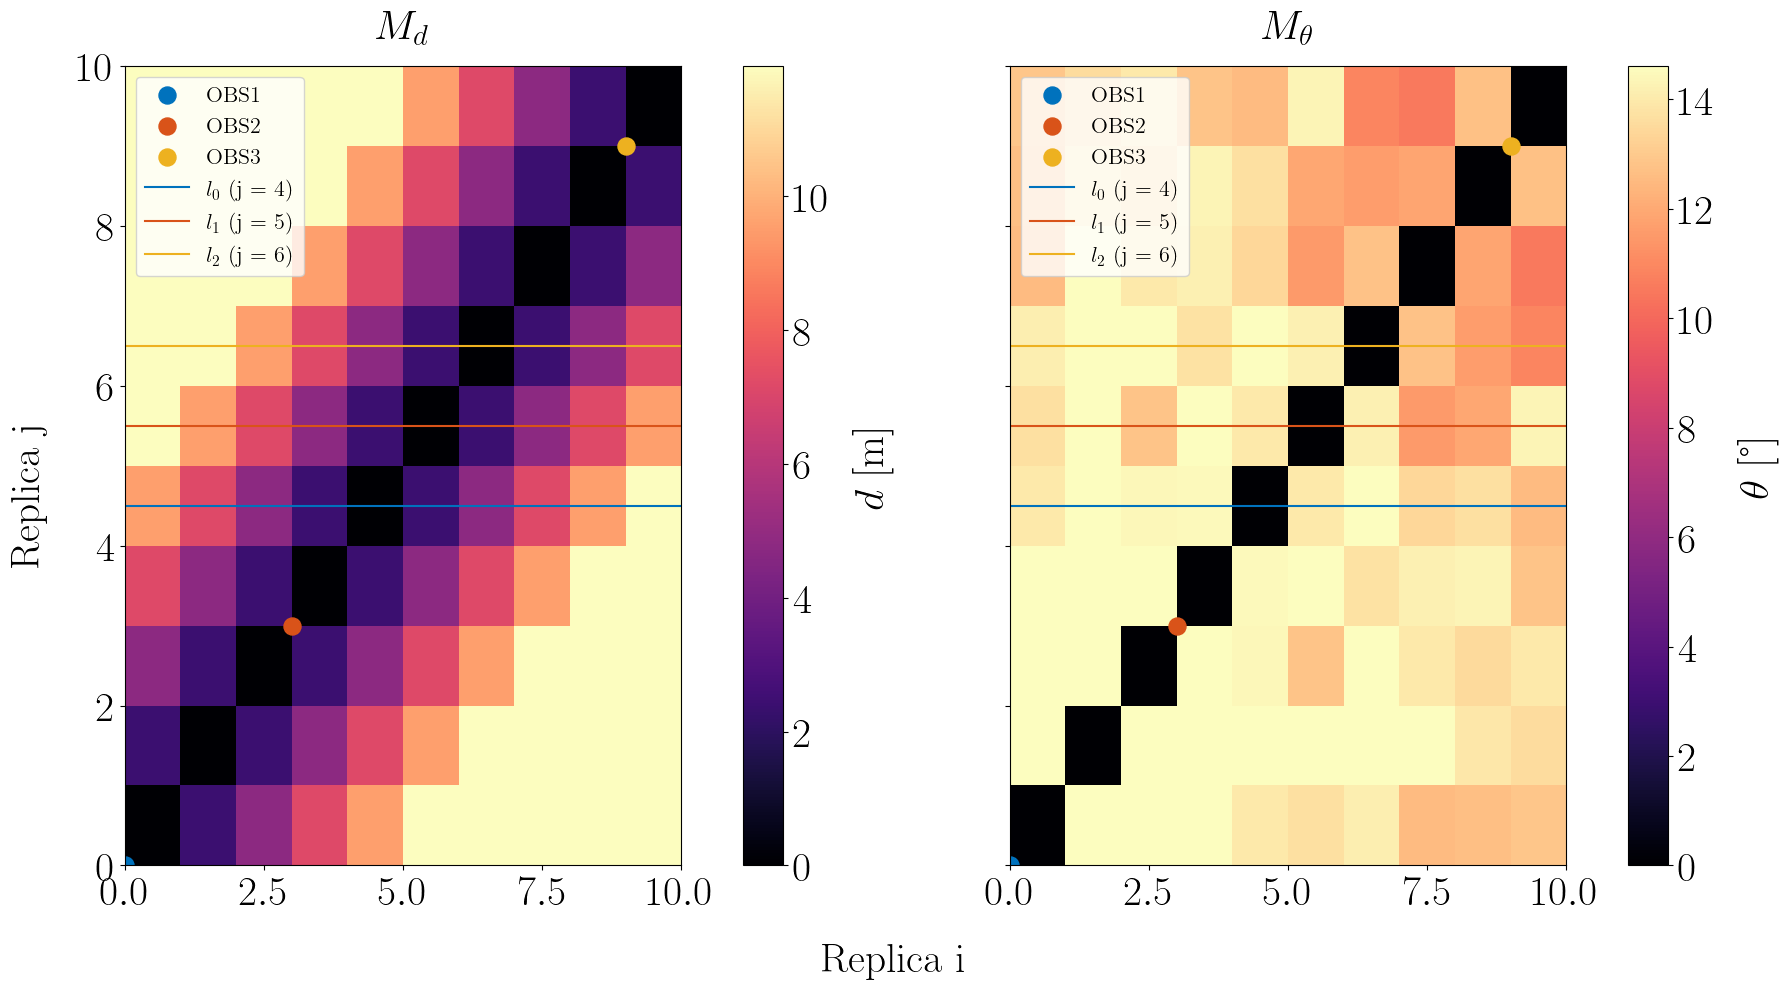

In [54]:

# Quelques lignes à la loupe
i_ls = [4, 5, 6]
fig, axs = plt.subplots(
    nrows=1, ncols=2, sharey=True, figsize=(18, 10), constrained_layout=True
)
ax1, ax2 = axs

vmax = np.nanpercentile(spatial_dist_mat, 75)
im = ax1.pcolormesh(spatial_dist_mat, cmap="magma", vmax=vmax)
fig.colorbar(im, ax=ax1, orientation="vertical", label=r"$d$ [m]")
ax1.set_title(r"$M_{d}$")


vmax = np.nanpercentile(theta_mat, 75)
im = ax2.pcolormesh(theta_mat, cmap="magma", vmax=vmax)
fig.colorbar(im, ax=ax2, orientation="vertical", label=r"$\theta$ [°]")

ax2.set_title(r"$M_{\theta}$")

fig.supxlabel("Replica i")
fig.supylabel("Replica j")

# Add CPA indication and lines 
for ax in axs:
    for i, i_rcv in enumerate(ds.h_index.values):
        ax.scatter(
            cpa_idx[i],
            cpa_idx[i],
            marker="o",
            s=150,
            color=color(i),
            label=f"OBS{i_rcv}",
        )

    for k, i_l in enumerate(i_ls):
        ax.axhline(i_l+0.5, color=color(k), label=rf"$l_{k}$ (j = {i_l})")
    
ax1.legend()
ax2.legend()

fpath = os.path.join(
    fig_folder,
    f"bootstrap_selected_lines.png",
)

plt.savefig(fpath)

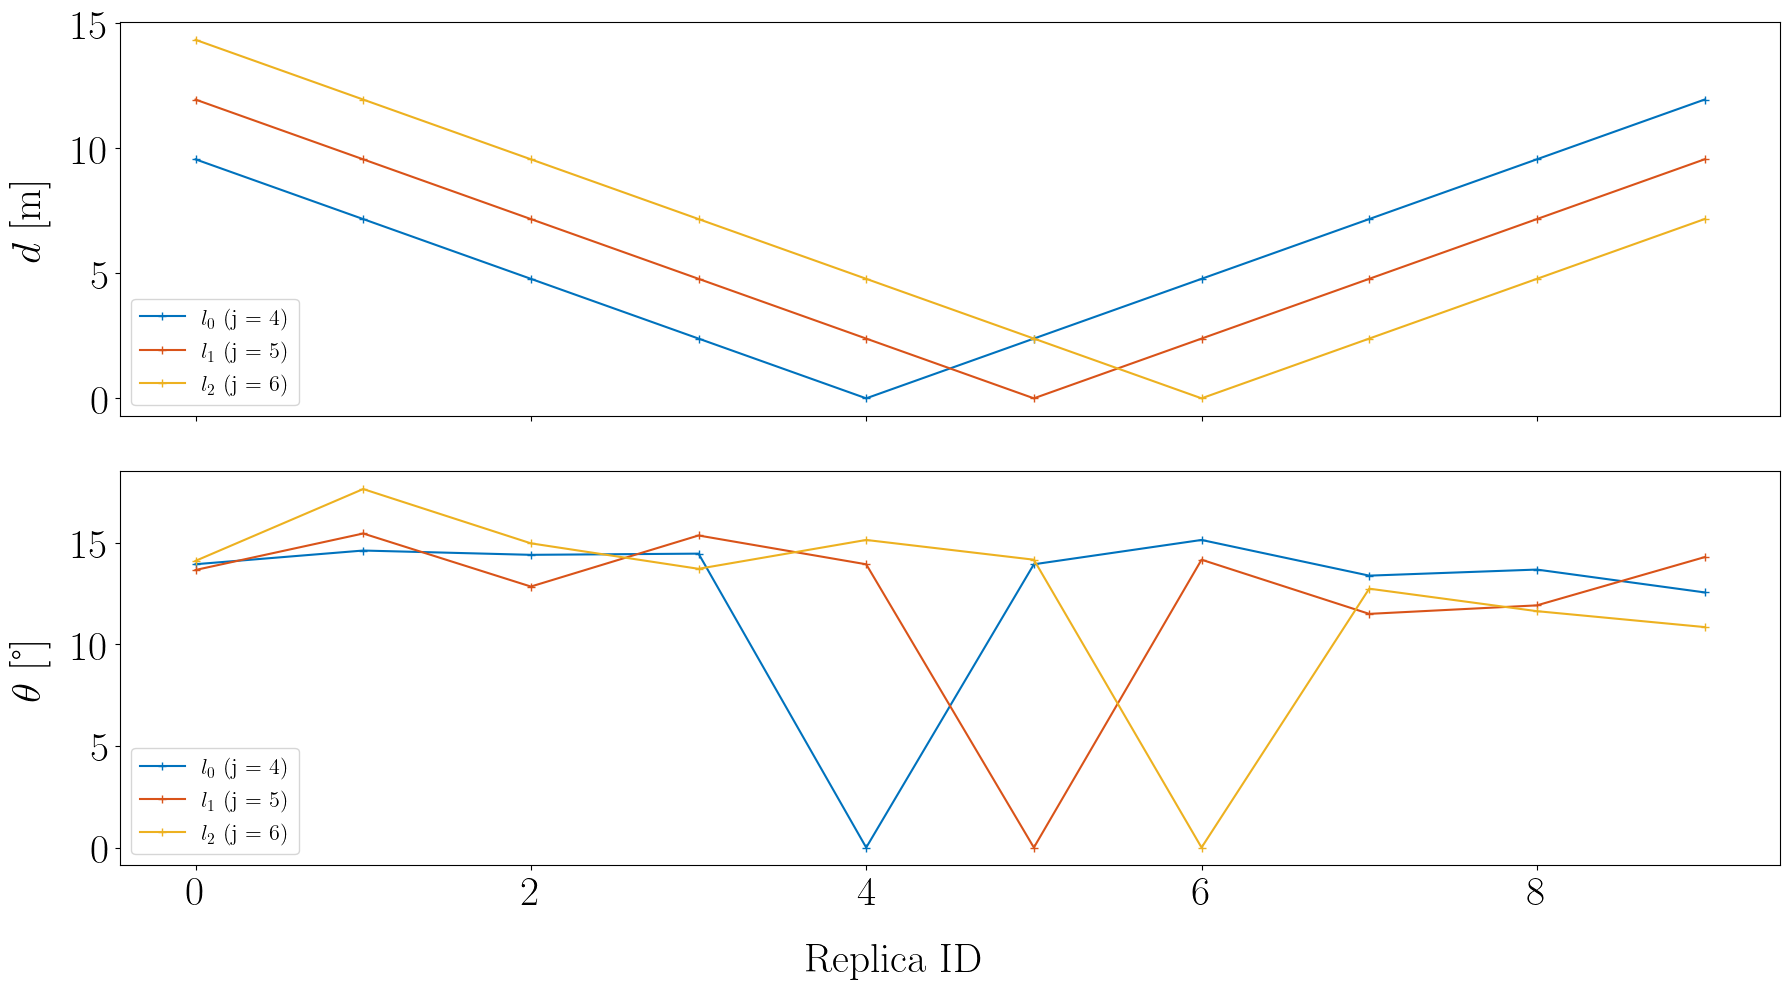

In [55]:
# plt.figure()
fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(18, 10))
ax1, ax2 = axs

for k, i_l in enumerate(i_ls):
    ax1.plot(spatial_dist_mat[i_l, :], marker="+", color=color(k), label=rf"$l_{k}$ (j = {i_l})")
    ax2.plot(theta_mat[i_l, :], marker="+", color=color(k), label=rf"$l_{k}$ (j = {i_l})")

ax1.set_ylabel(r"$d$ [m]")
ax2.set_ylabel(r"$\theta$ [°]")
ax1.legend()
ax2.legend()
fig.supxlabel("Replica ID")

fpath = os.path.join(
    fig_folder,
    f"bootstrap_selected_lines_var.png",
)

plt.savefig(fpath)

## Distance réduite au module 

In [56]:
theta_mod_mat = get_bootstrap_dist_matrix(
    ds_=ds, estimator="cs-evd", dist_type="hermitian_angle_module"
)

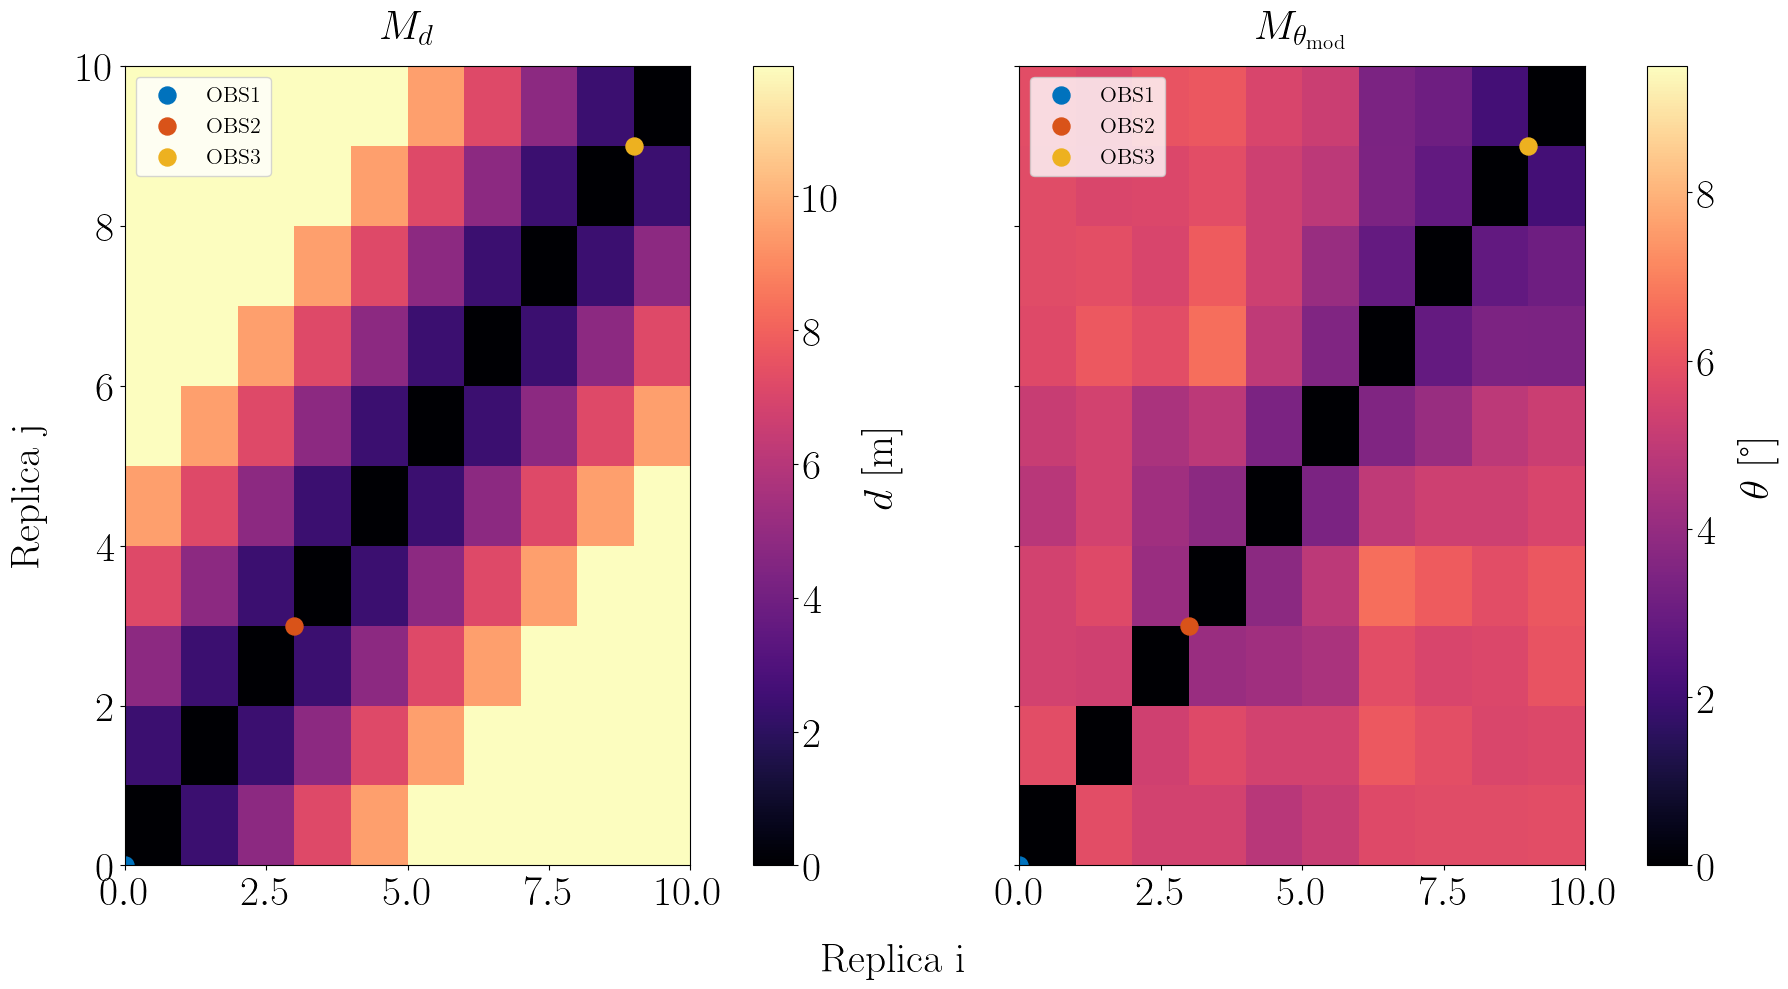

In [57]:
# plt.figure()

fig, axs = plt.subplots(
    nrows=1, ncols=2, sharey=True, figsize=(18, 10), constrained_layout=True
)
ax1, ax2 = axs

vmax = np.nanpercentile(spatial_dist_mat, 75)
im = ax1.pcolormesh(spatial_dist_mat, cmap="magma", vmax=vmax)
# ax1.colorbar(im, label=r"$d$ [m]")
fig.colorbar(im, ax=ax1, orientation='vertical', label=r"$d$ [m]")

# ax1.set_xlabel("Replica i")
# ax1.set_ylabel("Replica j")
ax1.set_title(r"$M_{d}$")


vmax = np.nanpercentile(theta_mat, 10)
im = ax2.pcolormesh(theta_mod_mat, cmap="magma", vmax=vmax)
# ax2.colorbar(im, label=r"$\theta$ [°]")
fig.colorbar(im, ax=ax2, orientation='vertical', label=r"$\theta$ [°]")

# ax2.set_xlabel("Replica i")
# ax2.set_ylabel("Replica j")
ax2.set_title(r"$M_{\theta_{\text{mod}}}$")

fig.supxlabel("Replica i")
fig.supylabel("Replica j")

# Add CPA indication
for ax in axs:
    for i, i_rcv in enumerate(ds.h_index.values):
        ax.scatter(
            cpa_idx[i], cpa_idx[i], marker="o", s=150, color=color(i), label=f"OBS{i_rcv}"
        )

ax1.legend()
ax2.legend()

fpath = os.path.join(
    fig_folder,
    f"bootstrap_M_theta_mod.png",
)

plt.savefig(fpath)

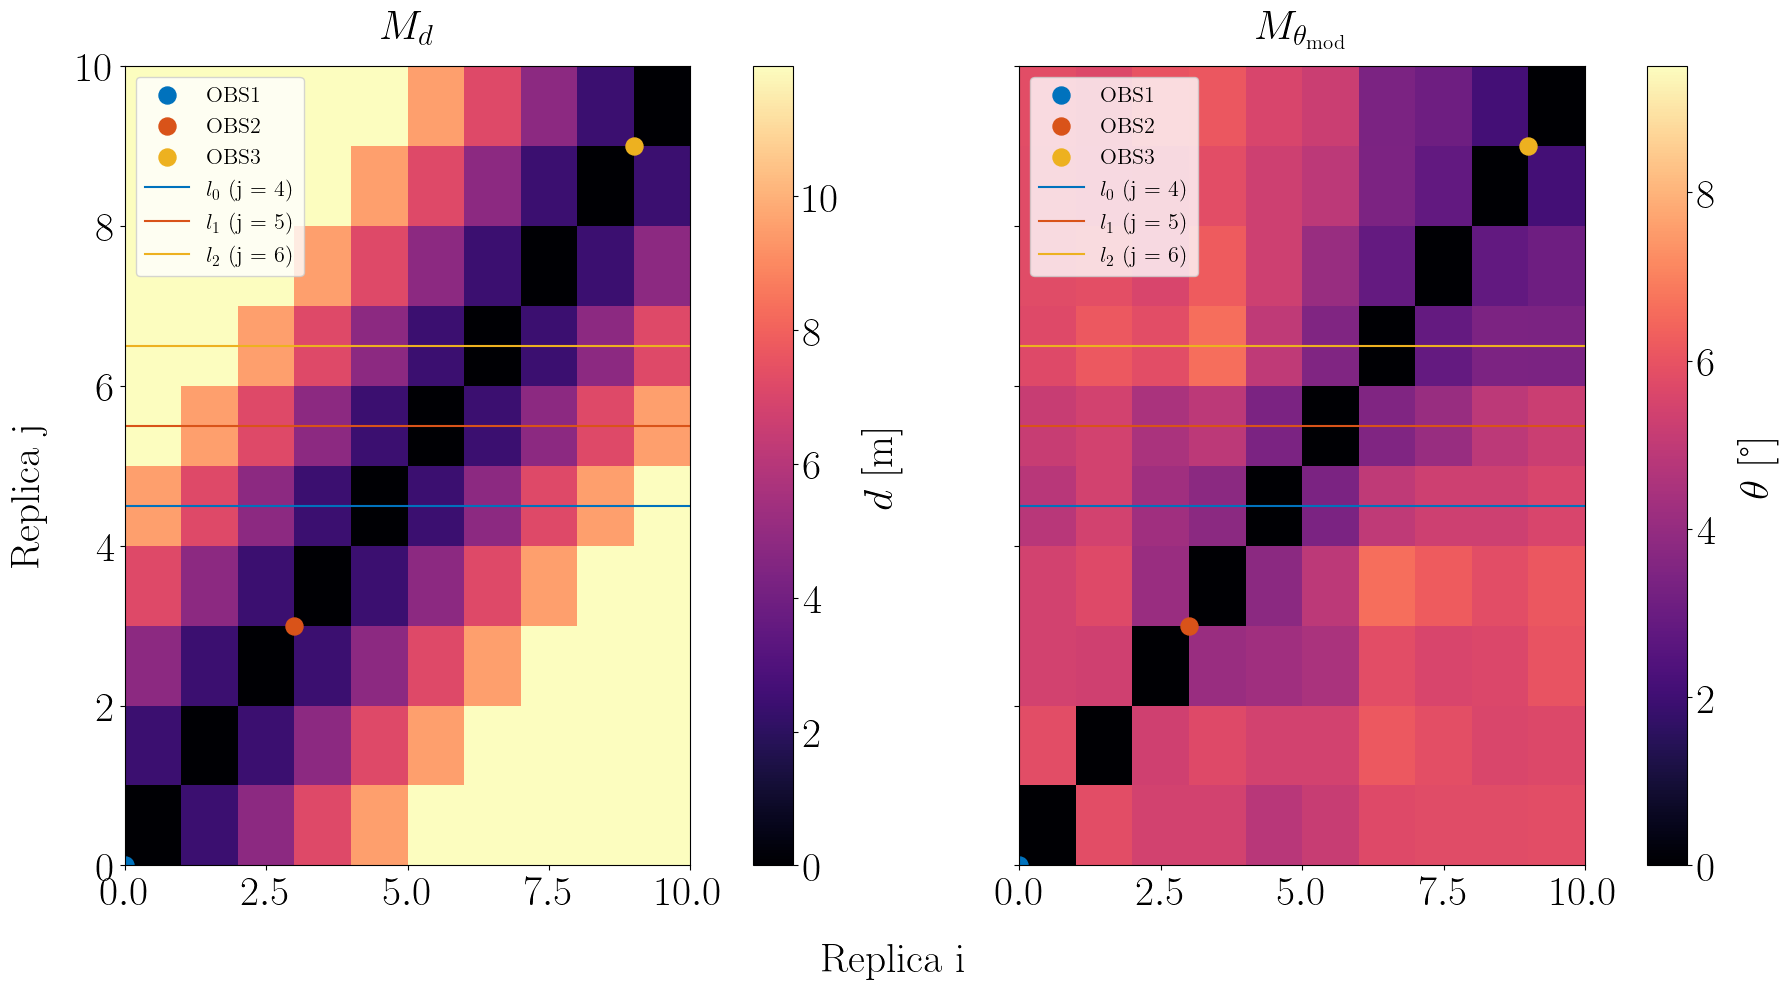

In [58]:
# Quelques lignes à la loupe
# i_ls = [65, 75, 85]
fig, axs = plt.subplots(
    nrows=1, ncols=2, sharey=True, figsize=(18, 10), constrained_layout=True
)
ax1, ax2 = axs

vmax = np.nanpercentile(spatial_dist_mat, 75)
im = ax1.pcolormesh(spatial_dist_mat, cmap="magma", vmax=vmax)
fig.colorbar(im, ax=ax1, orientation="vertical", label=r"$d$ [m]")
ax1.set_title(r"$M_{d}$")


vmax = np.nanpercentile(theta_mat, 10)
im = ax2.pcolormesh(theta_mod_mat, cmap="magma", vmax=vmax)
fig.colorbar(im, ax=ax2, orientation="vertical", label=r"$\theta$ [°]")

ax2.set_title(r"$M_{\theta_{\text{mod}}}$")

fig.supxlabel("Replica i")
fig.supylabel("Replica j")

# Add CPA indication and lines
for ax in axs:
    for i, i_rcv in enumerate(ds.h_index.values):
        ax.scatter(
            cpa_idx[i],
            cpa_idx[i],
            marker="o",
            s=150,
            color=color(i),
            label=f"OBS{i_rcv}",
        )

    for k, i_l in enumerate(i_ls):
        ax.axhline(i_l+0.5, color=color(k), label=rf"$l_{k}$ (j = {i_l})")

ax1.legend()
ax2.legend()

fpath = os.path.join(
    fig_folder,
    f"bootstrap_module_selected_lines.png",
)

plt.savefig(fpath)

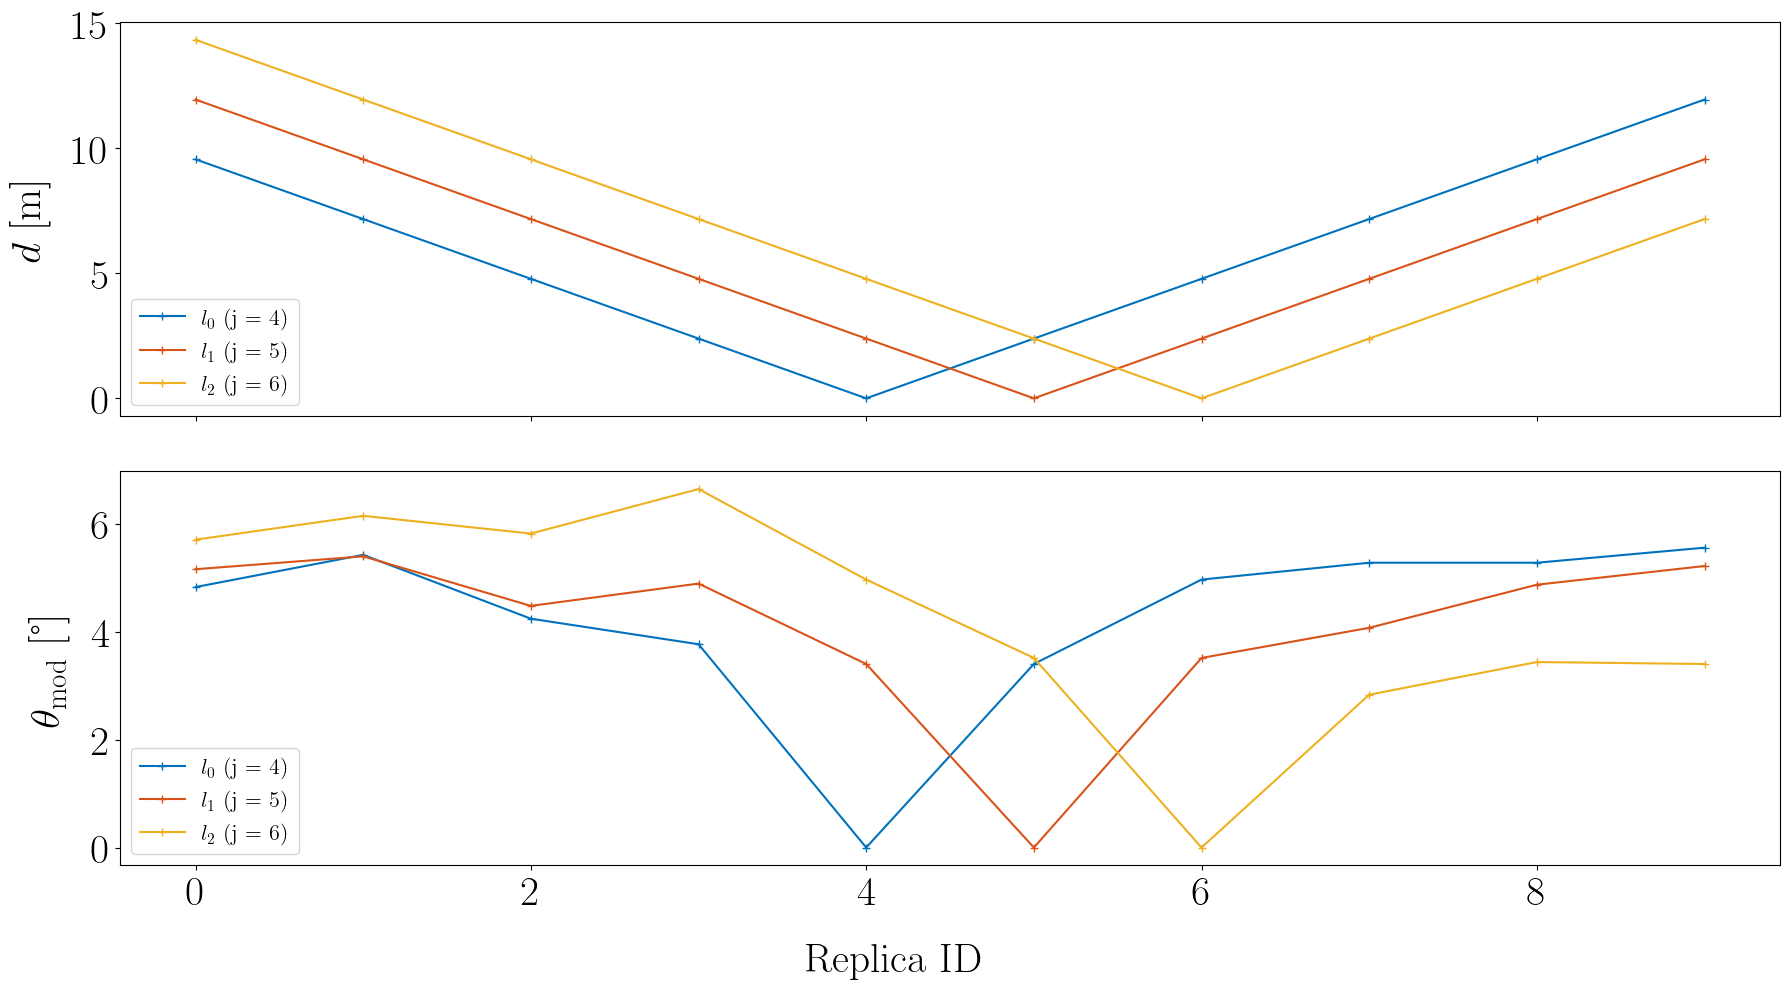

In [59]:
# plt.figure()
fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(18, 10))
ax1, ax2 = axs

for k, i_l in enumerate(i_ls):
    ax1.plot(spatial_dist_mat[i_l, :], marker="+", color=color(k), label=rf"$l_{k}$ (j = {i_l})")
    ax2.plot(
        theta_mod_mat[i_l, :], marker="+", color=color(k), label=rf"$l_{k}$ (j = {i_l})"
    )

ax1.set_ylabel(r"$d$ [m]")
ax2.set_ylabel(r"$\theta_{\text{mod}}$ [°]")
ax1.legend()
ax2.legend()
fig.supxlabel("Replica ID")

fpath = os.path.join(
    fig_folder,
    f"bootstrap_module_selected_lines_var.png",
)

plt.savefig(fpath)

## Direction moyenne du vecteur module 

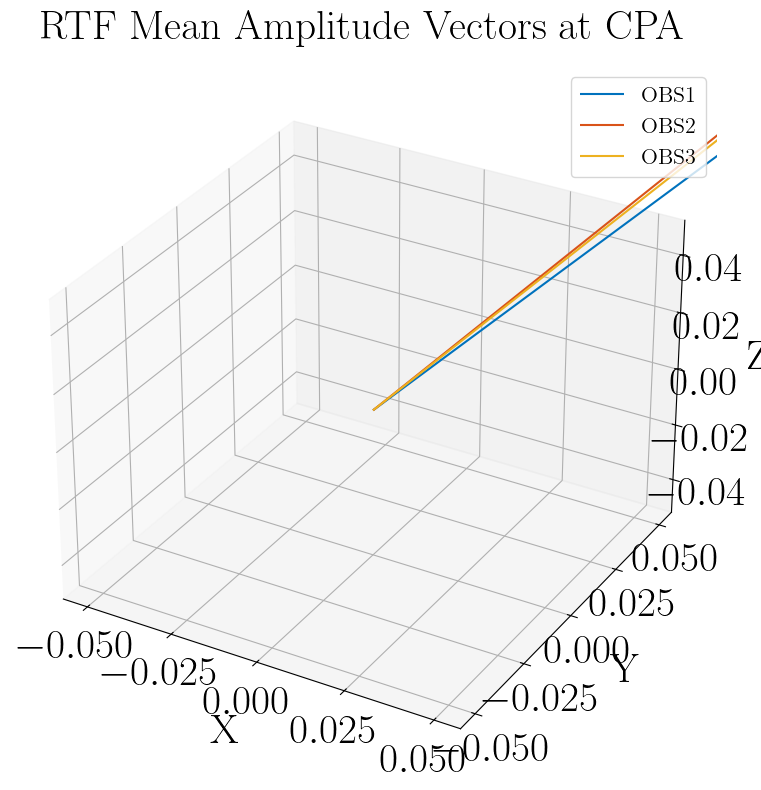

In [60]:
# # Get RTF module at each CPA pos
# for i, i_rcv in enumerate(ds.h_index.values):
#     rtf_amp_cpa_i = ds.rtf_amp.sel(replica_id=cpa_idx[i])   # (nrcv, nf)
#     rtf_mean_amp_cpa_i = rtf_amp_cpa_i.mean(dim="f_rtf")     # (nrcv, ) here 3 components

#     # Plot this 3D vector

from mpl_toolkits.mplot3d import Axes3D  # needed for 3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Optional: define origin (all vectors start from same point)
origin = np.array([[0, 0, 0]])

for i, i_rcv in enumerate(ds.h_index.values):
    rtf_amp_cpa_i = ds.rtf_amp.sel(replica_id=cpa_idx[i])  # (nrcv, nf)
    rtf_mean_amp_cpa_i = rtf_amp_cpa_i.mean(dim="f_rtf")  # (nrcv,) → 3 components

    # Convert to numpy (if xarray)
    vec = rtf_mean_amp_cpa_i.values

    # Ensure it's 3D
    if vec.shape[0] != 3:
        raise ValueError("Expected 3 components for 3D vector")

    u, v, w = vec  # vector components

    # Plot vector
    ax.quiver(
        origin[:, 0],
        origin[:, 1],
        origin[:, 2],  # start point
        u,
        v,
        w,  # direction
        length=1.0,
        normalize=True,
        label=f"OBS{i_rcv}",
        color=color(i),
    )

# Labels
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("RTF Mean Amplitude Vectors at CPA")

# Legend (note: quiver legend workaround)
ax.legend()